# EDA — Scaleup (n=250 queries · 5 engines · k=8 runs)

**Dissertation:** Beyond the Visibility Score: Auditing Source Prominence, Citation Accuracy, and Metric Stability Across Five Generative Engines
**Author:** Ganenthra Ravindran | MSc Business Analytics | Trinity College Dublin | BU7170

All visuals conform to `Visual_Style_Guide.md`. Gold layer only.

**Research questions**
RQ1 · How much text from a source appears in a generative engine's answer, and how prominently is it featured?
RQ2 · Do these measurements hold steady when the same query is repeated and when different engines are used?
RQ3 · When a generative engine cites a source, does that source actually support the claim it is attached to?

**Cell order:** E0 · E7–E12 (By Queries) · E13–E18 (By Metrics) · E1–E6 (By LLM × Query)

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "thesis_config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# ── Style Guide §13 ───────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
    "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#374151", "axes.linewidth": 0.8,
    "axes.labelpad": 10, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 12, "axes.labelweight": "medium",
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": "#E5E7EB", "grid.linewidth": 0.5, "grid.linestyle": "--",
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 4, "ytick.major.size": 4,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.frameon": False, "legend.fontsize": 11,
    "figure.figsize": (7, 4.5), "figure.dpi": 300,
    "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.pad_inches": 0.15,
})

ENGINE_COLOURS = {"chatgpt": "#2CA058", "claude": "#D97706", "gemini": "#2563EB",
                  "kimi": "#7C3AED", "perplexity": "#0891B2"}
ENGINE_ORDER   = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS  = {"chatgpt": "ChatGPT", "claude": "Claude", "gemini": "Gemini",
                  "kimi": "Kimi", "perplexity": "Perplexity"}
ENGINE_MARKERS = {"chatgpt": "o", "claude": "s", "gemini": "^", "kimi": "D", "perplexity": "X"}

# A1: brand accent for single-series charts
COLOUR_PRIMARY   = "#1F4E79"   # single-series bars / composition charts
COLOUR_NEUTRAL   = "#6B7280"   # secondary / de-emphasised elements only
COLOUR_REFERENCE = "#DC2626"   # reference lines, ceilings, threshold-highlight bars
COLOUR_GRID      = "#E5E7EB"

# A2: colour scales
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "thesis_seq", ["#EAF0F7", "#5B8AC4", "#1F4E79"])
CMAP_SEQUENTIAL.set_bad("#D1D5DB")   # NaN cells; annotated "—"
CMAP_DIVERGENT = LinearSegmentedColormap.from_list(
    "thesis_div", ["#B45309", "#F3F4F6", "#1F4E79"])

FIG_DIR = ROOT / "figures" / "scaleup"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def apply_style(ax):
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    for sp in ["left","bottom"]:
        ax.spines[sp].set_color("#374151"); ax.spines[sp].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4)

def savefig(name):
    p = FIG_DIR / name
    plt.savefig(p.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.savefig(p.with_suffix(".pdf"), bbox_inches="tight")
    print(f"saved → {p.relative_to(ROOT)}.png/.pdf")

# A3: raincloud replaces violin — half-KDE + jittered strip + slim box
def plot_raincloud(metric_col, src, title, ylabel, figname, ref_line=None, ref_label=None):
    '''5-engine raincloud (half-violin + jittered strip + slim box).
    Shows zero-inflation and bimodality that a plain violin conceals.
    Violin width scaled by sqrt(n) so engines with fewer obs carry less ink.'''
    np.random.seed(42)
    data  = [src[src.engine == e][metric_col].dropna().values for e in ENGINE_ORDER]
    nulls = [int(src[src.engine == e][metric_col].isna().sum()) for e in ENGINE_ORDER]
    ns    = np.array([len(d) for d in data])
    max_n = ns.max() if ns.max() > 0 else 1

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (eng, d) in enumerate(zip(ENGINE_ORDER, data)):
        c  = ENGINE_COLOURS[eng]
        sf = np.sqrt(ns[i] / max_n) * 0.38   # scale half-violin width by sqrt(n)

        # (a) half-violin (KDE) to the LEFT of position i
        if len(d) > 2:
            kde    = gaussian_kde(d, bw_method=0.25)
            y_grid = np.linspace(d.min(), d.max(), 300)
            k_vals = kde(y_grid)
            k_norm = k_vals / k_vals.max() * sf
            ax.fill_betweenx(y_grid, i - k_norm, i,
                             alpha=0.30, color=c, linewidth=0.8, edgecolor=c, zorder=2)

        # (b) jittered strip to the RIGHT of position i
        if len(d) > 0:
            jitter = np.random.uniform(0.04, 0.30, len(d))
            ax.scatter(i + jitter, d,
                       color=c, s=6.0, alpha=0.25, linewidths=0, zorder=3)

        # (c) slim boxplot AT position i (use Rectangle for crisp IQR box)
        if len(d) >= 4:
            q25, q50, q75 = np.percentile(d, [25, 50, 75])
            import matplotlib.patches as mpatches
            ax.add_patch(mpatches.FancyBboxPatch(
                (i - 0.04, q25), 0.08, q75 - q25,
                boxstyle="square,pad=0", facecolor=c, alpha=0.75,
                edgecolor=c, linewidth=0, zorder=4))
            ax.hlines(q50, i - 0.07, i + 0.07, color="white", linewidth=2.0, zorder=5)

    if ref_line is not None:
        ax.axhline(ref_line, color=COLOUR_REFERENCE, linewidth=1,
                   linestyle="--", label=ref_label, zorder=1)
        ax.legend(loc="upper right", fontsize=9)

    ax.set_xticks(range(5))
    ax.set_xticklabels(
        [f"{ENGINE_LABELS[e]}\nnull={nulls[i]}" for i, e in enumerate(ENGINE_ORDER)],
        fontsize=10)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="medium")
    ax.set_xlim(-0.6, 4.6)
    apply_style(ax)
    plt.tight_layout()
    savefig(figname)
    plt.show()
    return data

# A4: seaborn_box kept for E3
def seaborn_box(src, x, x_order, y, title, figname, xlabel=None, ylabel=None, figsize=(9, 4.5)):
    '''Seaborn grouped box plot across 5 engines.'''
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=src.dropna(subset=[y]), x=x, y=y,
                hue="engine", order=x_order, hue_order=ENGINE_ORDER,
                palette=ENGINE_COLOURS, ax=ax, width=0.7,
                medianprops=dict(linewidth=2), boxprops=dict(alpha=0.5),
                flierprops=dict(marker="o", markersize=3, alpha=0.3, markeredgewidth=0))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel or x.replace("_"," ").title(), fontsize=12, fontweight="medium")
    ax.set_ylabel(ylabel or y, fontsize=12, fontweight="medium")
    h, _ = ax.get_legend_handles_labels()
    ax.legend(h, [ENGINE_LABELS[e] for e in ENGINE_ORDER],
              title="Engine", ncol=5, fontsize=9, title_fontsize=9,
              loc="upper right", frameon=False)
    apply_style(ax)
    plt.tight_layout()
    savefig(figname)
    plt.show()

# A5: stacked_bins — horizontal 100% stacked bar per engine; values binned into ranges
def stacked_bins(metric_col, src, title, figname, bin_edges, bin_labels, colours,
                 xlabel="Percentage of responses (%)", label_fs=8):
    '''100% stacked horizontal bar per engine (fixed order ChatGPT top -> Perplexity
    bottom). EVERY segment is labelled INSIDE its box, in bold and at one uniform font
    size; the figure is wide enough that even the narrowest segment fits. Colours explicit.'''
    import matplotlib.patches as mpatches
    sub = src.dropna(subset=[metric_col])
    nb_ = len(bin_labels)
    fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)
    H = 0.72
    ylabels = []
    for row, e in enumerate(ENGINE_ORDER):
        y = len(ENGINE_ORDER) - 1 - row                 # ChatGPT (row 0) -> top
        d = sub[sub.engine == e][metric_col].values
        pct = np.histogram(d, bins=bin_edges)[0] / len(d) * 100
        left = 0.0
        for j in range(nb_):
            ax.barh(y, pct[j], left=left, height=H, color=colours[j],
                    edgecolor="white", linewidth=0.8)
            if pct[j] > 0:
                r, g, b = mpl.colors.to_rgb(colours[j])
                lum = 0.299 * r + 0.587 * g + 0.114 * b
                ax.text(left + pct[j] / 2, y, f"{pct[j]:.0f}%", ha="center", va="center",
                        fontsize=label_fs, fontweight="bold",
                        color="white" if lum < 0.5 else "#1F2937")
            left += pct[j]
        ylabels.append((y, f"{ENGINE_LABELS[e]} (n={len(d):,})"))

    ylabels.sort()
    ax.set_yticks([y for y, _ in ylabels]); ax.set_yticklabels([l for _, l in ylabels])
    ax.set_xlim(0, 100)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="medium")
    ax.set_title(title, fontsize=13.5, fontweight="bold")
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    handles = [mpatches.Patch(color=colours[j], label=bin_labels[j]) for j in range(nb_)]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=nb_, frameon=False, fontsize=9, handlelength=1.3, columnspacing=1.2)
    savefig(figname); plt.show()
    return [sub[sub.engine == e][metric_col].values for e in ENGINE_ORDER]


# ── Load gold data ─────────────────────────────────────────────────────────────
GOLD = ROOT / "data" / "scaleup" / "gold"
rq   = pd.read_parquet(ROOT / "data/scaleup/queries/reclass_queries.parquet")
ca   = pd.read_parquet(GOLD / "cell_aggregates_scaleup.parquet").merge(rq, on="query_id")
r1   = pd.read_parquet(GOLD / "flat_table1_responses.parquet").merge(rq, on="query_id")
print(f"cell_aggregates: {ca.shape} | flat_table1: {r1.shape} | queries: {rq.shape}")


cell_aggregates: (1249, 25) | flat_table1: (9992, 22) | queries: (250, 10)


---
## E0 · Descriptive statistics by LLM

**Question:** What are the central tendency, spread, and range of AIS, PAWC_norm, and sentence count for each engine?

In [2]:
# E0 — 5 separate per-engine descriptive statistics tables
METRICS = {
    "AIS (Attributable-to-Identified-Sources rate)": "cleaned_ais",
    "PAWC_norm (normalised source prominence)":      "pawc_norm",
    "Sentences":                                     "n_sentences",
}
pd.set_option("display.float_format", "{:.3f}".format)

for eng in ENGINE_ORDER:
    sub  = r1[r1.engine == eng]
    rows = []
    for label, col in METRICS.items():
        s = sub[col].dropna()
        rows.append({
            "Metric":  label,
            "n (non-null)": len(s),
            "Nulls":   int(sub[col].isna().sum()),
            "Mean":    round(s.mean(),  3),
            "Median":  round(s.median(),3),
            "SD":      round(s.std(),   3),
            "Min":     round(s.min(),   3),
            "Max":     round(s.max(),   3),
        })
    tbl = pd.DataFrame(rows).set_index("Metric")
    print(f"\n{'='*68}")
    print(f"  {ENGINE_LABELS[eng]}")
    print(f"{'='*68}")
    print(tbl.to_string())

# B4: explicit ChatGPT n denominators
n_cg_runs  = len(r1[r1.engine == "chatgpt"])
pawn_cg    = int(r1[r1.engine=="chatgpt"]["pawc_norm"].notna().sum())
n_cg_cells = len(ca[ca.engine == "chatgpt"])
pawn_cg_ca = int(ca[ca.engine=="chatgpt"]["pawc_norm_mean"].notna().sum())
print(f"\nNote — ChatGPT PAWC_norm non-null: {pawn_cg} of {n_cg_runs} runs | {pawn_cg_ca} of {n_cg_cells} query-cells")

print('''
ANALYSIS:
Perplexity and Kimi dominate AIS; ChatGPT has near-zero headline AIS because
only 485 of 2,000 runs cited (414 of them, across 79 of 250 query-cells, had computable PAWC) — the rest are
non-citation runs where AIS = 0. ChatGPT conditional AIS (citation runs only)
is meaningfully higher than its headline mean.

→ RQ1: PAWC_norm mean/null counts establish per-engine source-prominence baseline.
→ RQ2: SD values preview run-to-run spread before CV analysis (E15, E16).
→ RQ3: AIS mean per engine; ChatGPT structural non-citation floor (not accuracy failure).
''')


  ChatGPT
                                               n (non-null)  Nulls   Mean  Median     SD   Min     Max
Metric                                                                                                
AIS (Attributable-to-Identified-Sources rate)          2000      0  0.120   0.000  0.279 0.000   1.000
PAWC_norm (normalised source prominence)                414   1586  0.422   0.388  0.305 0.000   1.000
Sentences                                              2000      0 19.524  12.000 23.868 1.000 274.000

  Claude
                                               n (non-null)  Nulls   Mean  Median     SD   Min    Max
Metric                                                                                               
AIS (Attributable-to-Identified-Sources rate)          2000      0  0.579   0.726  0.404 0.000  1.000
PAWC_norm (normalised source prominence)               1467    533  0.426   0.399  0.226 0.000  1.000
Sentences                                              2

---
## PAWC_norm nulls — Root Cause 1: No citations produced

**Question:** Which engines produce zero-citation responses, and at what rate?
When an engine returns no citations, PAWC_norm is undefined (NaN) — not zero — because
there is no source content to measure prominence against.

saved → figures/scaleup/fig_eda_rc1_zero_citation_rate.png/.pdf


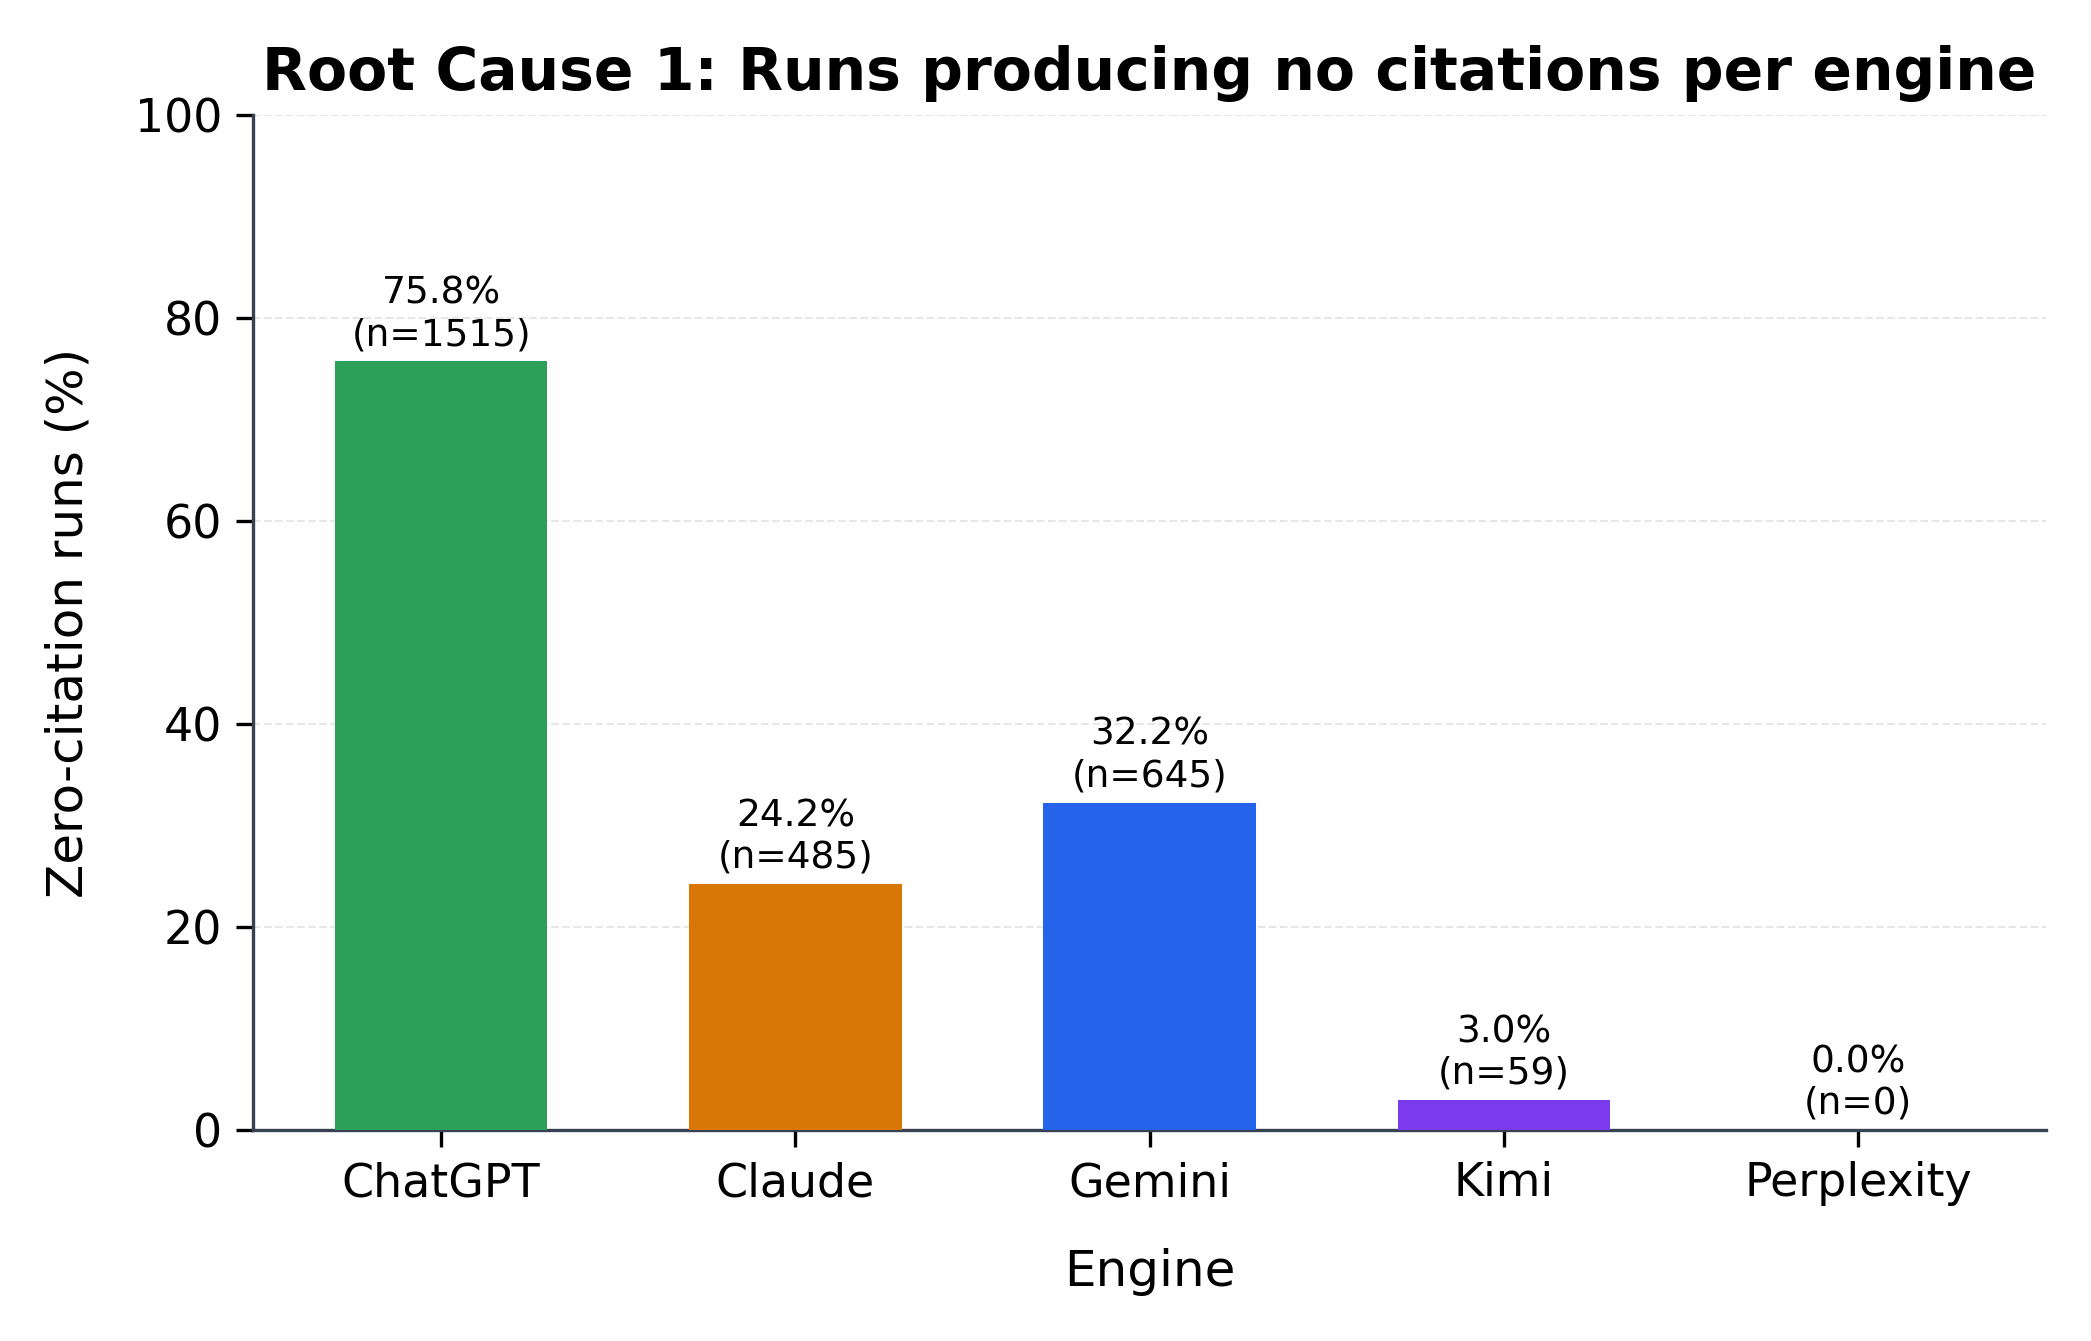


ANALYSIS:
ChatGPT produced no citations in 75.8% of its 2,000 runs — the largest zero-citation
rate of any engine. On those runs PAWC_norm is undefined, not zero. Perplexity never
produces a zero-citation run; it is inherently grounded and always attaches sources.
Kimi (3.0%) and Perplexity (0%) have near-complete citation coverage. This single
behaviour explains the majority of PAWC_norm nulls seen in the descriptive statistics.



In [3]:
# RC1 — proportion of runs with zero citations per engine
rc1_vals = (r1.groupby("engine")
              .apply(lambda x: (x["n_sources_cited"] == 0).sum() / len(x) * 100)
              .reindex(ENGINE_ORDER))
rc1_counts = (r1.groupby("engine")
                .apply(lambda x: int((x["n_sources_cited"] == 0).sum()))
                .reindex(ENGINE_ORDER))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([ENGINE_LABELS[e] for e in ENGINE_ORDER], rc1_vals.values,
              color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER],
              width=0.6, zorder=3)
for bar, pct, n in zip(bars, rc1_vals.values, rc1_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{pct:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("Root Cause 1: Runs producing no citations per engine",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Engine", fontsize=12, fontweight="medium")
ax.set_ylabel("Zero-citation runs (%)", fontsize=12, fontweight="medium")
ax.set_ylim(0, 100)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_rc1_zero_citation_rate"); plt.show()
print('''
ANALYSIS:
ChatGPT produced no citations in 75.8% of its 2,000 runs — the largest zero-citation
rate of any engine. On those runs PAWC_norm is undefined, not zero. Perplexity never
produces a zero-citation run; it is inherently grounded and always attaches sources.
Kimi (3.0%) and Perplexity (0%) have near-complete citation coverage. This single
behaviour explains the majority of PAWC_norm nulls seen in the descriptive statistics.
''')

---
## PAWC_norm nulls — Root Cause 2: Cited sources could not be fetched

**Question:** For runs where an engine did produce citations, how often did every
cited source fail to be retrieved — making PAWC_norm uncomputable even though
a citation exists?

saved → figures/scaleup/fig_eda_rc2_fetch_failure.png/.pdf


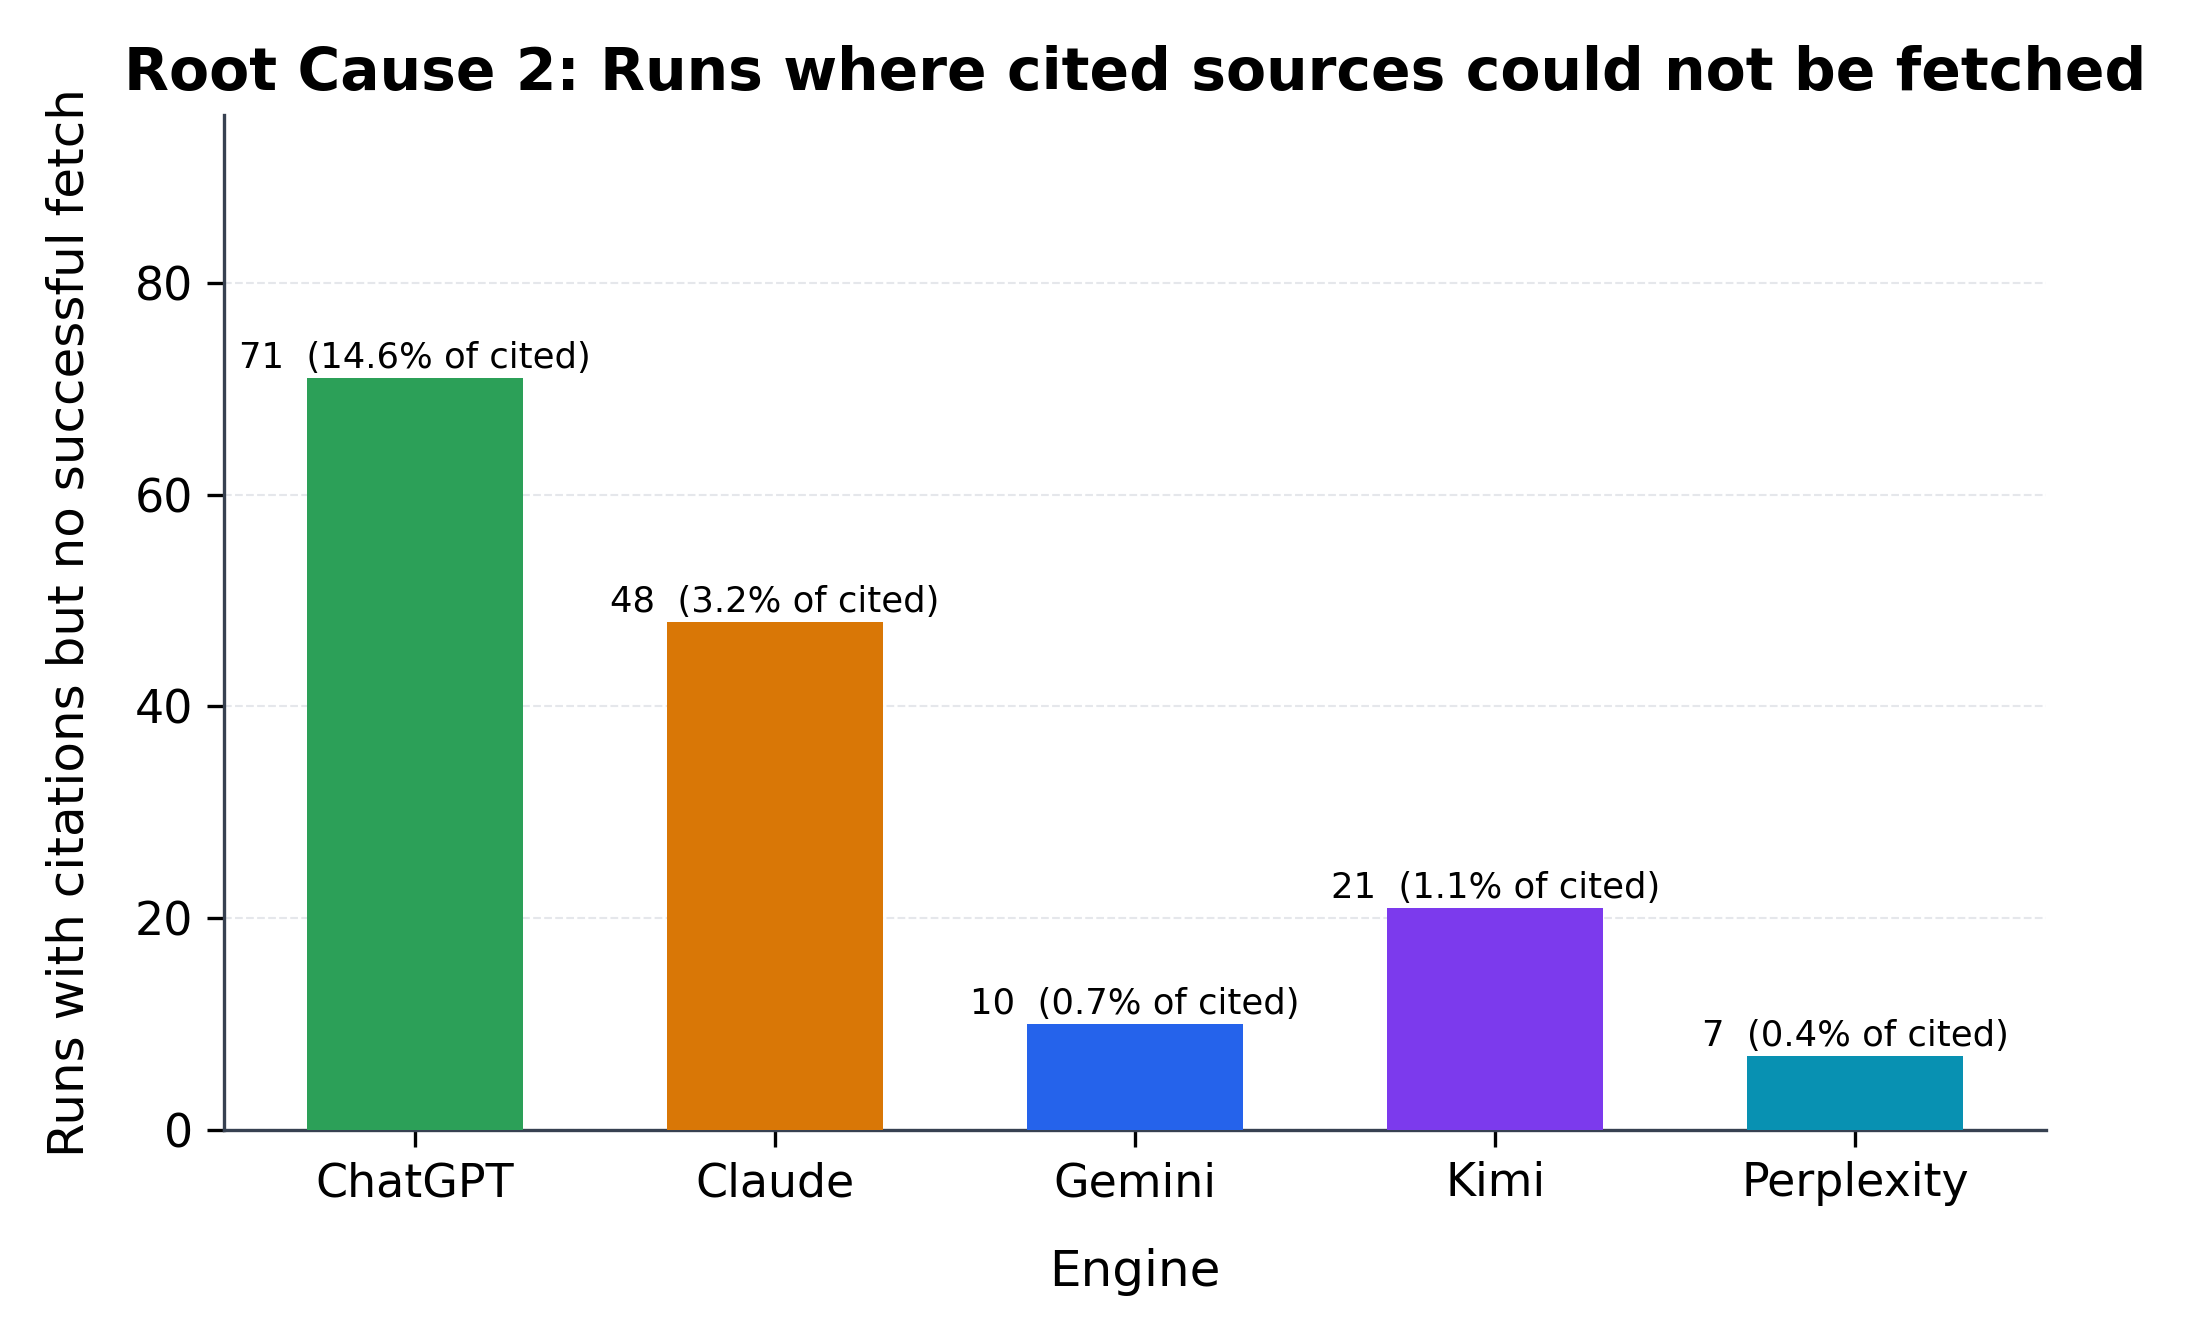


ANALYSIS:
Root Cause 2 is a pipeline constraint, not an engine behaviour. On these runs the
engine did produce citations, but every cited URL failed to return content —
due to paywalls, dead links, or bot-blocking — so PAWC_norm could not be computed.
All 7 of Perplexity's PAWC_norm nulls fall into this category; it never produces
a zero-citation run, so RC2 is its only source of nulls. ChatGPT has the highest
absolute RC2 count (71) but these are small relative to its 2,000 total runs (3.6%).
RC2 nulls are noted as a data-collection limitation and excluded from engine-behaviour
conclusions.



In [4]:
# RC2 — runs where citations exist but every source URL failed to fetch
rc2_counts = (r1.groupby("engine")
                .apply(lambda x: int(((x["n_sources_cited"] > 0) &
                                      (x["n_sources_fetched_ok"] == 0)).sum()))
                .reindex(ENGINE_ORDER))
cited_counts = (r1.groupby("engine")
                  .apply(lambda x: int((x["n_sources_cited"] > 0).sum()))
                  .reindex(ENGINE_ORDER))
rc2_pct = rc2_counts / cited_counts.replace(0, np.nan) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([ENGINE_LABELS[e] for e in ENGINE_ORDER], rc2_counts.values,
              color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER],
              width=0.6, zorder=3)
for bar, n, pct in zip(bars, rc2_counts.values, rc2_pct.fillna(0).values):
    label = f"{n}  ({pct:.1f}% of cited)" if pct > 0 else str(n)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            label, ha="center", va="bottom", fontsize=8.5)
ax.set_title("Root Cause 2: Runs where cited sources could not be fetched",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Engine", fontsize=12, fontweight="medium")
ax.set_ylabel("Runs with citations but no successful fetch", fontsize=12, fontweight="medium")
ax.set_ylim(0, rc2_counts.max() * 1.35)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_rc2_fetch_failure"); plt.show()
print('''
ANALYSIS:
Root Cause 2 is a pipeline constraint, not an engine behaviour. On these runs the
engine did produce citations, but every cited URL failed to return content —
due to paywalls, dead links, or bot-blocking — so PAWC_norm could not be computed.
All 7 of Perplexity's PAWC_norm nulls fall into this category; it never produces
a zero-citation run, so RC2 is its only source of nulls. ChatGPT has the highest
absolute RC2 count (71) but these are small relative to its 2,000 total runs (3.6%).
RC2 nulls are noted as a data-collection limitation and excluded from engine-behaviour
conclusions.
''')

---
## E7 · Query distribution by complexity

**Question:** How are the 250 queries distributed across complexity levels?

saved → figures/scaleup/fig_eda_01_complexity_dist.png/.pdf


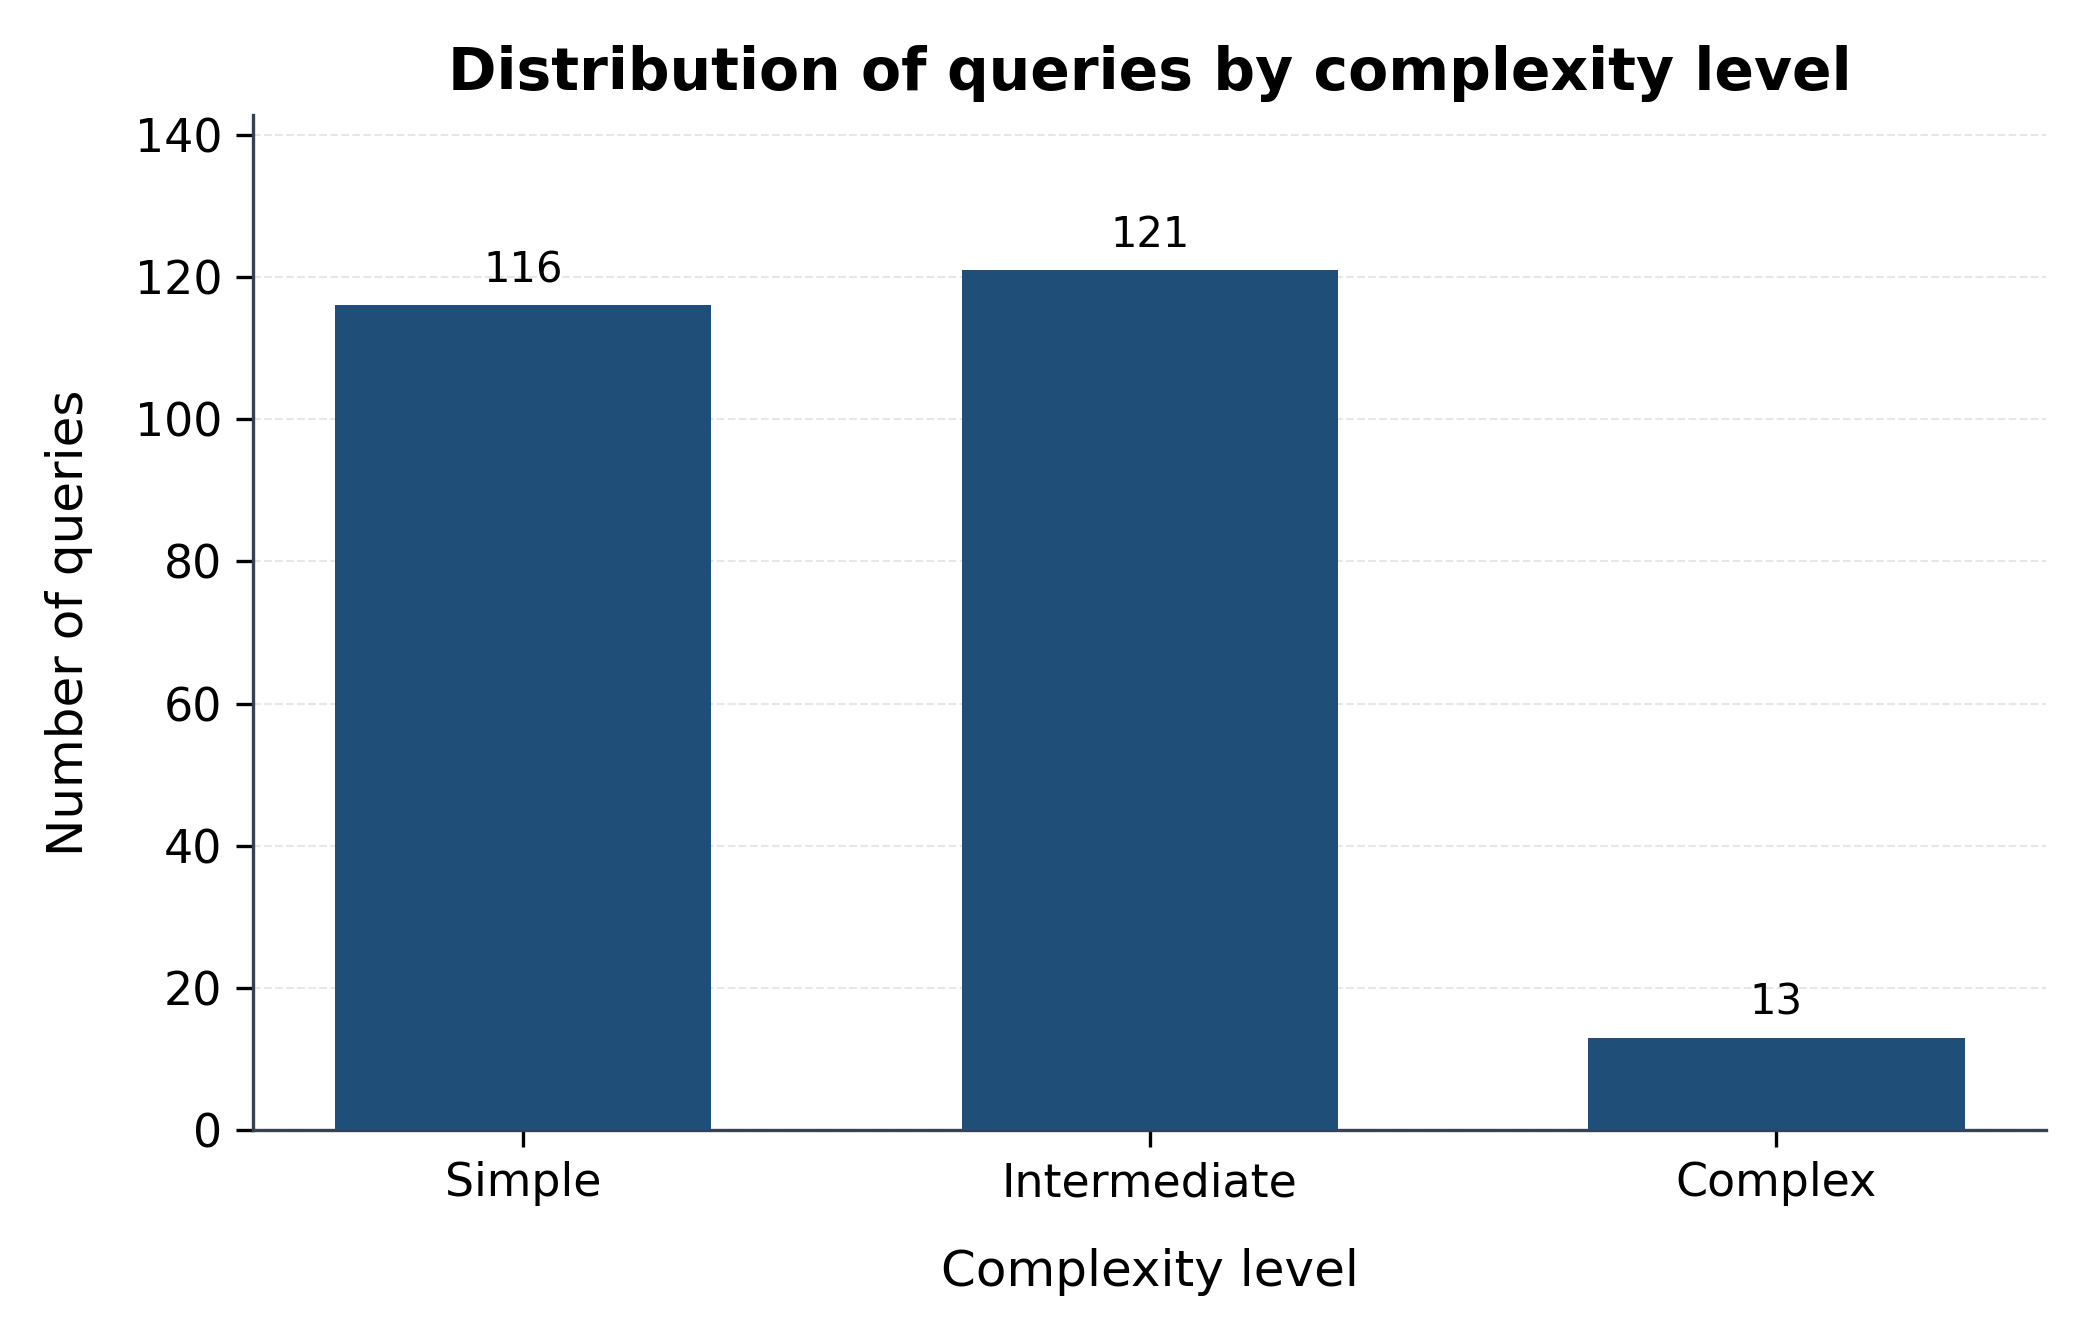

complexity
simple          116
intermediate    121
complex          13

ANALYSIS:
Simple (116) and intermediate (121) are near-equally split; complex is rare (13, 5%).
The low complex-query count limits subgroup statistical power in engine-stratified
comparisons — complex-tier results must be treated as indicative only.

→ RQ1/RQ3: Complexity is a candidate moderator; the low complex-query n constrains
           testing whether harder queries reduce source prominence or citation accuracy.



In [5]:
# E7 — fig_eda_01: bar chart queries by complexity  (E1: COLOUR_PRIMARY)
ORDER_COMPLEXITY = ["simple", "intermediate", "complex"]
vc = rq["complexity"].value_counts().reindex(ORDER_COMPLEXITY)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([l.capitalize() for l in ORDER_COMPLEXITY], vc.values,
              width=0.6, color=COLOUR_PRIMARY, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=10)
# E2: no "E7 ·" prefix in figure title
ax.set_title("Distribution of queries by complexity level", fontsize=14, fontweight="bold")
ax.set_xlabel("Complexity level", fontsize=12, fontweight="medium")
ax.set_ylabel("Number of queries", fontsize=12, fontweight="medium")
ax.set_ylim(0, vc.max() * 1.18)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_01_complexity_dist"); plt.show()
print(vc.to_string())
print('''
ANALYSIS:
Simple (116) and intermediate (121) are near-equally split; complex is rare (13, 5%).
The low complex-query count limits subgroup statistical power in engine-stratified
comparisons — complex-tier results must be treated as indicative only.

→ RQ1/RQ3: Complexity is a candidate moderator; the low complex-query n constrains
           testing whether harder queries reduce source prominence or citation accuracy.
''')

---
## E8 · Query distribution by intent

**Question:** How are the 250 queries distributed across intent categories?

saved → figures/scaleup/fig_eda_02_intent_dist.png/.pdf


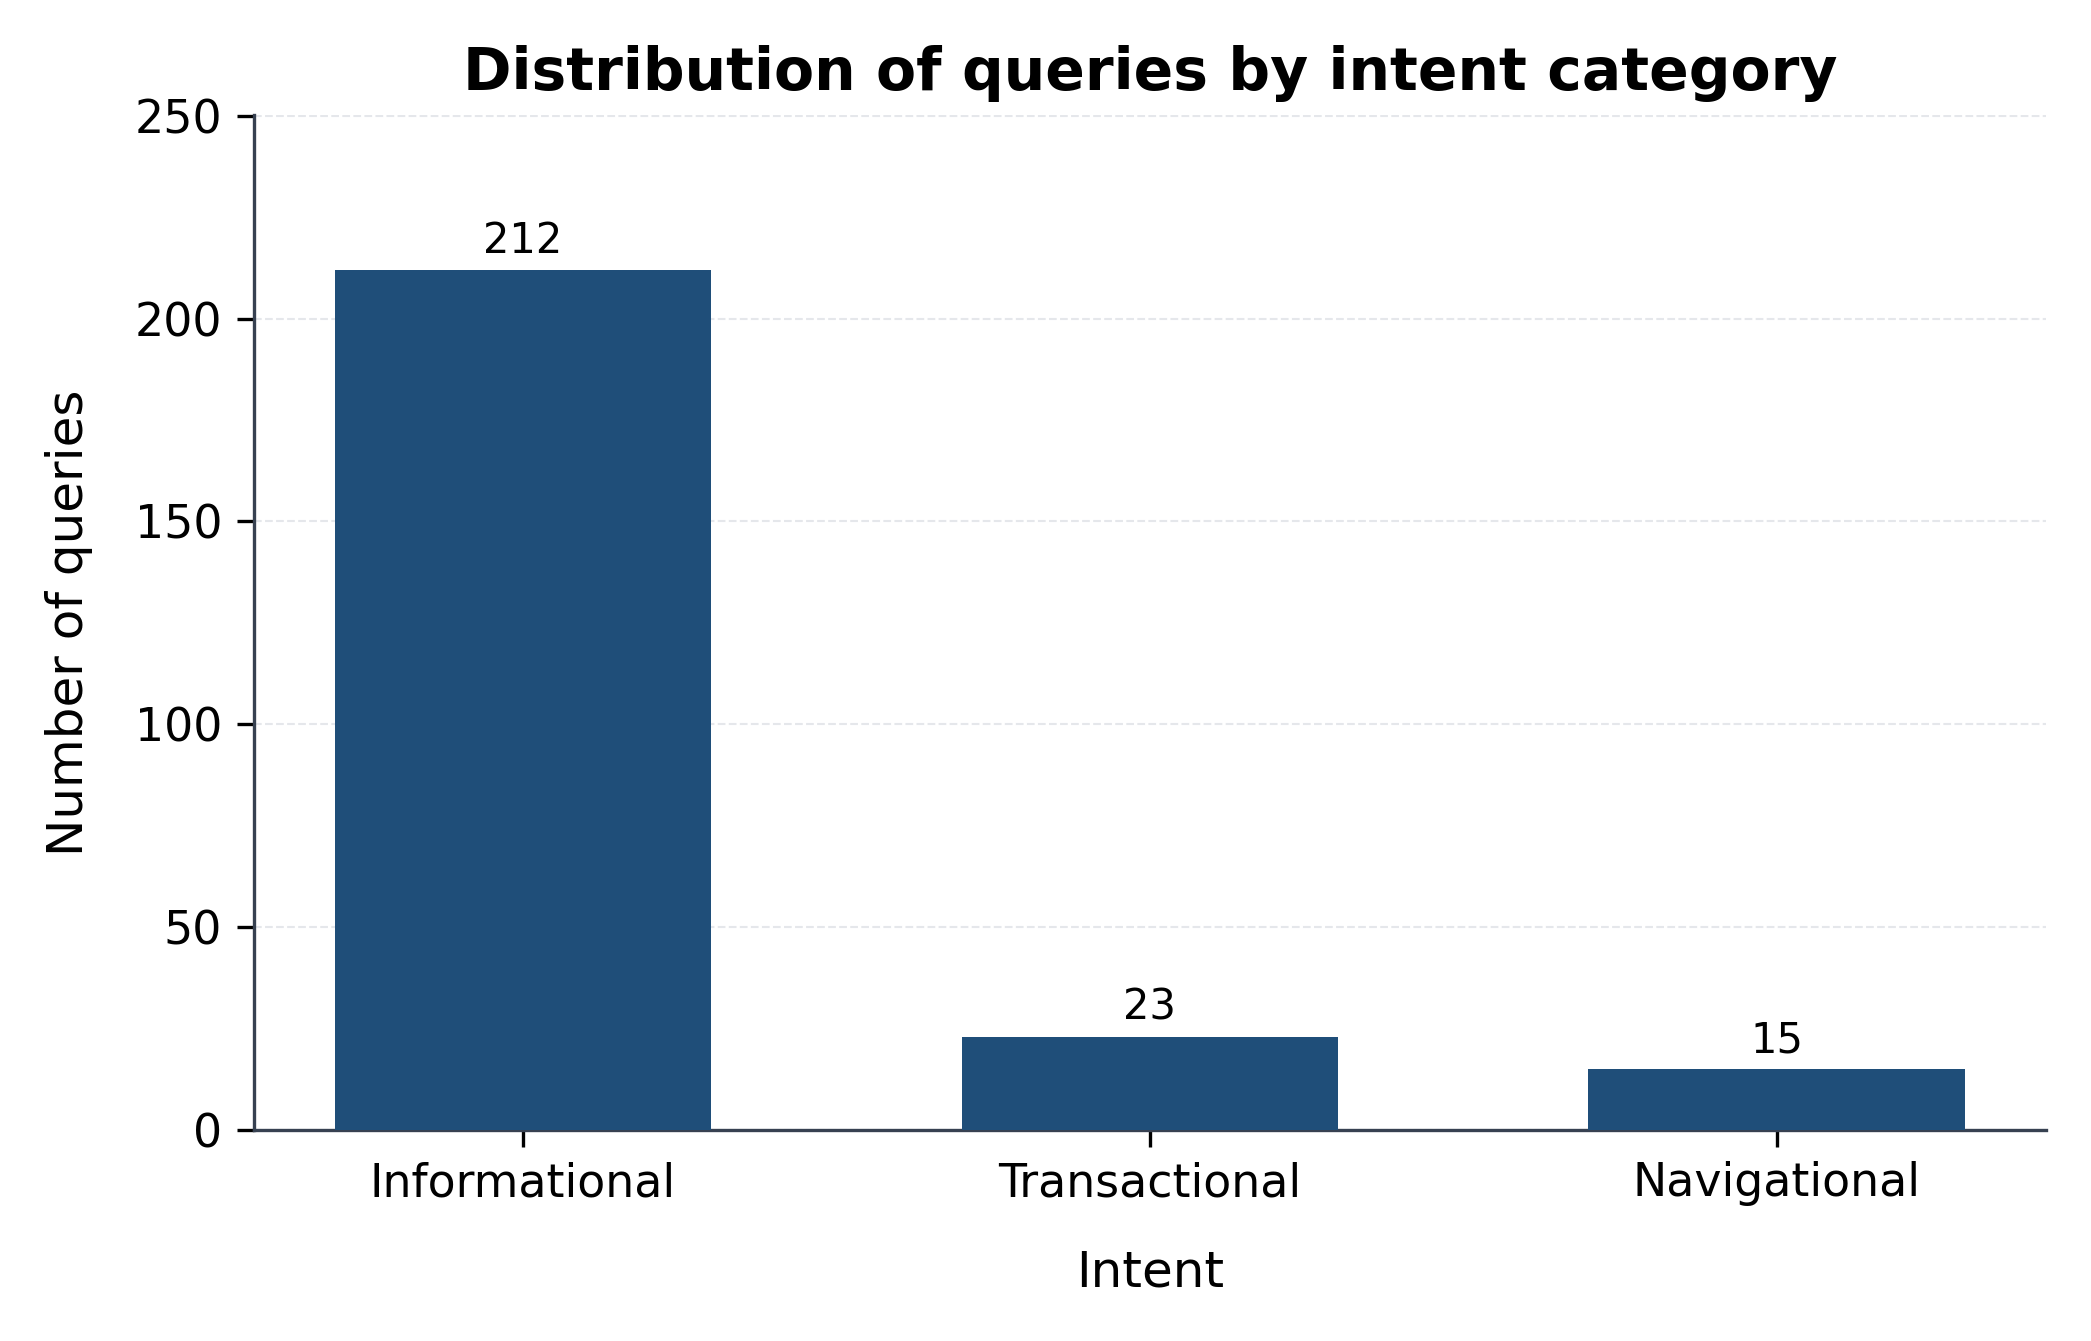

intent
informational    212
transactional     23
navigational      15

ANALYSIS:
Informational intent dominates (212/250 = 85%), inheriting GEO-Bench's composition.
Transactional (23) and navigational (15) are sparse — intent-stratified testing on
those tiers is exploratory only.

→ RQ1: With only 15 navigational and 23 transactional queries, intent-stratified results
       are exploratory; the data do NOT show navigational queries suppressing PAWC_norm —
       their prominence is at least as high as informational on 4/5 engines (see E3).



In [6]:
# E8 — fig_eda_02: bar chart queries by intent  (E1: COLOUR_PRIMARY)
ORDER_INTENT = ["informational", "transactional", "navigational"]
vc = rq["intent"].value_counts().reindex(ORDER_INTENT)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([l.capitalize() for l in ORDER_INTENT], vc.values,
              width=0.6, color=COLOUR_PRIMARY, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=10)
ax.set_title("Distribution of queries by intent category", fontsize=14, fontweight="bold")
ax.set_xlabel("Intent", fontsize=12, fontweight="medium")
ax.set_ylabel("Number of queries", fontsize=12, fontweight="medium")
ax.set_ylim(0, vc.max() * 1.18)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_02_intent_dist"); plt.show()
print(vc.to_string())
print('''
ANALYSIS:
Informational intent dominates (212/250 = 85%), inheriting GEO-Bench's composition.
Transactional (23) and navigational (15) are sparse — intent-stratified testing on
those tiers is exploratory only.

→ RQ1: With only 15 navigational and 23 transactional queries, intent-stratified results
       are exploratory; the data do NOT show navigational queries suppressing PAWC_norm —
       their prominence is at least as high as informational on 4/5 engines (see E3).
''')

---
## E9 · Query distribution by domain

**Question:** How are the 250 queries distributed across domains?

saved → figures/scaleup/fig_eda_03_domain_dist.png/.pdf


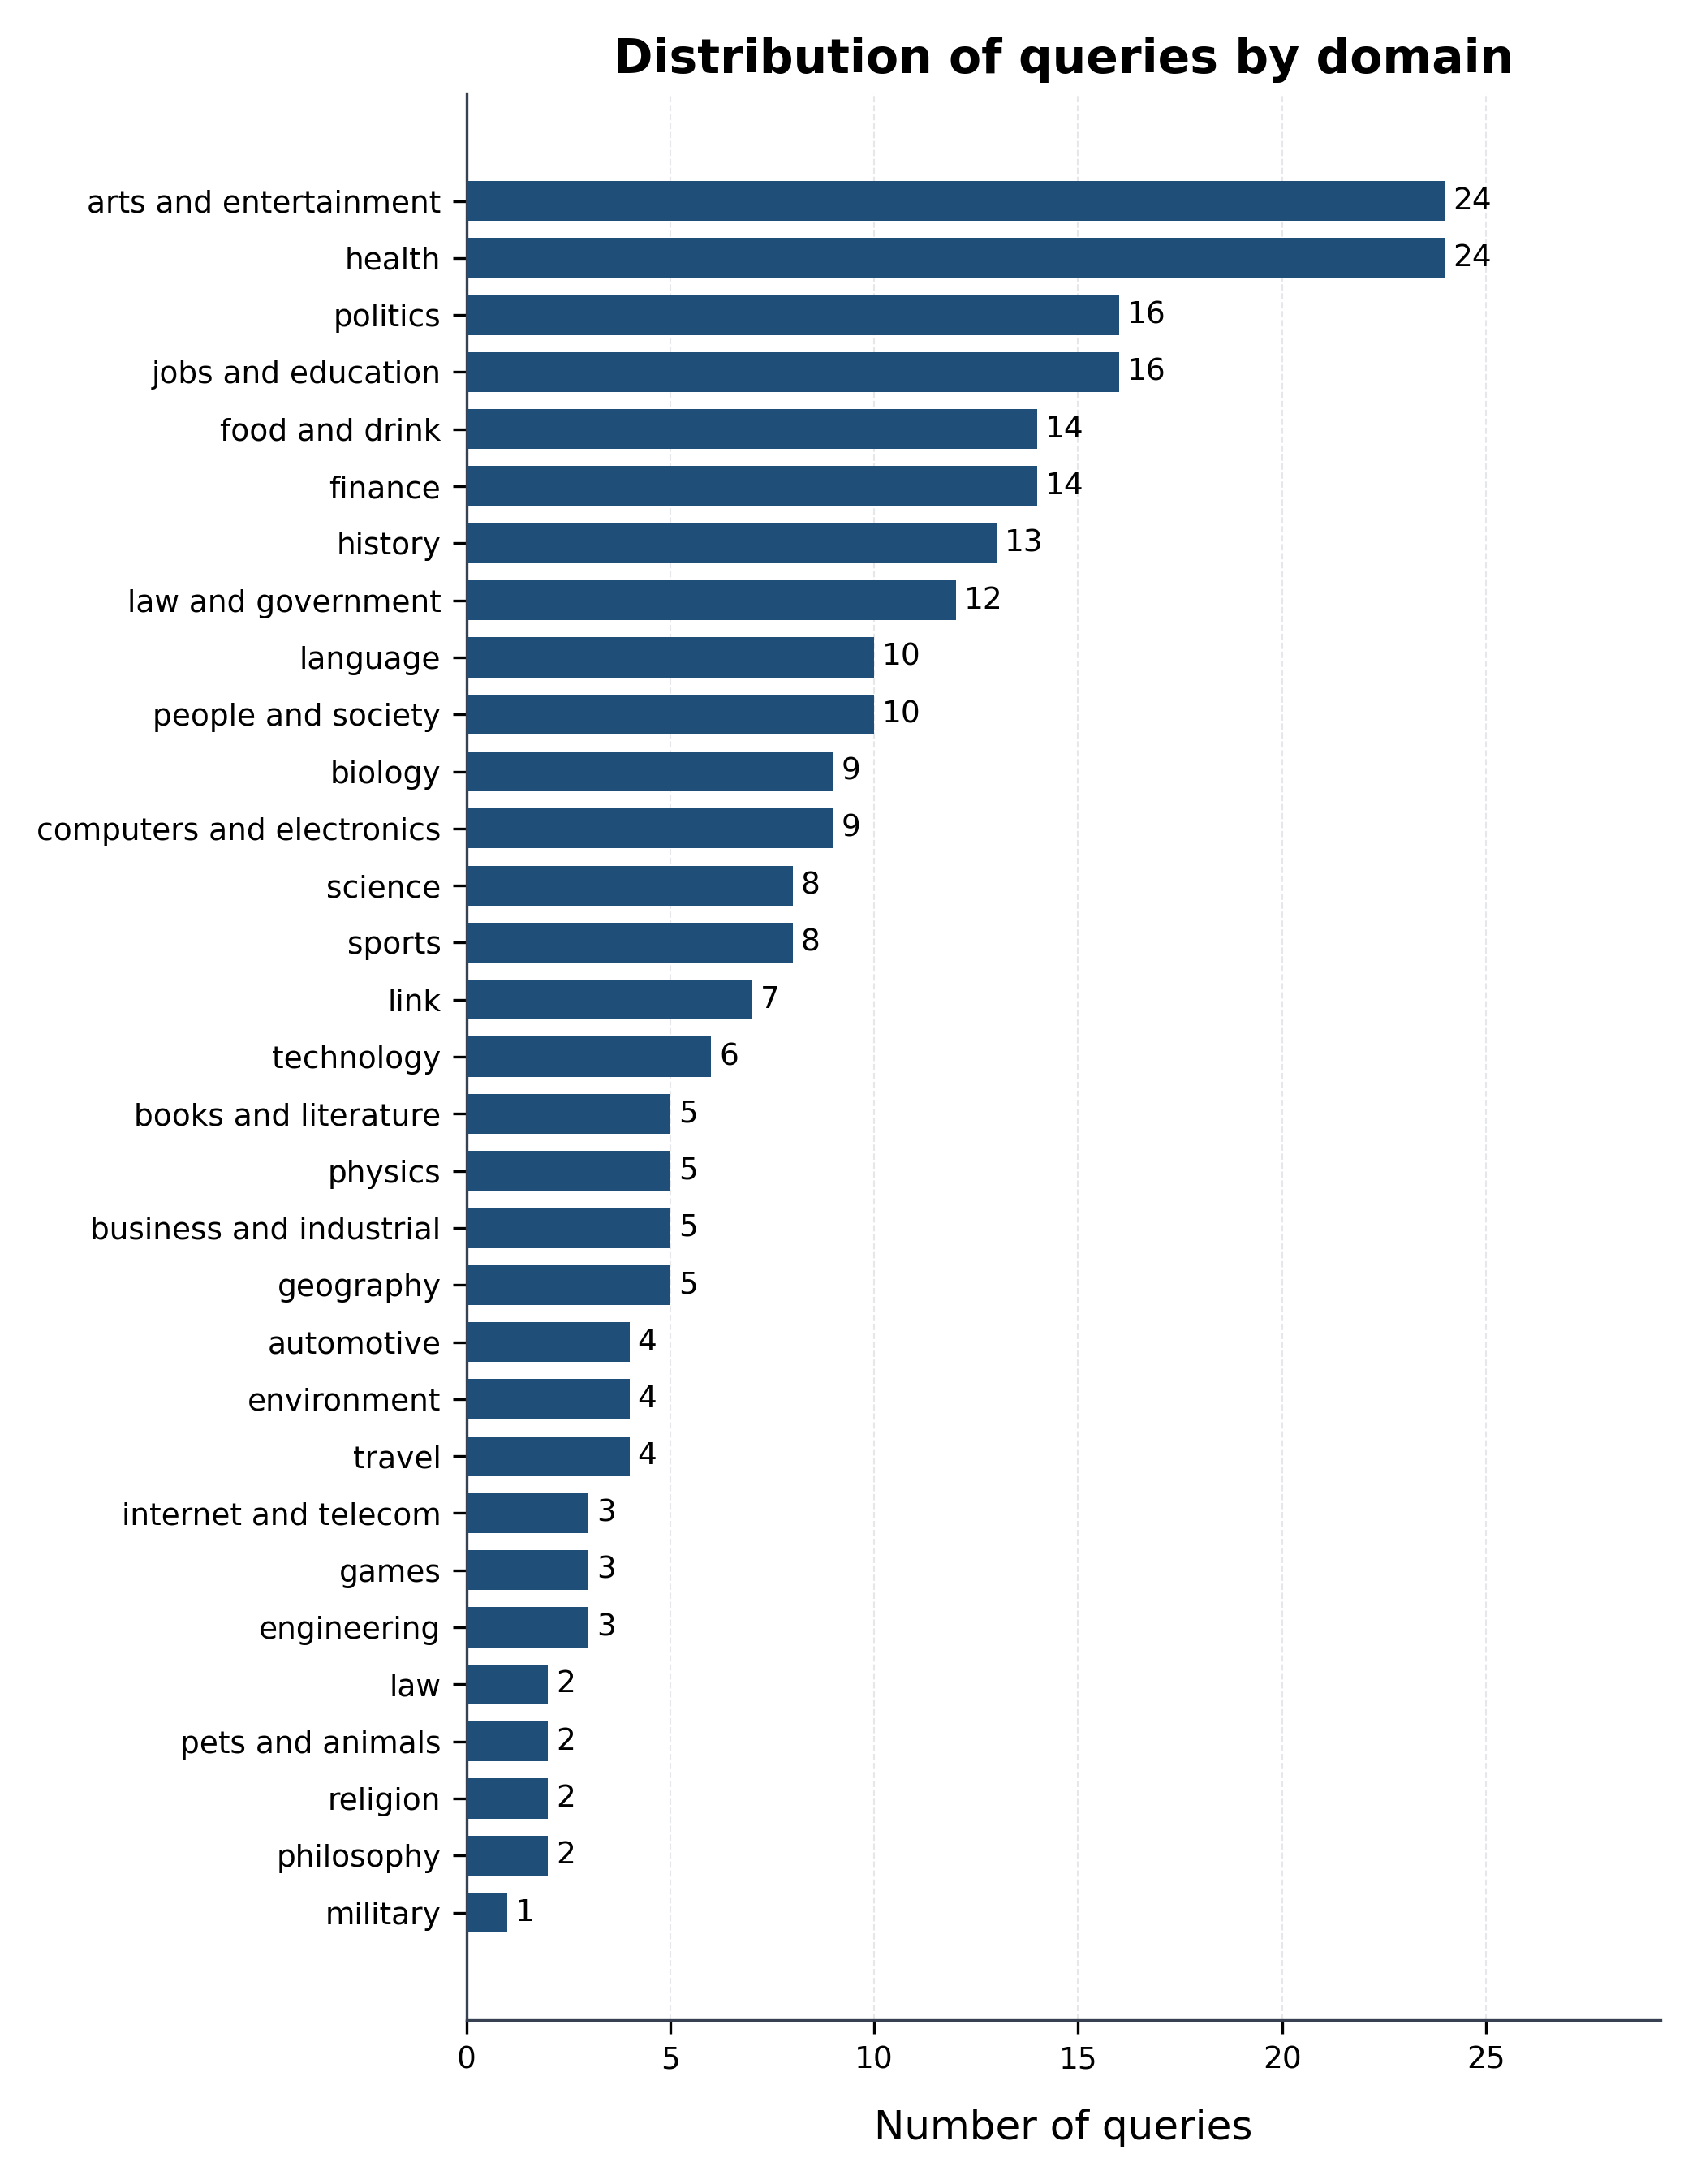

domain
arts and entertainment       24
health                       24
politics                     16
jobs and education           16
food and drink               14
finance                      14
history                      13
law and government           12
language                     10
people and society           10
biology                       9
computers and electronics     9
science                       8
sports                        8
link                          7
technology                    6
books and literature          5
physics                       5
business and industrial       5
geography                     5
automotive                    4
environment                   4
travel                        4
internet and telecom          3
games                         3
engineering                   3
pets and animals              2
religion                      2
philosophy                    2
law                           2
military                      1



In [7]:
# E9 — fig_eda_03: horizontal bar queries by domain  (E1: COLOUR_PRIMARY)
vc = rq["domain"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 9))
bars = ax.barh(vc.index, vc.values, height=0.7, color=COLOUR_PRIMARY, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(v), va="center", ha="left", fontsize=9)
ax.set_title("Distribution of queries by domain", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of queries", fontsize=12, fontweight="medium")
ax.set_xlim(0, vc.max() * 1.22)
ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.tick_params(direction="out", length=4, labelsize=9)
plt.tight_layout(); savefig("fig_eda_03_domain_dist"); plt.show()
print(rq["domain"].value_counts().to_string())
print('''
ANALYSIS:
Arts & entertainment and health lead at 24 queries each; 15 of 31 domains have ≤5 queries.
The extreme long tail means most individual domains cannot support reliable
engine-level comparisons without domain grouping (see E1 meta-domain heatmap).

→ RQ1/RQ3: Domain is a contextual moderator. Sparse domains must be pooled or treated
           as exploratory when testing source prominence or citation accuracy.
''')

---
## E10 · Query distribution by content type and sensitivity

**Question:** How are the 250 queries distributed across content type and sensitivity?

saved → figures/scaleup/fig_eda_04_content_sensitivity_stacked.png/.pdf


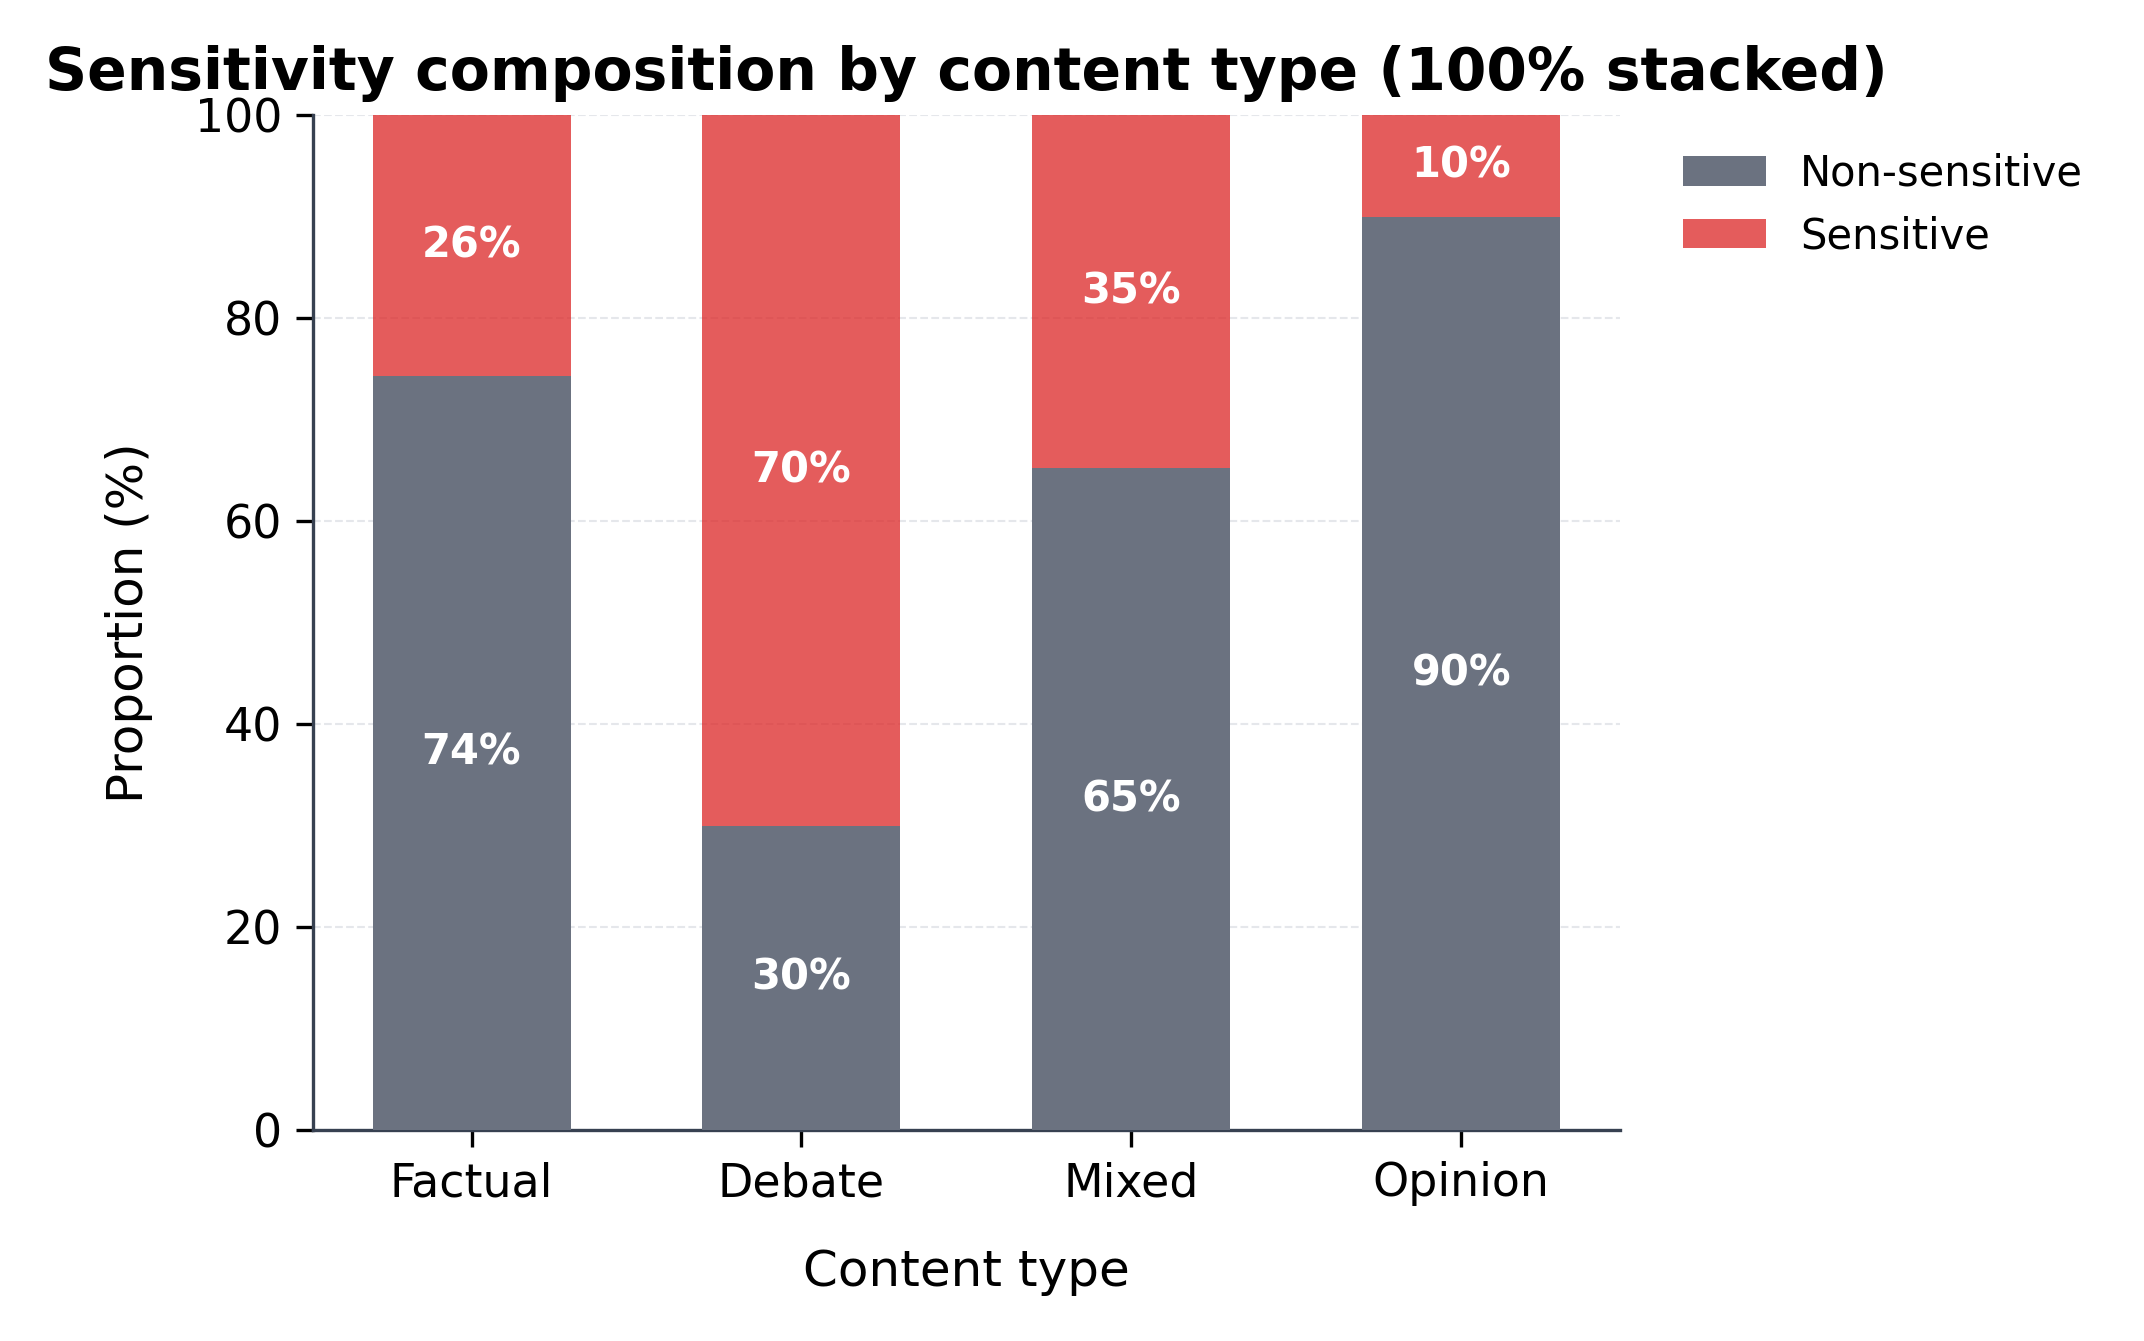

Debate queries that are sensitive: 70%
sensitivity   non-sensitive  sensitive
content_type                          
factual                 107         37
debate                   15         35
mixed                    30         16
opinion                   9          1

ANALYSIS:
Debate queries are ~70% sensitive vs factual queries at ~26%.
This near-total overlap is a structural confound: debate and sensitivity cannot be
independently manipulated in this dataset — their effects on AIS cannot be cleanly separated.

→ RQ3: The debate-sensitivity confound means AIS differences by content type (E4/E5)
       partially reflect sensitivity effects and must be interpreted jointly.



In [8]:
# E10 — fig_eda_04: 100% stacked bar; D3: % labels inside bars (not absolute counts)
ORDER_CT = ["factual", "debate", "mixed", "opinion"]
ct_sens = (rq.groupby(["content_type","sensitivity"]).size()
             .unstack(fill_value=0).reindex(ORDER_CT)[["non-sensitive","sensitive"]])
ct_pct  = ct_sens.div(ct_sens.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars_ns = ax.bar([l.capitalize() for l in ORDER_CT], ct_pct["non-sensitive"],
                 width=0.6, color=COLOUR_NEUTRAL, label="Non-sensitive", zorder=3)
bars_s  = ax.bar([l.capitalize() for l in ORDER_CT], ct_pct["sensitive"],
                 width=0.6, bottom=ct_pct["non-sensitive"],
                 color=COLOUR_REFERENCE, alpha=0.75, label="Sensitive", zorder=3)
# D3: percentage labels (not absolute counts)
for i, ct in enumerate(ORDER_CT):
    pct_ns = ct_pct.loc[ct, "non-sensitive"]
    pct_s  = ct_pct.loc[ct, "sensitive"]
    if pct_ns > 8:
        ax.text(i, pct_ns / 2, f"{pct_ns:.0f}%", ha="center", va="center",
                fontsize=10, color="white", fontweight="bold")
    if pct_s > 8:
        ax.text(i, pct_ns + pct_s / 2, f"{pct_s:.0f}%", ha="center", va="center",
                fontsize=10, color="white", fontweight="bold")
ax.set_title("Sensitivity composition by content type (100% stacked)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Content type", fontsize=12, fontweight="medium")
ax.set_ylabel("Proportion (%)", fontsize=12, fontweight="medium")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=False)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_04_content_sensitivity_stacked"); plt.show()

debate_sens_pct = ct_pct.loc["debate","sensitive"]
factual_sens_pct = ct_pct.loc["factual","sensitive"]
print(f"Debate queries that are sensitive: {debate_sens_pct:.0f}%")
print(ct_sens.to_string())
print(f'''
ANALYSIS:
Debate queries are ~{debate_sens_pct:.0f}% sensitive vs factual queries at ~{factual_sens_pct:.0f}%.
This near-total overlap is a structural confound: debate and sensitivity cannot be
independently manipulated in this dataset — their effects on AIS cannot be cleanly separated.

→ RQ3: The debate-sensitivity confound means AIS differences by content type (E4/E5)
       partially reflect sensitivity effects and must be interpreted jointly.
''')

---
## E11 · Query distribution by response type

**Question:** How are the 250 queries distributed across response types?

saved → figures/scaleup/fig_eda_05_response_type_dist.png/.pdf


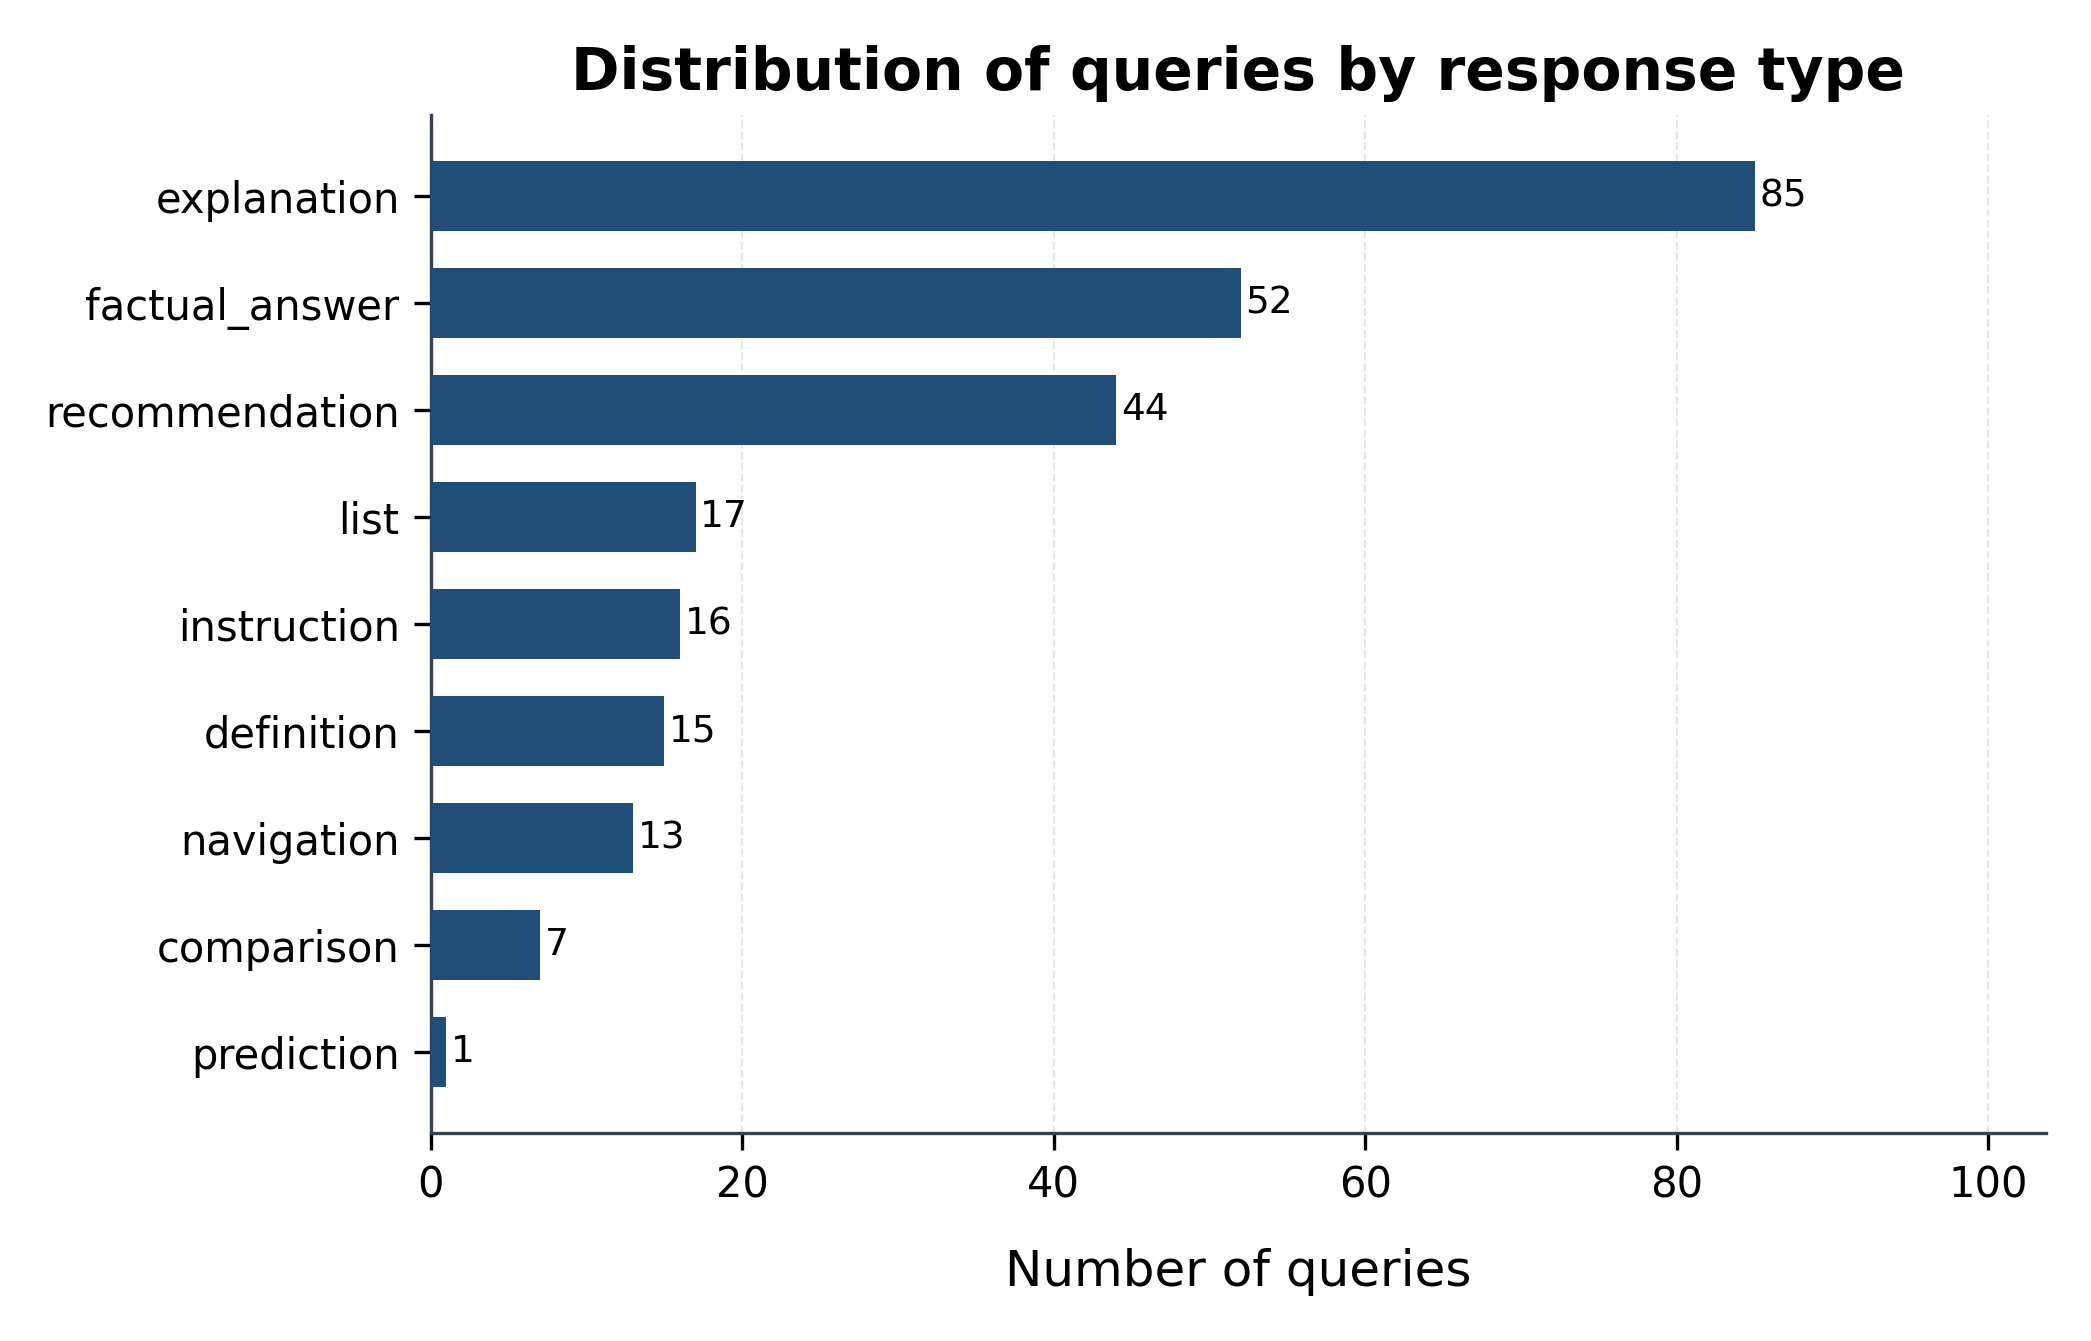

response_type
explanation       85
factual_answer    52
recommendation    44
list              17
instruction       16
definition        15
navigation        13
comparison         7
prediction         1

ANALYSIS:
Explanation (85) and factual_answer (52) dominate; recommendation (44) is strong.
Prediction (1) is analytically unusable. Navigation (13) rarely triggers citations,
introducing a structural PAWC_norm gap for that response type.

→ RQ3: Explanation and recommendation response types require substantiating sources —
       the highest-stakes types for citation accuracy in the RQ3 analysis.



In [9]:
# E11 — fig_eda_05: horizontal bar queries by response type  (E1: COLOUR_PRIMARY)
vc = rq["response_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(vc.index, vc.values, height=0.65, color=COLOUR_PRIMARY, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), va="center", ha="left", fontsize=9)
ax.set_title("Distribution of queries by response type", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of queries", fontsize=12, fontweight="medium")
ax.set_xlim(0, vc.max() * 1.22)
ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.tick_params(direction="out", length=4, labelsize=10)
plt.tight_layout(); savefig("fig_eda_05_response_type_dist"); plt.show()
print(vc.sort_values(ascending=False).to_string())
print('''
ANALYSIS:
Explanation (85) and factual_answer (52) dominate; recommendation (44) is strong.
Prediction (1) is analytically unusable. Navigation (13) rarely triggers citations,
introducing a structural PAWC_norm gap for that response type.

→ RQ3: Explanation and recommendation response types require substantiating sources —
       the highest-stakes types for citation accuracy in the RQ3 analysis.
''')

---
## E12 · Query distribution by temporality and technicality

**Question:** How are the 250 queries distributed across temporality and technicality?

saved → figures/scaleup/fig_eda_06_temporality_technicality.png/.pdf


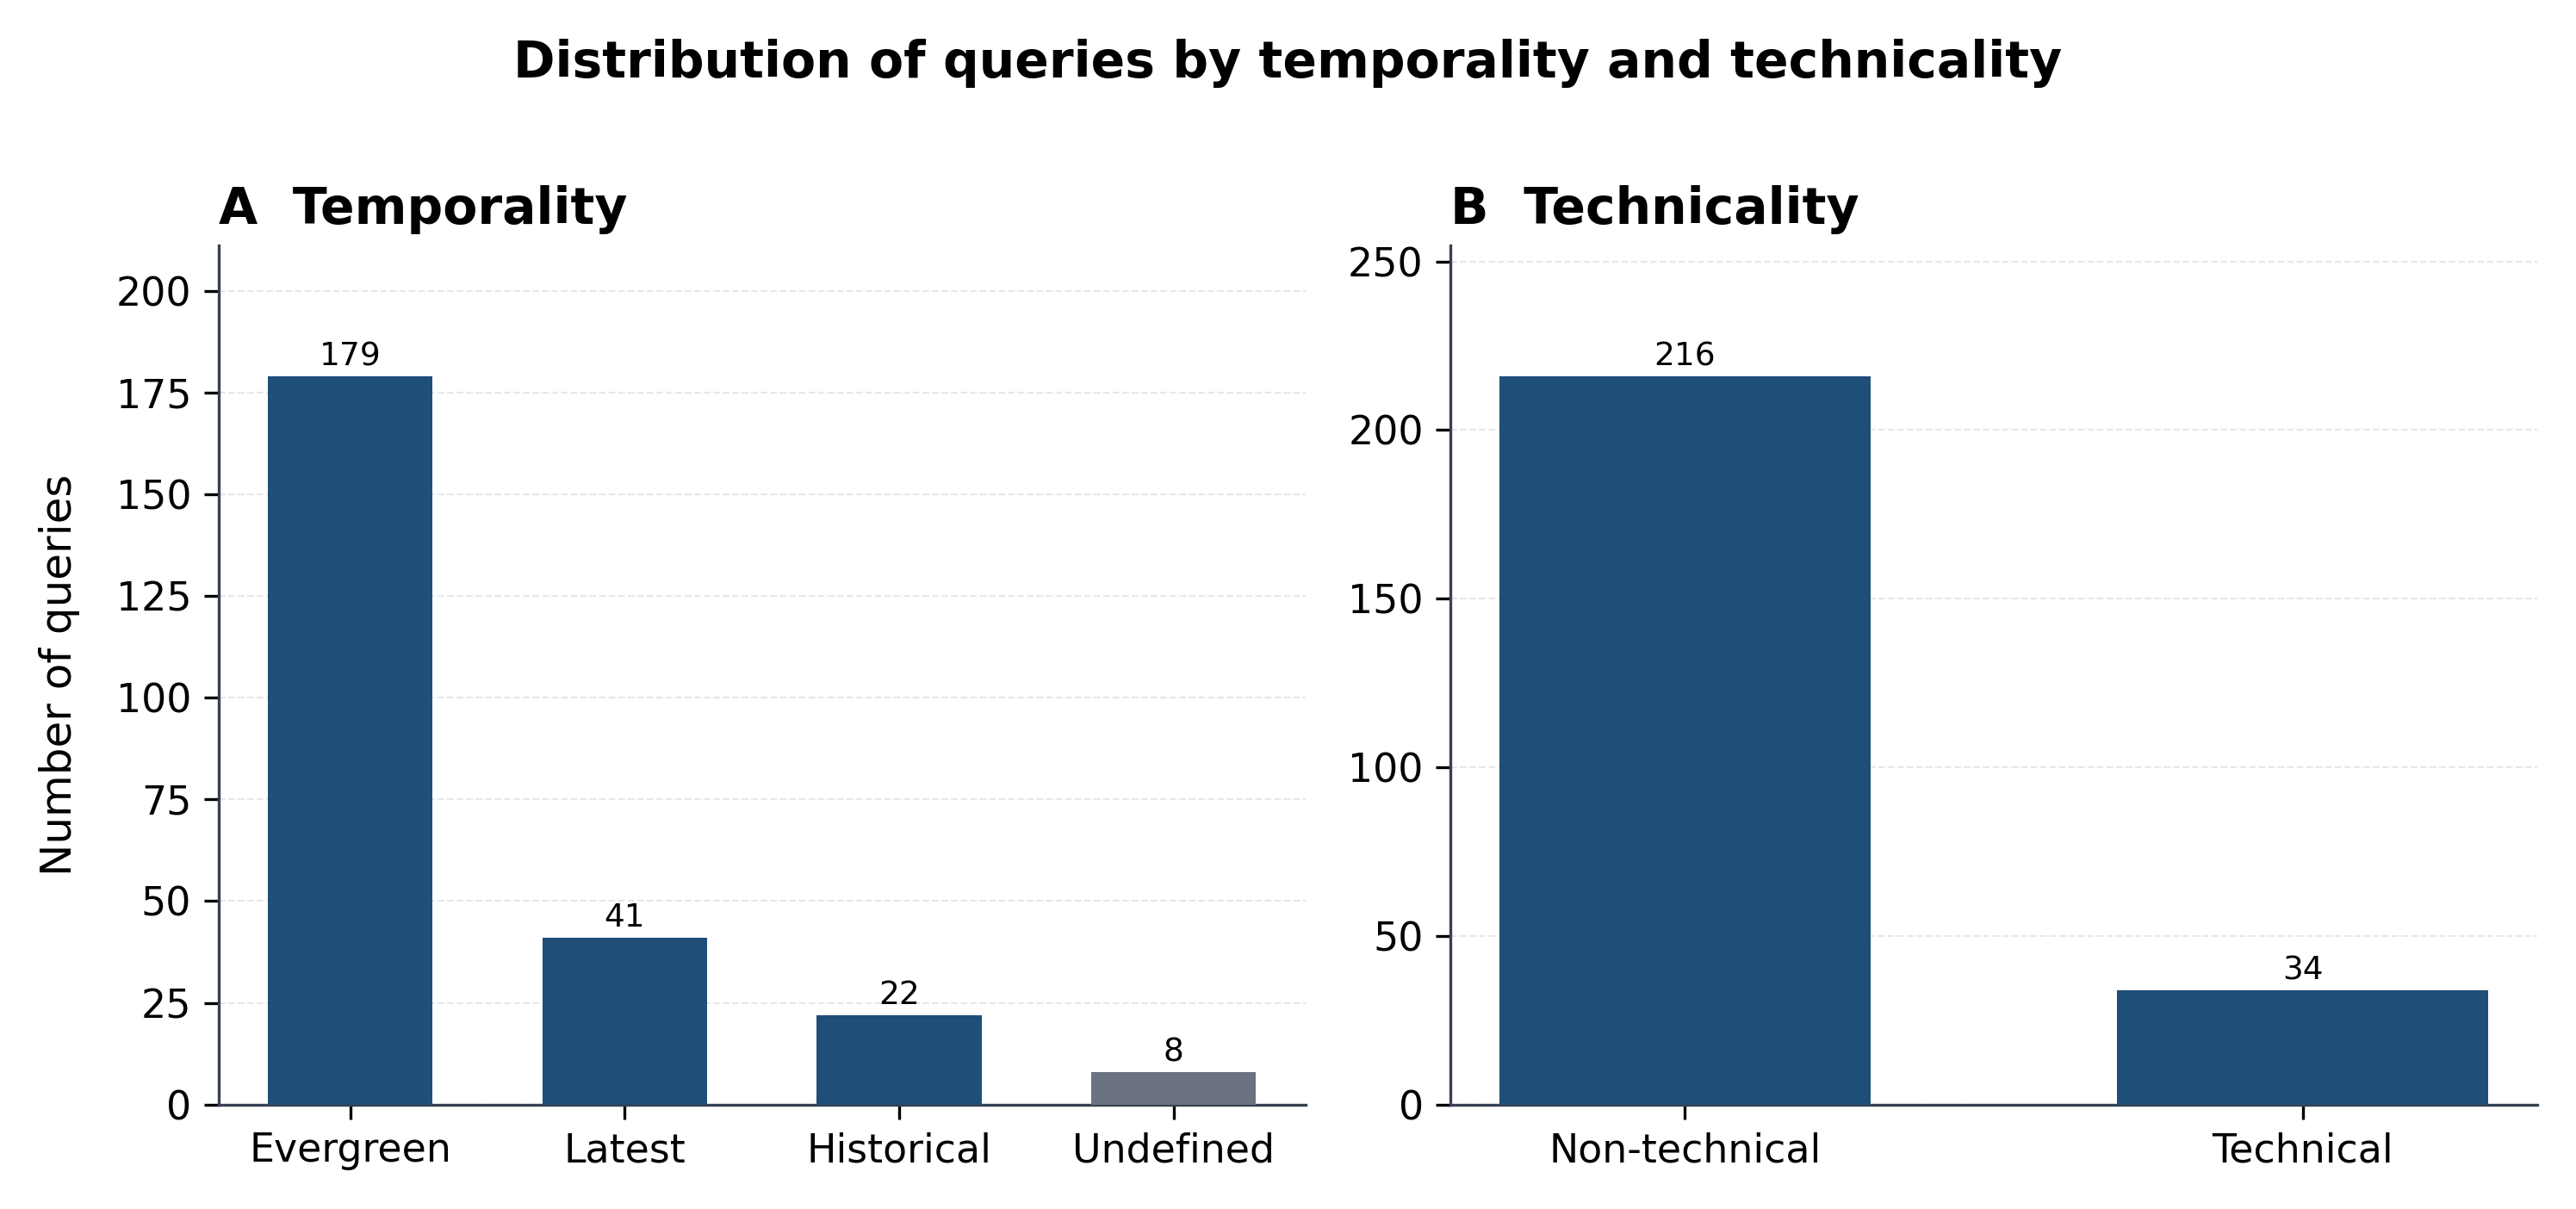

Temporality:
 temporality
evergreen     179
latest         41
historical     22
undefined       8

Technicality:
 technicality
non-technical    216
technical         34

ANALYSIS:
Evergreen queries dominate (179/250 = 72%); "latest" is the only meaningfully temporal
tier (41). "Undefined" (8) is de-emphasised — grey bar. Non-technical queries are 86%.
Both skews limit statistical power of temporality and technicality subgroup tests.

→ RQ2: Time-sensitive "latest" queries are expected to drive higher CV because content
       freshness varies between runs — the 41-query tier tests this hypothesis.



In [10]:
# E12 — fig_eda_06: two side-by-side bars
# E1: COLOUR_PRIMARY except "undefined" temporality bar stays COLOUR_NEUTRAL
# F3: no rotation on x-labels
ORDER_TEMP = ["evergreen", "latest", "historical", "undefined"]
ORDER_TECH = ["non-technical", "technical"]
vc_temp = rq["temporality"].value_counts().reindex(ORDER_TEMP)
vc_tech = rq["technicality"].value_counts().reindex(ORDER_TECH)

TEMP_COLOURS = [COLOUR_PRIMARY if t != "undefined" else COLOUR_NEUTRAL for t in ORDER_TEMP]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, vc, labels, colours, title in [
    (ax1, vc_temp, [l.capitalize() for l in ORDER_TEMP], TEMP_COLOURS, "A  Temporality"),
    (ax2, vc_tech, ["Non-technical", "Technical"],        [COLOUR_PRIMARY]*2, "B  Technicality"),
]:
    bars = ax.bar(labels, vc.values, width=0.6, color=colours, zorder=3)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(v), ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=14, fontweight="bold", loc="left")
    ax.set_ylabel("Number of queries" if ax is ax1 else "", fontsize=12, fontweight="medium")
    ax.set_ylim(0, vc.max() * 1.18)
    ax.tick_params(axis="x", labelrotation=0)   # F3: no rotation
    apply_style(ax)

fig.suptitle("Distribution of queries by temporality and technicality",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); savefig("fig_eda_06_temporality_technicality"); plt.show()
print("Temporality:\n", vc_temp.to_string())
print("\nTechnicality:\n", vc_tech.to_string())
print('''
ANALYSIS:
Evergreen queries dominate (179/250 = 72%); "latest" is the only meaningfully temporal
tier (41). "Undefined" (8) is de-emphasised — grey bar. Non-technical queries are 86%.
Both skews limit statistical power of temporality and technicality subgroup tests.

→ RQ2: Time-sensitive "latest" queries are expected to drive higher CV because content
       freshness varies between runs — the 41-query tier tests this hypothesis.
''')

---
## E13 · Distribution of PAWC_norm per engine

**Question:** What is the distribution of PAWC_norm per engine?

saved → figures/scaleup/fig_eda_07_pawcnorm_stacked.png/.pdf


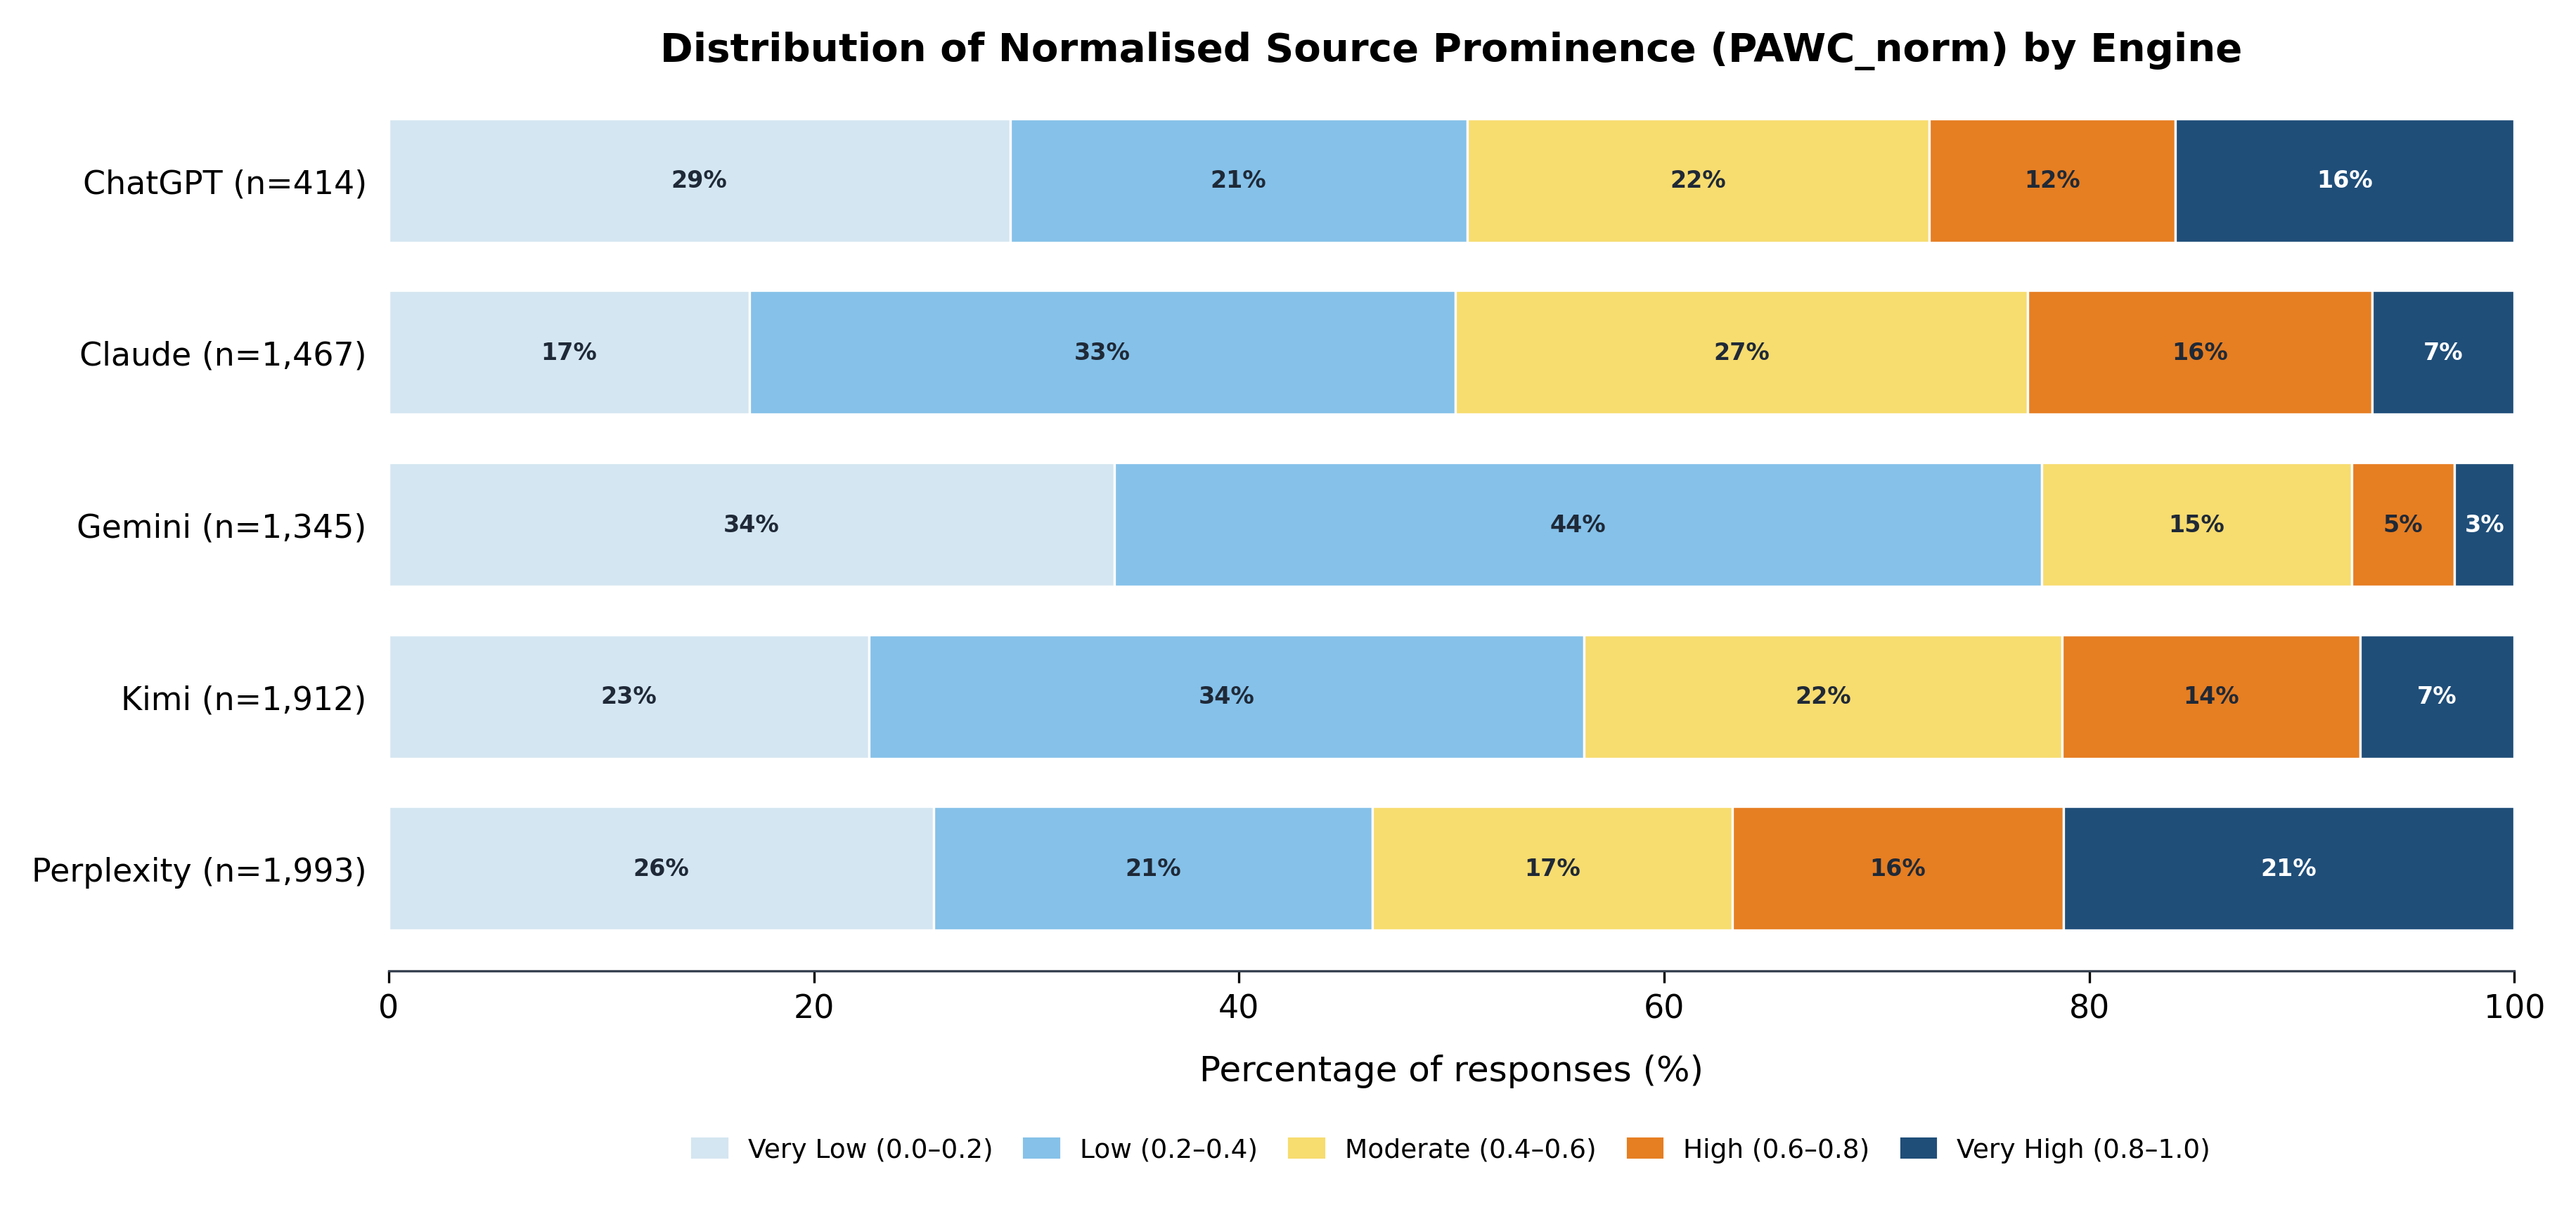

ChatGPT       n= 414  mean=0.422  median=0.388  sd=0.305
Claude        n=1467  mean=0.426  median=0.399  sd=0.226
Gemini        n=1345  mean=0.296  median=0.259  sd=0.194
Kimi          n=1912  mean=0.396  median=0.357  sd=0.240
Perplexity    n=1993  mean=0.464  median=0.429  sd=0.326

ANALYSIS:
Gemini concentrates lowest (78% of runs in the bottom two bands, 0–0.4); Perplexity is the
most top-heavy (21% Very High, 0.8–1.0, plus a Very-Low tail). Claude and Kimi peak in the
Low band (0.2–0.4). ChatGPT's 414 non-null runs spread fairly evenly across all five bands -
the spread within citation-bearing runs only.

→ RQ1: PAWC_norm is broadly distributed (0–1) for every engine; none consistently
       concentrates citations near the top position. ChatGPT's even spread reflects
       structural non-citation (1,586 null runs), not low prominence.



In [11]:
# E13 — fig_eda_07: PAWC_norm per engine — 100% stacked binned bar
data = stacked_bins("pawc_norm", r1,
    title="Distribution of Normalised Source Prominence (PAWC_norm) by Engine",
    figname="fig_eda_07_pawcnorm_stacked",
    bin_edges=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    bin_labels=["Very Low (0.0–0.2)", "Low (0.2–0.4)", "Moderate (0.4–0.6)",
                "High (0.6–0.8)", "Very High (0.8–1.0)"],
    colours=["#D4E6F1", "#85C1E9", "#F7DC6F", "#E67E22", "#1F4E79"],
    xlabel="Percentage of responses (%)")
for e, d in zip(ENGINE_ORDER, data):
    if len(d): print(f"{ENGINE_LABELS[e]:12s}  n={len(d):4d}  mean={d.mean():.3f}  median={float(np.median(d)):.3f}  sd={d.std():.3f}")
print('''
ANALYSIS:
Gemini concentrates lowest (78% of runs in the bottom two bands, 0–0.4); Perplexity is the
most top-heavy (21% Very High, 0.8–1.0, plus a Very-Low tail). Claude and Kimi peak in the
Low band (0.2–0.4). ChatGPT's 414 non-null runs spread fairly evenly across all five bands -
the spread within citation-bearing runs only.

→ RQ1: PAWC_norm is broadly distributed (0–1) for every engine; none consistently
       concentrates citations near the top position. ChatGPT's even spread reflects
       structural non-citation (1,586 null runs), not low prominence.
''')


---
## E14 · Distribution of AIS per engine

**Question:** What is the distribution of AIS per engine?

saved → figures/scaleup/fig_eda_08_ais_stacked.png/.pdf


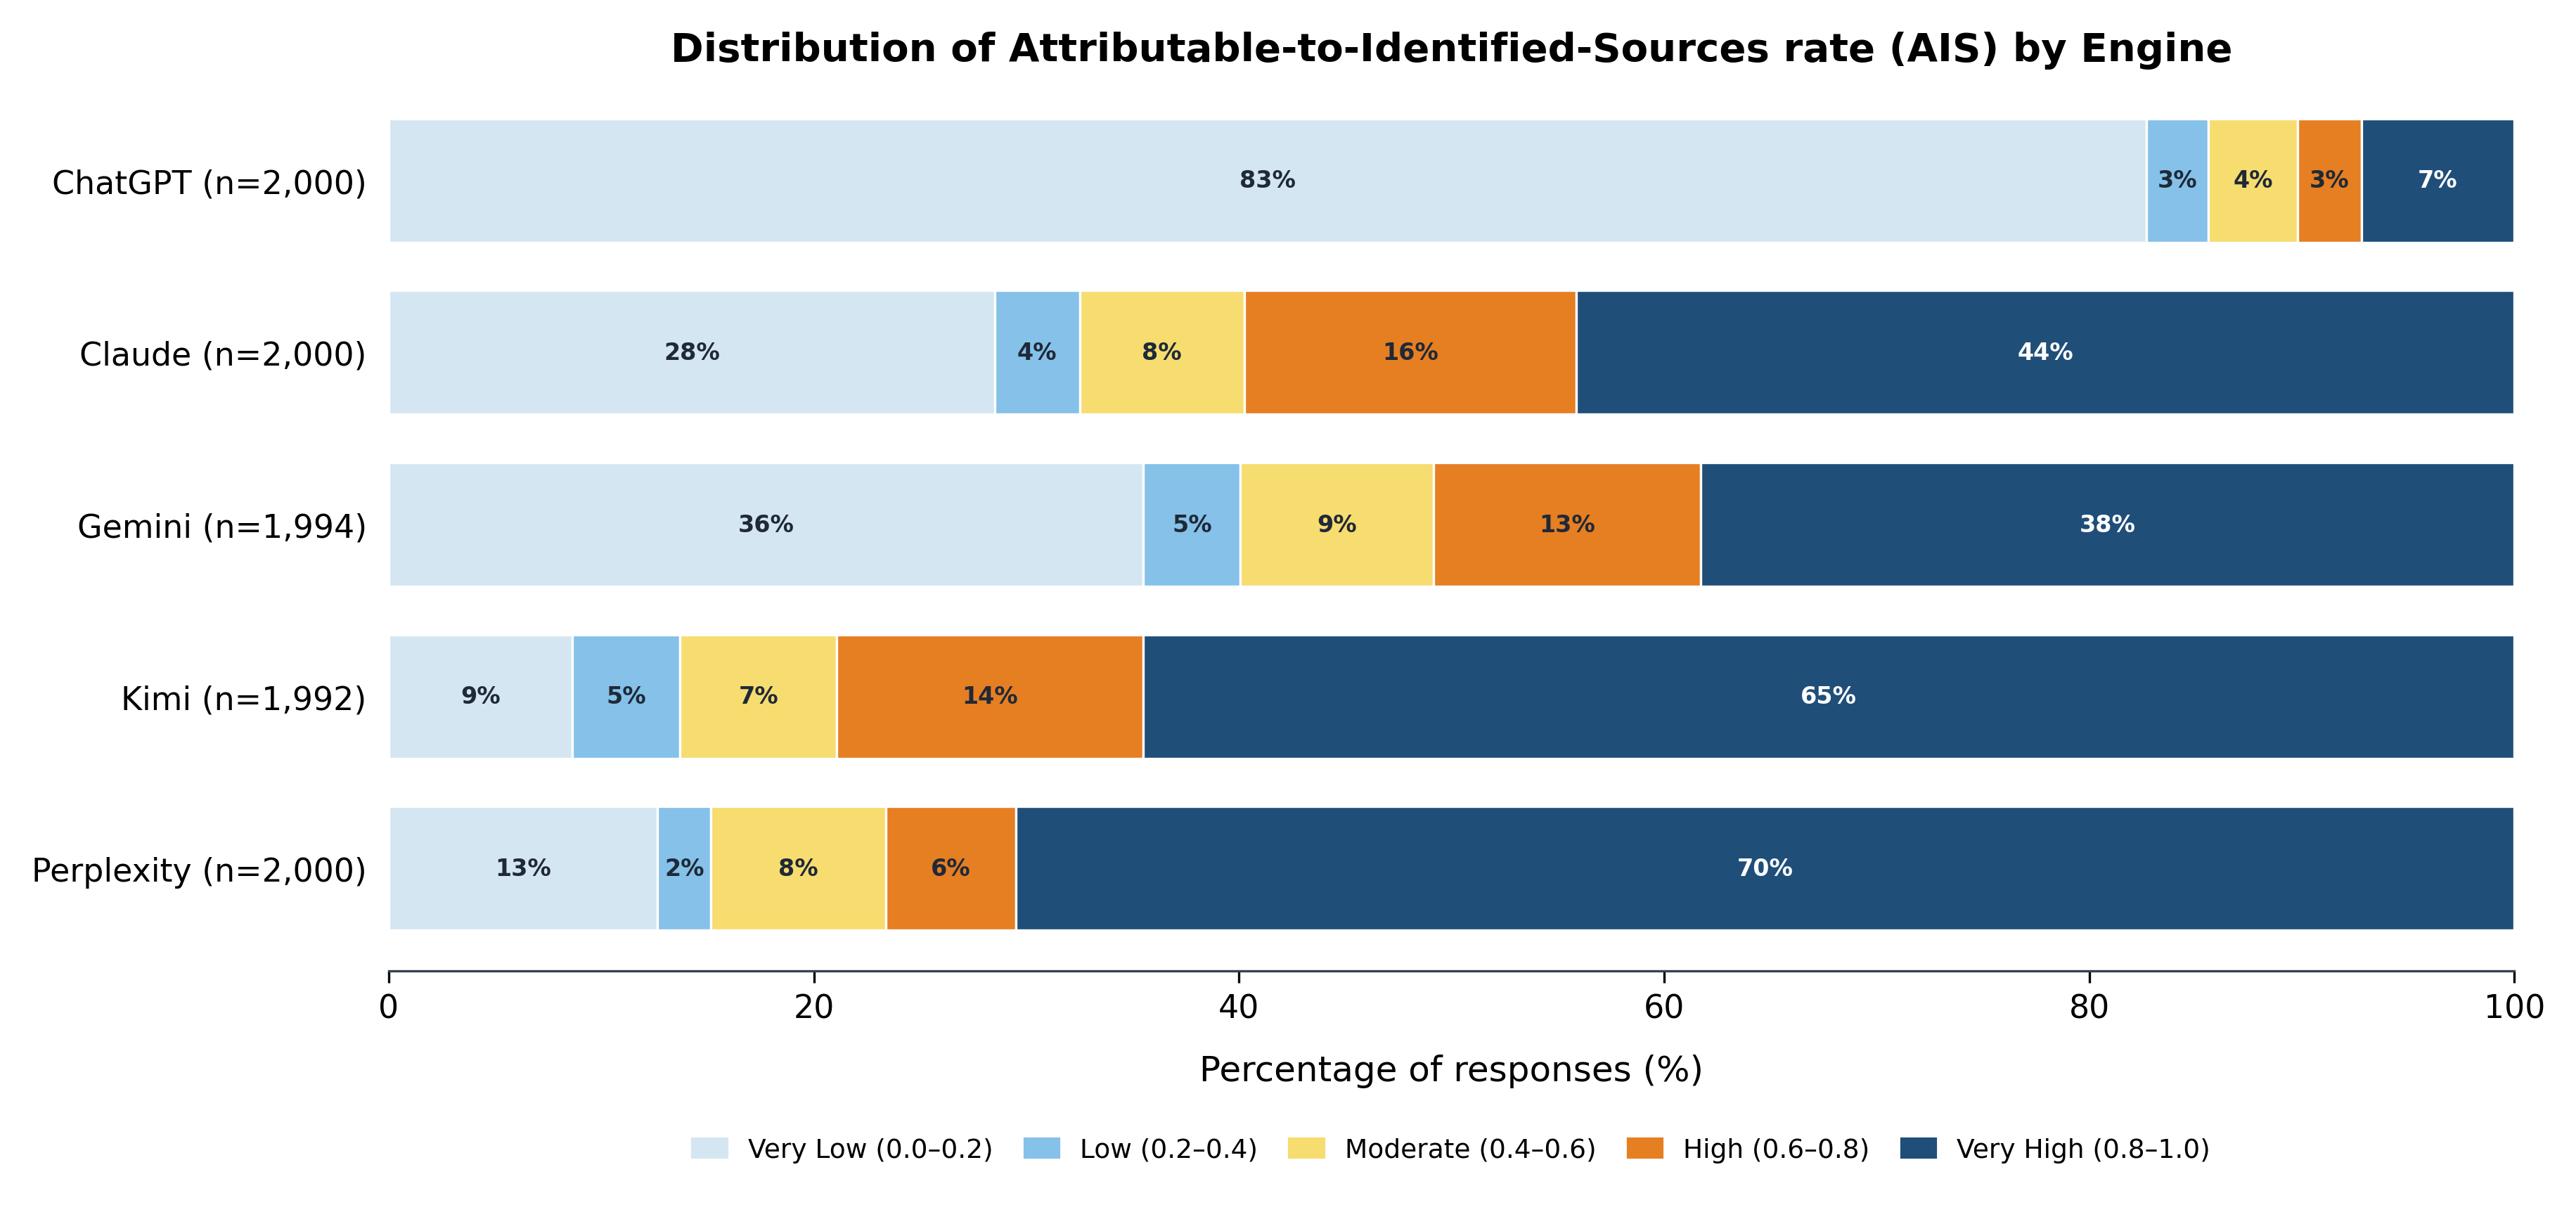

ChatGPT       n=2000  mean=0.120  median=0.000  sd=0.279
Claude        n=2000  mean=0.579  median=0.726  sd=0.404
Gemini        n=1994  mean=0.511  median=0.611  sd=0.415
Kimi          n=1992  mean=0.777  median=0.923  sd=0.303
Perplexity    n=2000  mean=0.793  median=1.000  sd=0.350

ANALYSIS:
ChatGPT puts 83% of runs in Very Low (AIS 0–0.2) - near-total structural non-citation.
Perplexity (70%) and Kimi (65%) are dominated by the Very High band (0.8–1.0), the most
reliably supported engines. Claude (44% Very High) and Gemini (38%) split between a Very-Low
pile and a Very-High cluster.

→ RQ3: ChatGPT's zero-pile is a structural non-citation artefact, not poor accuracy on the
       runs that do cite. Kimi and Perplexity most reliably support their claims; Claude and
       Gemini support a clear majority but carry a non-trivial unsupported tail.



In [12]:
# E14 — fig_eda_08: AIS per engine — 100% stacked binned bar
data = stacked_bins("cleaned_ais", r1,
    title="Distribution of Attributable-to-Identified-Sources rate (AIS) by Engine",
    figname="fig_eda_08_ais_stacked",
    bin_edges=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    bin_labels=["Very Low (0.0–0.2)", "Low (0.2–0.4)", "Moderate (0.4–0.6)",
                "High (0.6–0.8)", "Very High (0.8–1.0)"],
    colours=["#D4E6F1", "#85C1E9", "#F7DC6F", "#E67E22", "#1F4E79"],
    xlabel="Percentage of responses (%)")
for e, d in zip(ENGINE_ORDER, data):
    if len(d): print(f"{ENGINE_LABELS[e]:12s}  n={len(d):4d}  mean={d.mean():.3f}  median={float(np.median(d)):.3f}  sd={d.std():.3f}")
print('''
ANALYSIS:
ChatGPT puts 83% of runs in Very Low (AIS 0–0.2) - near-total structural non-citation.
Perplexity (70%) and Kimi (65%) are dominated by the Very High band (0.8–1.0), the most
reliably supported engines. Claude (44% Very High) and Gemini (38%) split between a Very-Low
pile and a Very-High cluster.

→ RQ3: ChatGPT's zero-pile is a structural non-citation artefact, not poor accuracy on the
       runs that do cite. Kimi and Perplexity most reliably support their claims; Claude and
       Gemini support a clear majority but carry a non-trivial unsupported tail.
''')


---
## E15 · Distribution of PAWC_norm CV per engine

**Question:** How stable is PAWC_norm across k=8 repeated runs of the same query?

saved → figures/scaleup/fig_eda_09_pawcnorm_cv_stacked.png/.pdf


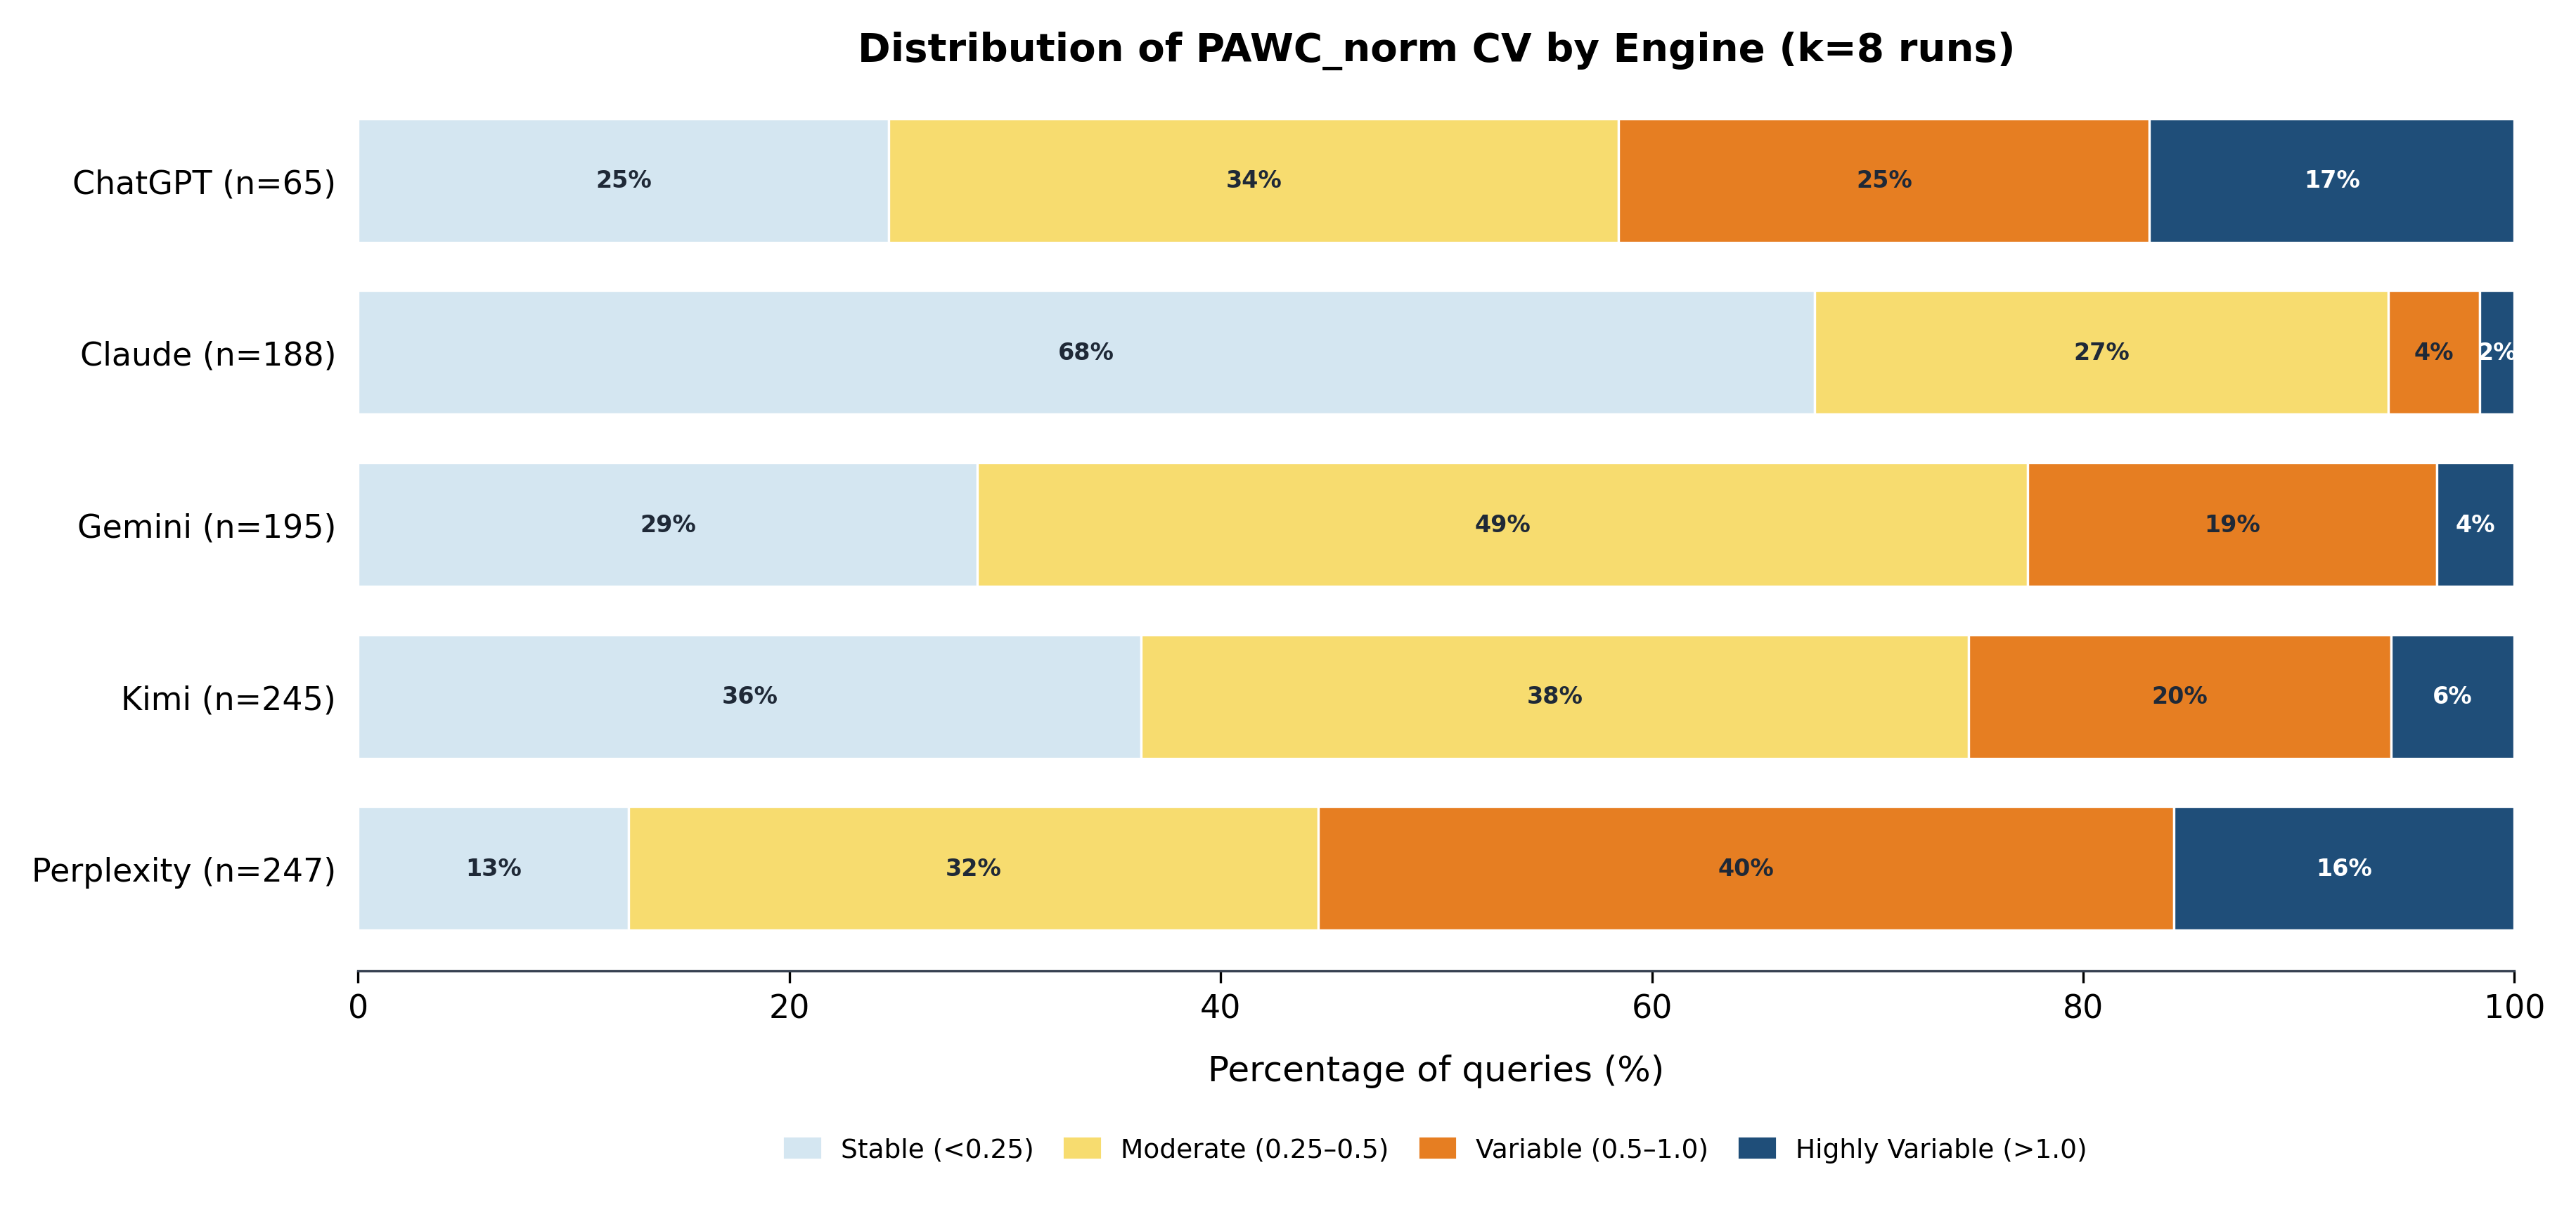

ChatGPT       n= 65  mean=0.566  median=0.425  max=1.779
Claude        n=188  mean=0.233  median=0.184  max=1.852
Gemini        n=195  mean=0.395  median=0.341  max=1.972
Kimi          n=245  mean=0.402  median=0.305  max=2.828
Perplexity    n=247  mean=0.653  median=0.524  max=2.828

ANALYSIS:
Claude is the most repeatable (68% of queries Stable, CV < 0.25); Perplexity the least
(40% Variable + 16% Highly Variable). Gemini and Kimi sit mostly in the Stable–Moderate
bands. ChatGPT rests on only 65 queries and is too sparse to read as a stable distribution.

→ RQ2: Source-prominence is repeatable for most queries, but high-CV queries - concentrated
       in Perplexity and ChatGPT - should not be trusted at single-run granularity;
       aggregate-level estimates are more reliable.



In [13]:
# E15 — fig_eda_09: PAWC_norm CV per engine — 100% stacked binned bar
data = stacked_bins("pawc_norm_cv", ca,
    title="Distribution of PAWC_norm CV by Engine (k=8 runs)",
    figname="fig_eda_09_pawcnorm_cv_stacked",
    bin_edges=[0, 0.25, 0.5, 1.0, np.inf],
    bin_labels=["Stable (<0.25)", "Moderate (0.25–0.5)", "Variable (0.5–1.0)",
                "Highly Variable (>1.0)"],
    colours=["#D4E6F1", "#F7DC6F", "#E67E22", "#1F4E79"],
    xlabel="Percentage of queries (%)")
for e, d in zip(ENGINE_ORDER, data):
    if len(d): print(f"{ENGINE_LABELS[e]:12s}  n={len(d):3d}  mean={d.mean():.3f}  median={float(np.median(d)):.3f}  max={d.max():.3f}")
print('''
ANALYSIS:
Claude is the most repeatable (68% of queries Stable, CV < 0.25); Perplexity the least
(40% Variable + 16% Highly Variable). Gemini and Kimi sit mostly in the Stable–Moderate
bands. ChatGPT rests on only 65 queries and is too sparse to read as a stable distribution.

→ RQ2: Source-prominence is repeatable for most queries, but high-CV queries - concentrated
       in Perplexity and ChatGPT - should not be trusted at single-run granularity;
       aggregate-level estimates are more reliable.
''')


---
## E16 · Distribution of AIS CV per engine

**Question:** How stable is AIS across k=8 repeated runs of the same query?

saved → figures/scaleup/fig_eda_10_ais_cv_stacked.png/.pdf


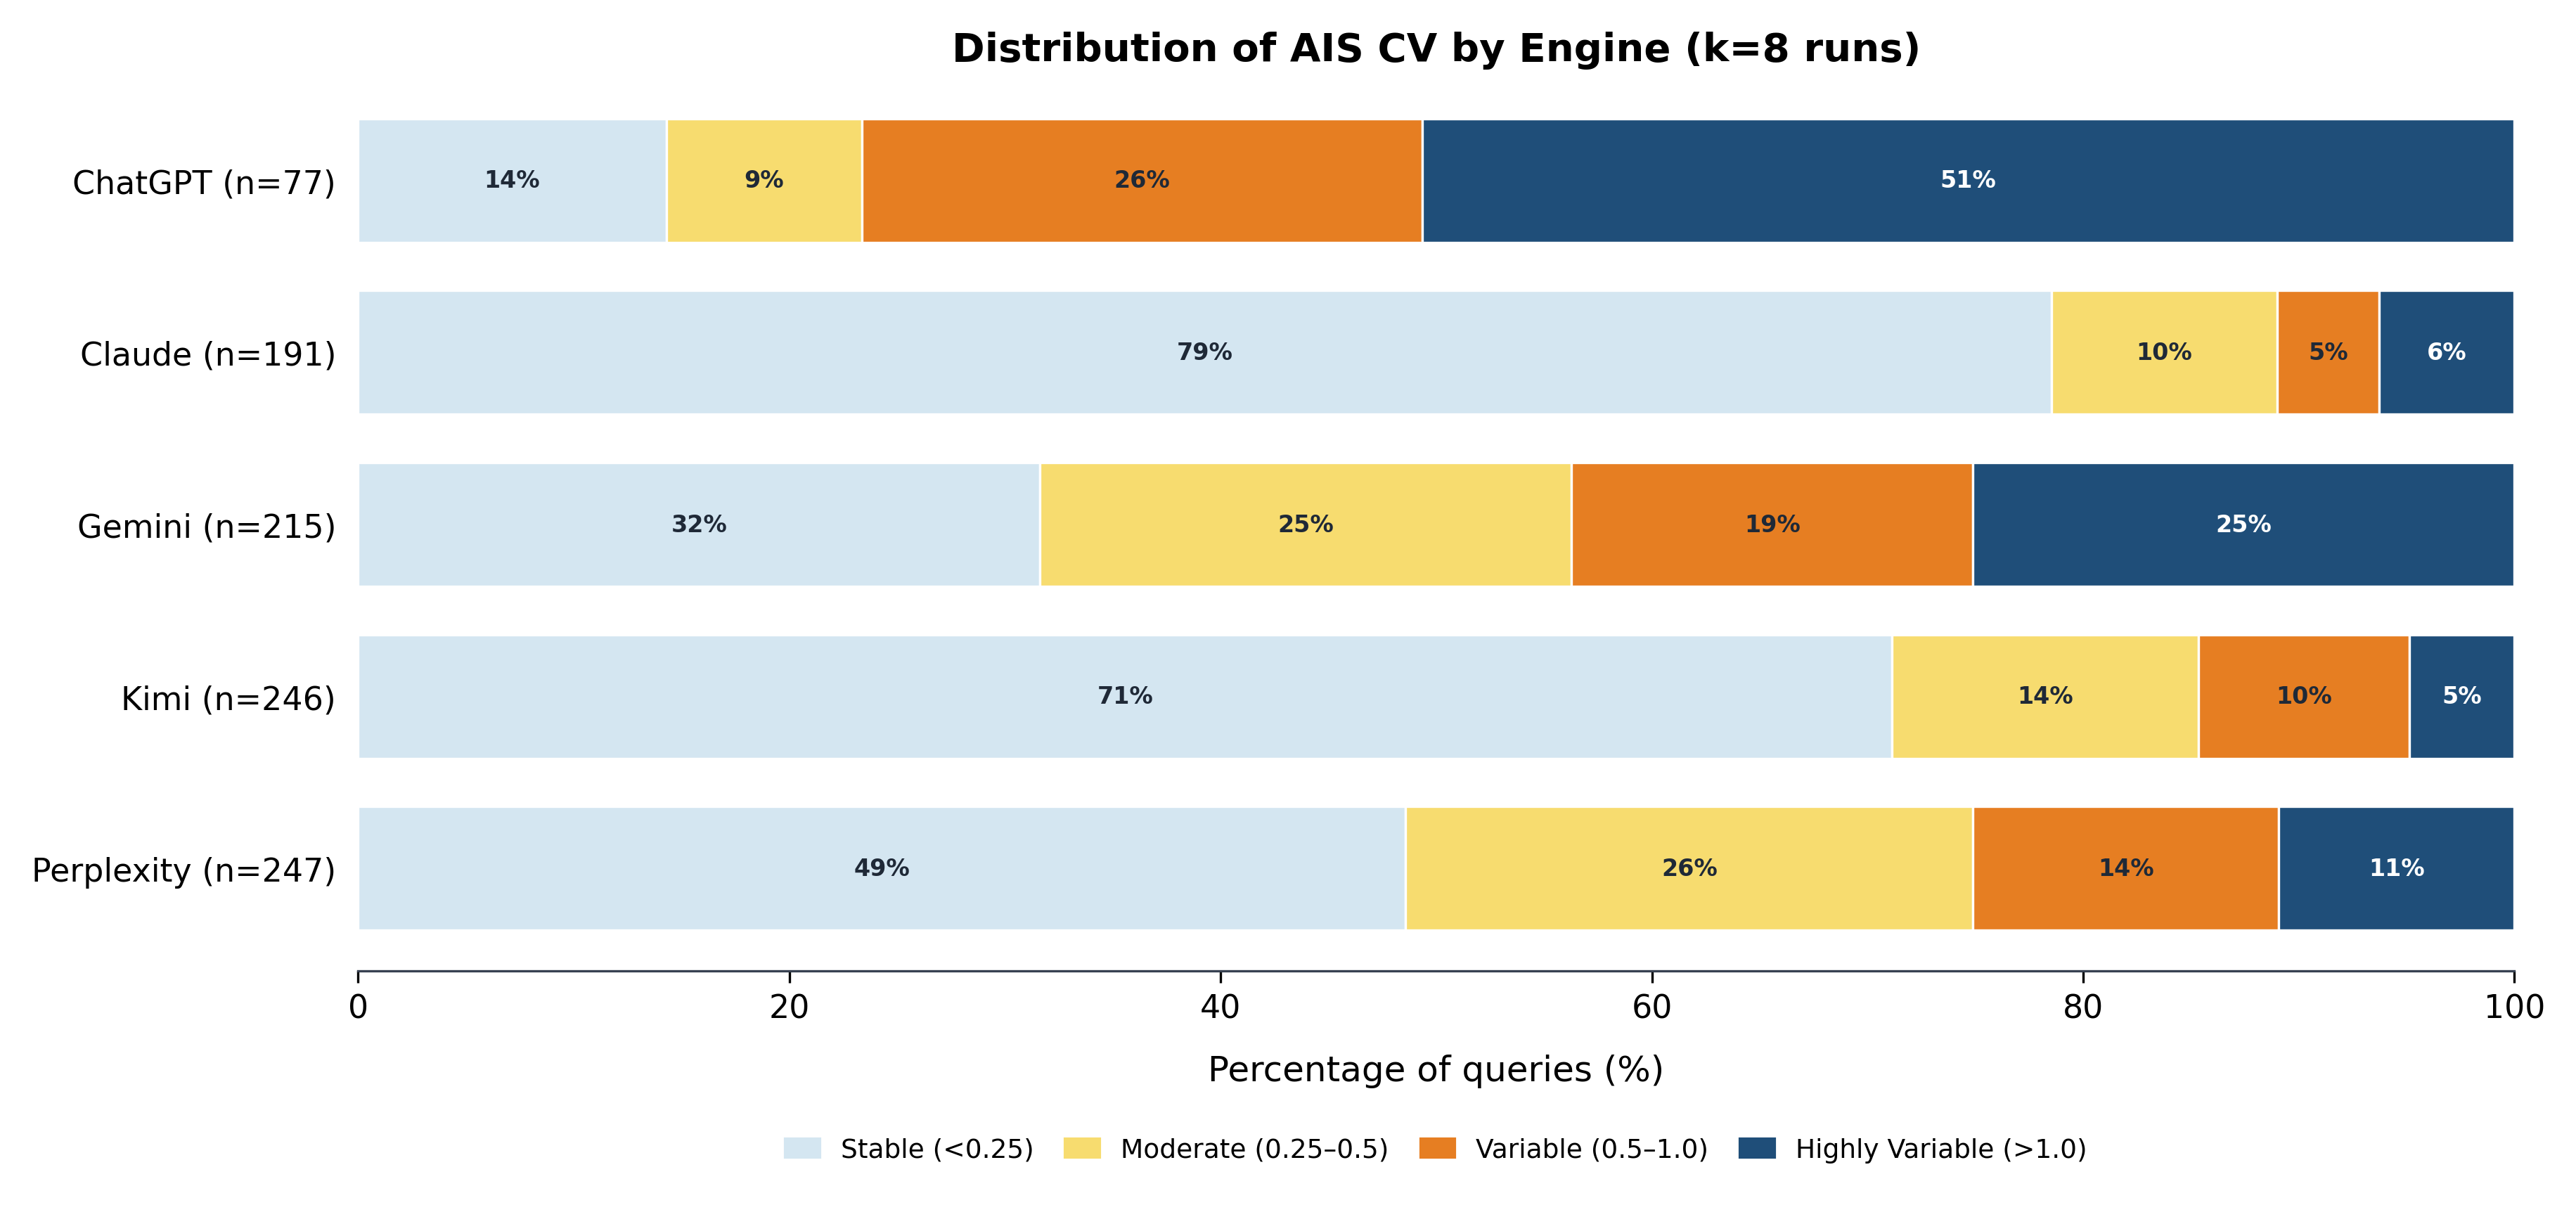

ChatGPT       n= 77  mean=1.207  median=1.048  max=2.828
Claude        n=191  mean=0.247  median=0.089  max=2.828
Gemini        n=215  mean=0.777  median=0.418  max=2.828
Kimi          n=246  mean=0.274  median=0.131  max=2.828
Perplexity    n=247  mean=0.390  median=0.265  max=2.828

ANALYSIS:
AIS stability splits sharply: Claude (79%) and Kimi (71%) are overwhelmingly Stable - more
stable on AIS than on PAWC_norm. ChatGPT is the opposite (51% Highly Variable, CV > 1.0), and
Gemini carries 25% Highly Variable, because near-zero citation makes AIS flip between 0 and
non-zero across runs.

→ RQ2: AIS is the more reliable metric for engines that routinely cite (Claude, Kimi,
       Perplexity), favouring AIS over PAWC_norm for single-run designs. For ChatGPT and
       Gemini, binary on/off citation inflates AIS CV - single-run AIS is unreliable there
       and should be aggregated.



In [14]:
# E16 — fig_eda_10: AIS CV per engine — 100% stacked binned bar
data = stacked_bins("ais_cv", ca,
    title="Distribution of AIS CV by Engine (k=8 runs)",
    figname="fig_eda_10_ais_cv_stacked",
    bin_edges=[0, 0.25, 0.5, 1.0, np.inf],
    bin_labels=["Stable (<0.25)", "Moderate (0.25–0.5)", "Variable (0.5–1.0)",
                "Highly Variable (>1.0)"],
    colours=["#D4E6F1", "#F7DC6F", "#E67E22", "#1F4E79"],
    xlabel="Percentage of queries (%)")
for e, d in zip(ENGINE_ORDER, data):
    if len(d): print(f"{ENGINE_LABELS[e]:12s}  n={len(d):3d}  mean={d.mean():.3f}  median={float(np.median(d)):.3f}  max={d.max():.3f}")
print('''
ANALYSIS:
AIS stability splits sharply: Claude (79%) and Kimi (71%) are overwhelmingly Stable - more
stable on AIS than on PAWC_norm. ChatGPT is the opposite (51% Highly Variable, CV > 1.0), and
Gemini carries 25% Highly Variable, because near-zero citation makes AIS flip between 0 and
non-zero across runs.

→ RQ2: AIS is the more reliable metric for engines that routinely cite (Claude, Kimi,
       Perplexity), favouring AIS over PAWC_norm for single-run designs. For ChatGPT and
       Gemini, binary on/off citation inflates AIS CV - single-run AIS is unreliable there
       and should be aggregated.
''')


---
## E17 · PAWC_norm vs AIS relationship per engine

**Question:** How do PAWC_norm and AIS relate to each other within each engine?

saved → figures/scaleup/fig_eda_11_pawcnorm_vs_ais.png/.pdf


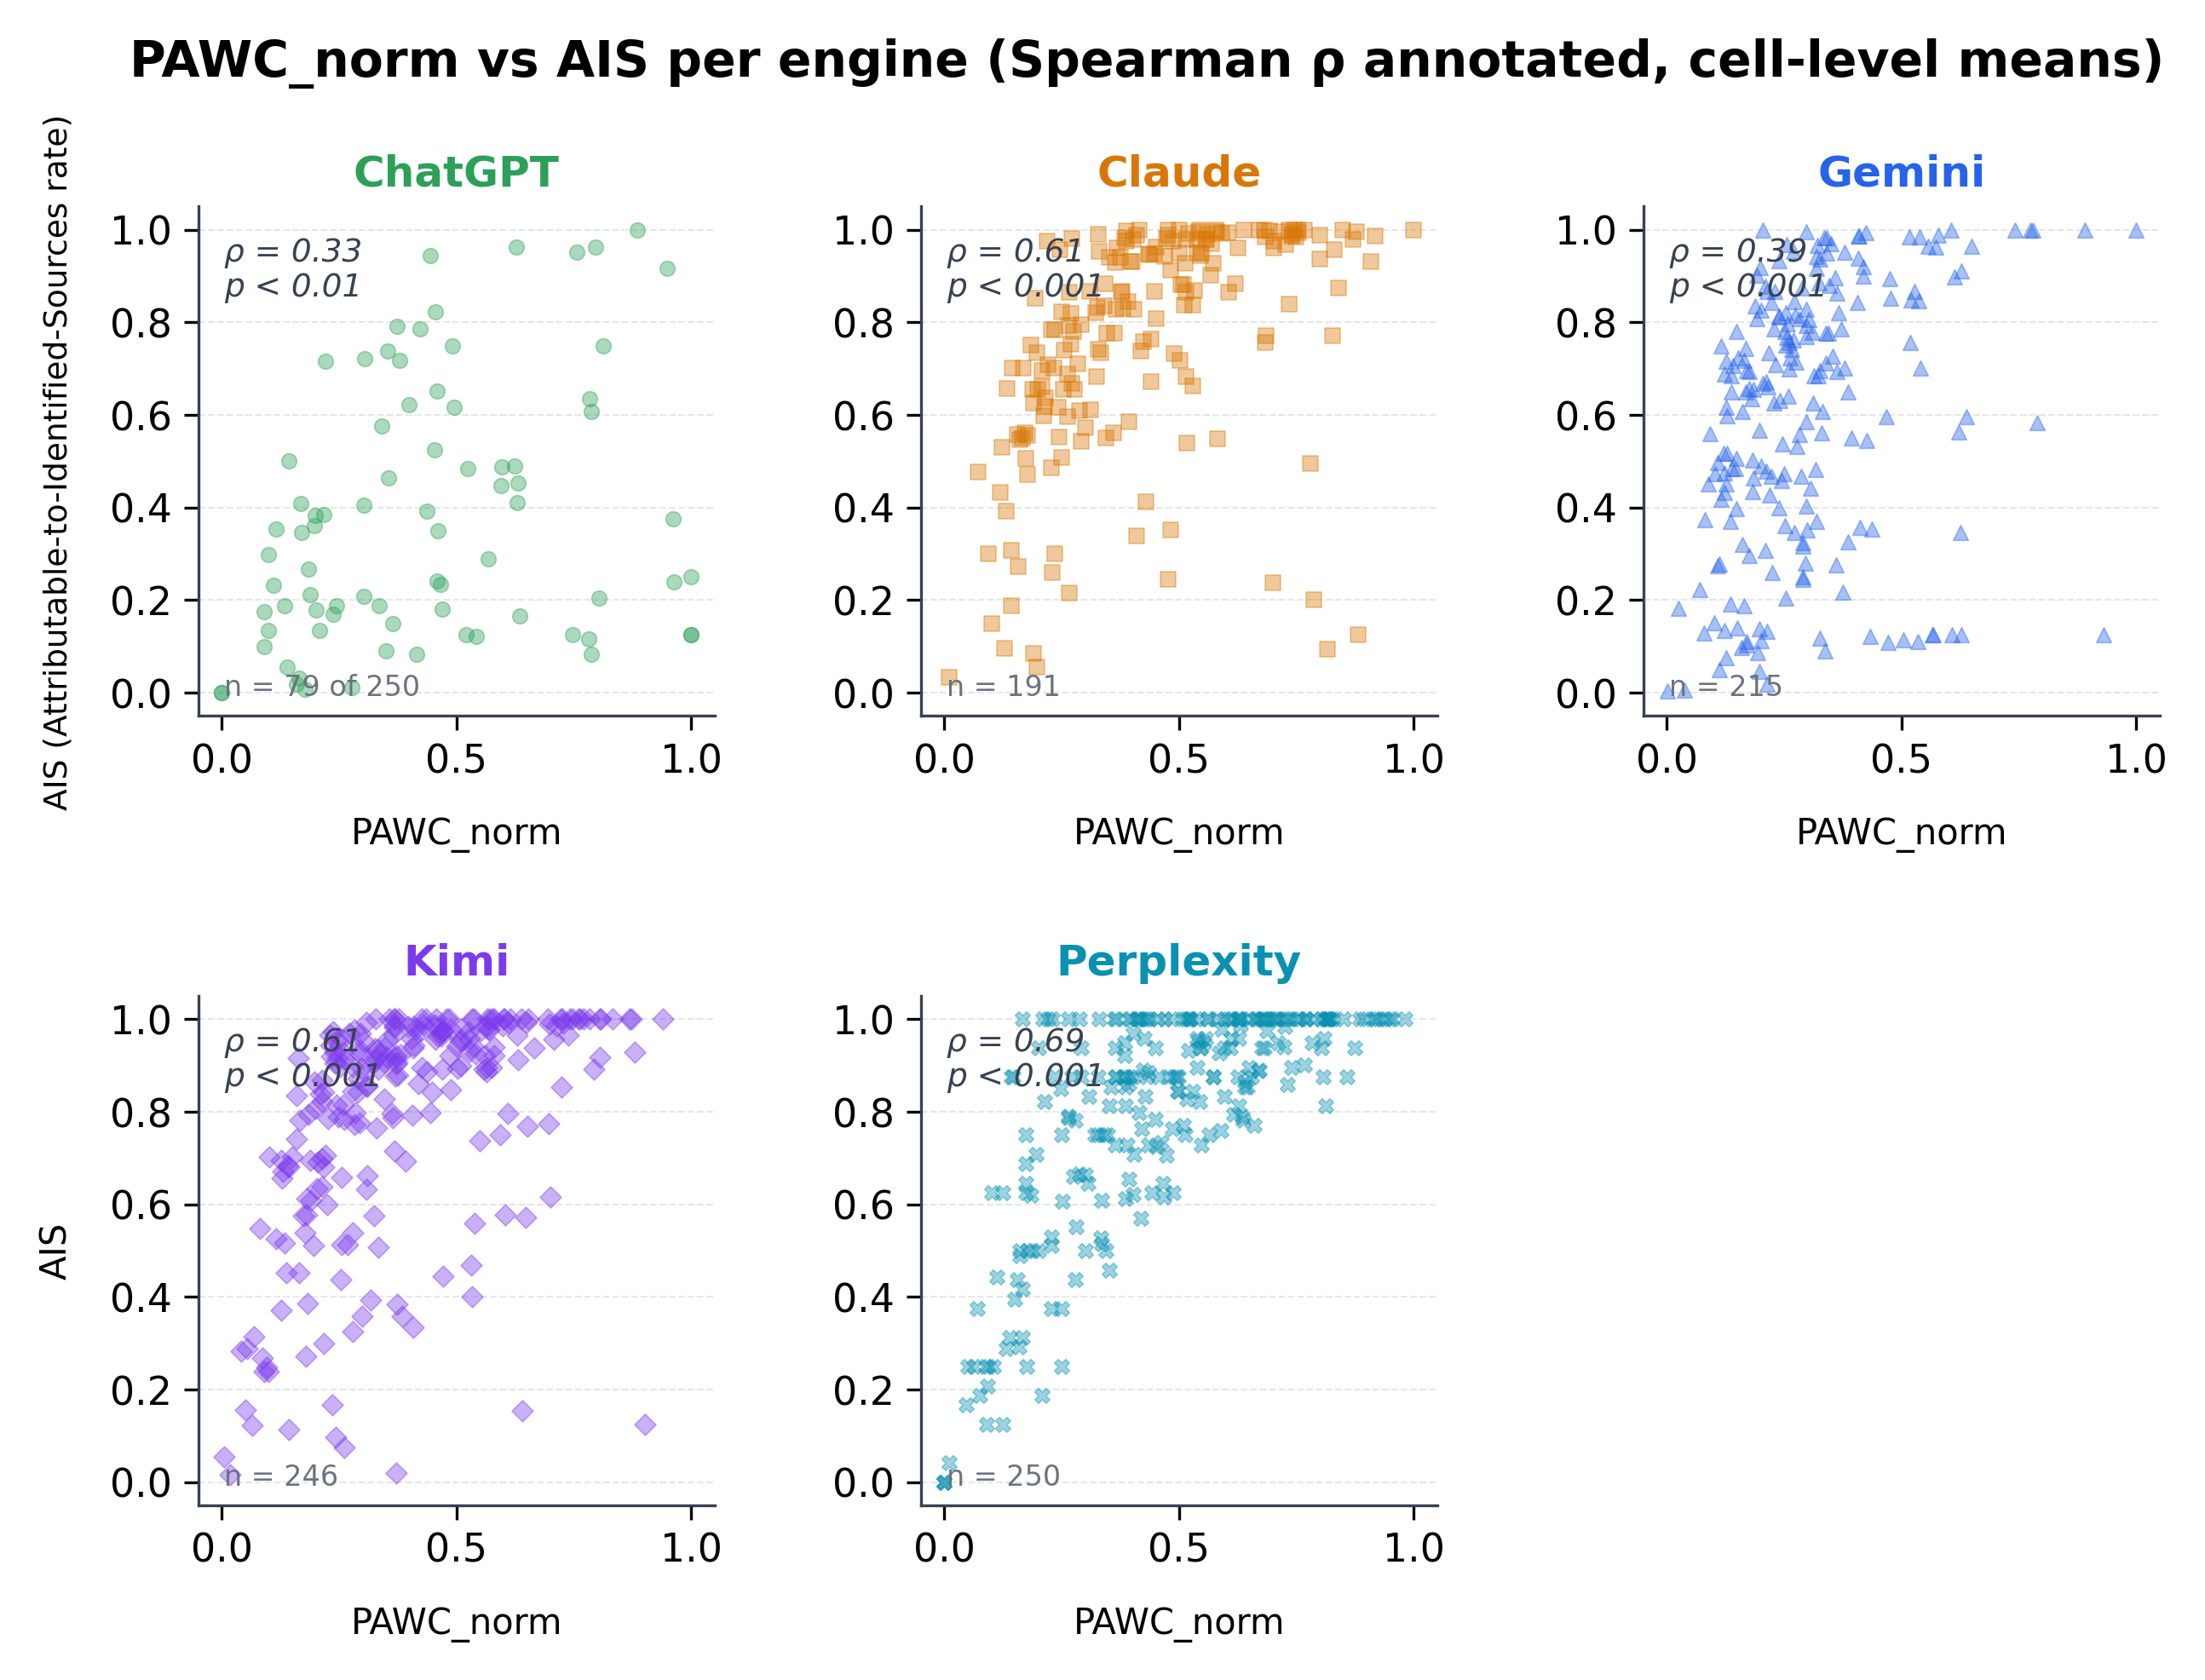


ANALYSIS:
PAWC_norm and AIS correlation is engine-dependent: weak for ChatGPT (rho 0.33) and Gemini
(0.39), but moderate-to-strong for Claude (0.61), Kimi (0.61) and Perplexity (0.69) — for
those, higher prominence often coincides with more accurate citation. ChatGPT's sparse
non-null PAWC data (79 of 250 cells) makes its estimate unreliable.

→ RQ1 + RQ3: Visibility and accuracy are largely independent only for ChatGPT and Gemini;
             for the engines that routinely cite they move together — the cross-metric
             relationship is engine-dependent, not uniform.



In [15]:
# E17 — fig_eda_11: 2×3 faceted scatter; F2: y-labels by column index not engine name
# B4: ChatGPT stated as 79 of 250 query-cells
fig, axes = plt.subplots(2, 3, figsize=(9.9, 6.6),
                          gridspec_kw={"hspace": 0.55, "wspace": 0.4})
axes = axes.flatten()
axes[-1].set_visible(False)

for i, (ax, eng) in enumerate(zip(axes[:5], ENGINE_ORDER)):
    sub = ca[ca.engine == eng][["pawc_norm_mean","ais_mean"]].dropna()
    x, y = sub["pawc_norm_mean"].values, sub["ais_mean"].values
    c = ENGINE_COLOURS[eng]
    ax.scatter(x, y, alpha=0.4, s=18, color=c, edgecolors=c,
               linewidths=0.4, marker=ENGINE_MARKERS[eng], zorder=3)
    if len(x) >= 3:
        rho, pval = stats.spearmanr(x, y)
        p_str = ("p < 0.001" if pval < 0.001 else "p < 0.01" if pval < 0.01
                 else "p < 0.05" if pval < 0.05 else f"p = {pval:.3f}")
        ax.text(0.05, 0.94, f"\u03c1 = {rho:.2f}\n{p_str}", transform=ax.transAxes,
                fontsize=9, va="top", fontstyle="italic", color="#374151")
    # B4: explicit denominator for ChatGPT
    n_label = f"n = {len(x)} of 250" if eng == "chatgpt" else f"n = {len(x)}"
    ax.text(0.05, 0.04, n_label, transform=ax.transAxes, fontsize=8, color=COLOUR_NEUTRAL)
    ax.set_title(ENGINE_LABELS[eng], fontsize=12, fontweight="bold", color=c)
    ax.set_xlabel("PAWC_norm", fontsize=10, fontweight="medium")
    # F2: y-label by column index (i % 3 == 0), not hardcoded engine name
    if i == 0:
        ax.set_ylabel("AIS (Attributable-to-Identified-Sources rate)", fontsize=9, fontweight="medium")
    elif i == 3:
        ax.set_ylabel("AIS", fontsize=10, fontweight="medium")
    else:
        ax.set_ylabel("")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    apply_style(ax)

fig.suptitle("PAWC_norm vs AIS per engine (Spearman \u03c1 annotated, cell-level means)",
             fontsize=14, fontweight="bold")
plt.savefig(FIG_DIR / "fig_eda_11_pawcnorm_vs_ais.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_eda_11_pawcnorm_vs_ais.pdf", bbox_inches="tight")
print("saved → figures/scaleup/fig_eda_11_pawcnorm_vs_ais.png/.pdf")
plt.show()
print('''
ANALYSIS:
PAWC_norm and AIS correlation is engine-dependent: weak for ChatGPT (rho 0.33) and Gemini
(0.39), but moderate-to-strong for Claude (0.61), Kimi (0.61) and Perplexity (0.69) — for
those, higher prominence often coincides with more accurate citation. ChatGPT's sparse
non-null PAWC data (79 of 250 cells) makes its estimate unreliable.

→ RQ1 + RQ3: Visibility and accuracy are largely independent only for ChatGPT and Gemini;
             for the engines that routinely cite they move together — the cross-metric
             relationship is engine-dependent, not uniform.
''')

---
## E18 · Summary descriptive statistics (all metrics × all engines)

**Reference table** for all numbers cited in findings.

In [16]:
# E18 — reference summary table; B1: correct AIS label
rows = []
for eng in ENGINE_ORDER:
    sub, sub_ca = r1[r1.engine == eng], ca[ca.engine == eng]
    for col, label, src in [
        ("cleaned_ais",  "AIS (Attr-to-Id-Sources rate)", sub),
        ("pawc_norm",    "PAWC_norm",                     sub),
        ("n_sentences",  "Sentences",                     sub),
        ("pawc_norm_cv", "PAWC_norm CV",                  sub_ca),
        ("ais_cv",       "AIS CV",                        sub_ca),
    ]:
        s = src[col].dropna()
        rows.append({"Engine": ENGINE_LABELS[eng], "Metric": label,
                     "n": len(s), "Mean": round(s.mean(),4),
                     "Median": round(s.median(),4), "SD": round(s.std(),4),
                     "Min": round(s.min(),4), "Max": round(s.max(),4)})

tbl = pd.DataFrame(rows).set_index(["Engine","Metric"])
print("E18 · Baseline reference table\n" + "="*72)
print(tbl.to_string())
print('''
ANALYSIS:
Single-page baseline for all numbers cited in findings. Perplexity and Kimi lead AIS;
Perplexity and ChatGPT lead mean PAWC_norm (ChatGPT's rests on only 79 citing cells, so Claude is effectively tied). AIS CV is lower than PAWC_norm CV only for Kimi and Perplexity; it is HIGHER for
ChatGPT, Claude and Gemini, so neither metric is uniformly more stable (see E16).

→ RQ1: PAWC_norm mean/SD per engine; null count reveals structural non-citation.
→ RQ2: CV columns are the direct measurement-stability evidence.
→ RQ3: AIS mean/median per engine; note ChatGPT 0 floor vs conditional mean.
''')

E18 · Baseline reference table
                                             n   Mean  Median     SD   Min      Max
Engine     Metric                                                                  
ChatGPT    AIS (Attr-to-Id-Sources rate)  2000  0.120   0.000  0.280 0.000    1.000
           PAWC_norm                       414  0.422   0.388  0.305 0.000    1.000
           Sentences                      2000 19.524  12.000 23.868 1.000  274.000
           PAWC_norm CV                     65  0.566   0.425  0.427 0.000    1.780
           AIS CV                           77  1.207   1.048  0.905 0.000    2.828
Claude     AIS (Attr-to-Id-Sources rate)  2000  0.579   0.726  0.404 0.000    1.000
           PAWC_norm                      1467  0.426   0.399  0.226 0.000    1.000
           Sentences                      2000 28.175  28.000 14.862 1.000   83.000
           PAWC_norm CV                    188  0.233   0.184  0.228 0.000    1.852
           AIS CV                          19

---
## E1 · PAWC_norm by domain × engine (heatmap)

**Question:** How does PAWC_norm vary by domain across the five engines?

Domain → Meta-domain mapping:
{
  "physics": "STEM",
  "biology": "STEM",
  "science": "STEM",
  "engineering": "STEM",
  "environment": "STEM",
  "computers and electronics": "Technology",
  "internet and telecom": "Technology",
  "technology": "Technology",
  "health": "Health",
  "arts and entertainment": "Arts & Culture",
  "books and literature": "Arts & Culture",
  "language": "Arts & Culture",
  "philosophy": "Arts & Culture",
  "religion": "Arts & Culture",
  "games": "Arts & Culture",
  "law": "Law & Politics",
  "law and government": "Law & Politics",
  "politics": "Law & Politics",
  "military": "Law & Politics",
  "business and industrial": "Business & Finance",
  "finance": "Business & Finance",
  "jobs and education": "Business & Finance",
  "food and drink": "Lifestyle",
  "travel": "Lifestyle",
  "pets and animals": "Lifestyle",
  "automotive": "Lifestyle",
  "sports": "Lifestyle",
  "people and society": "People & Society",
  "history": "People & Society",
  "geography

saved → figures/scaleup/fig_eda_12_pawcnorm_domain_heatmap.png/.pdf


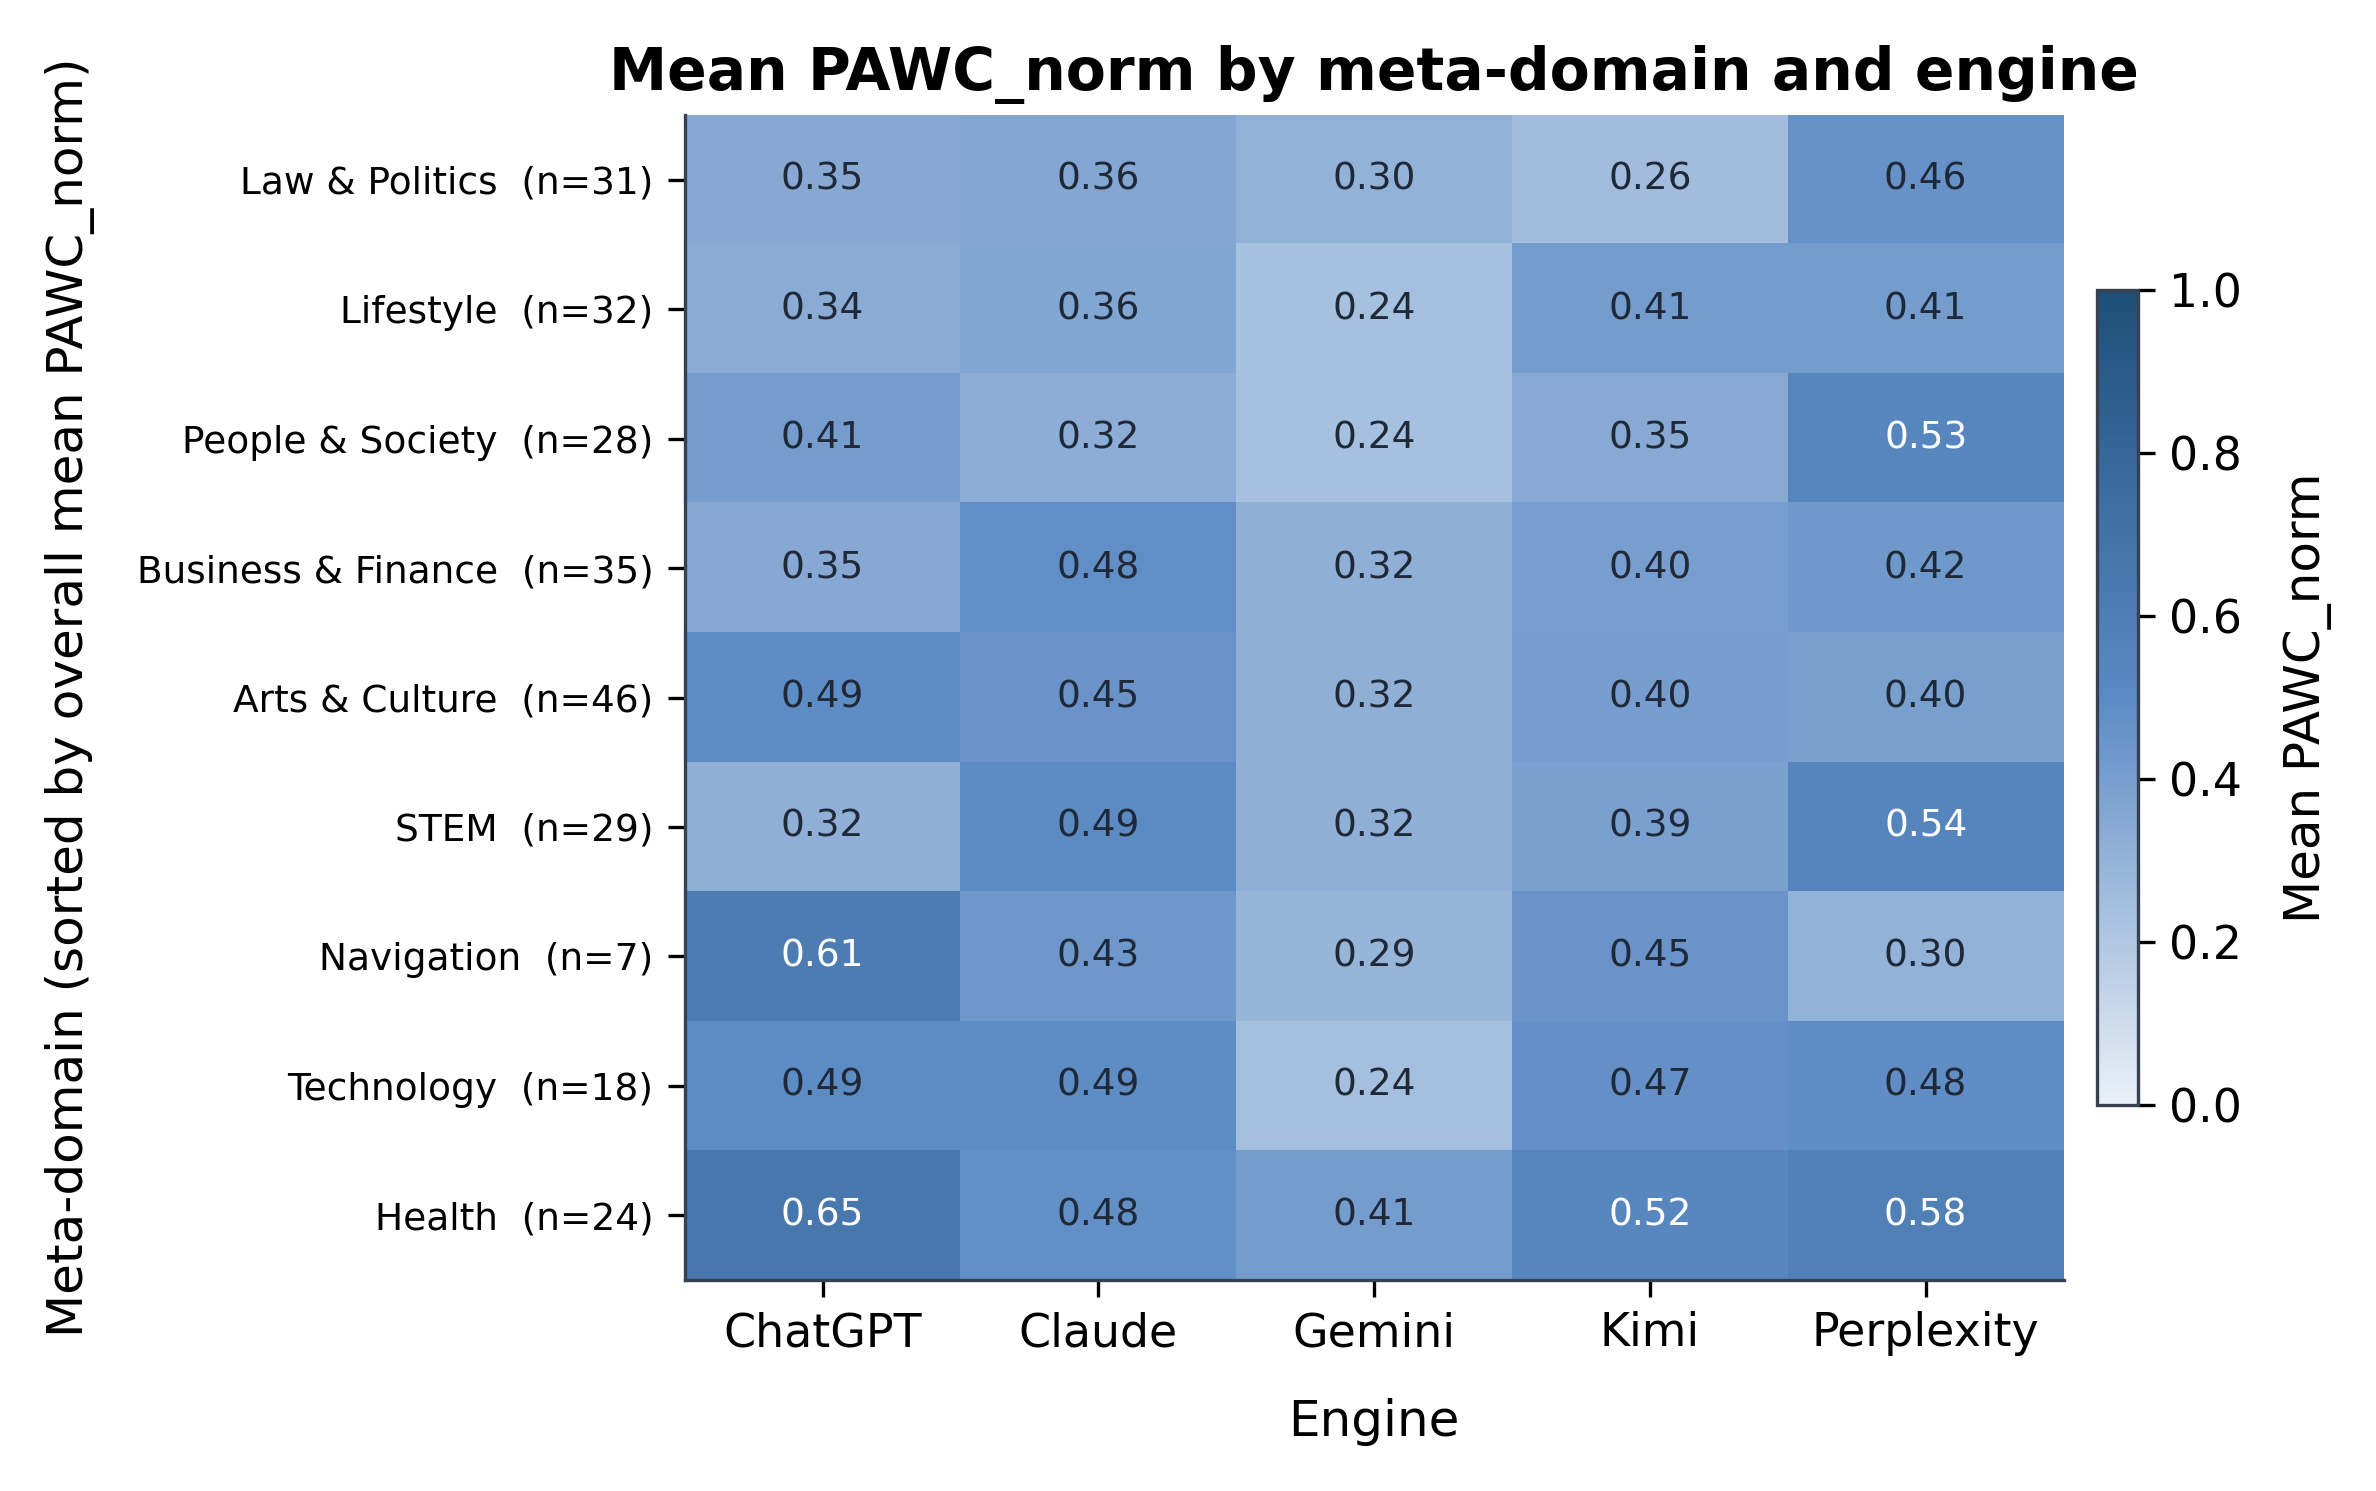

saved → figures/scaleup/fig_eda_12b_pawcnorm_domain_full.png/.pdf


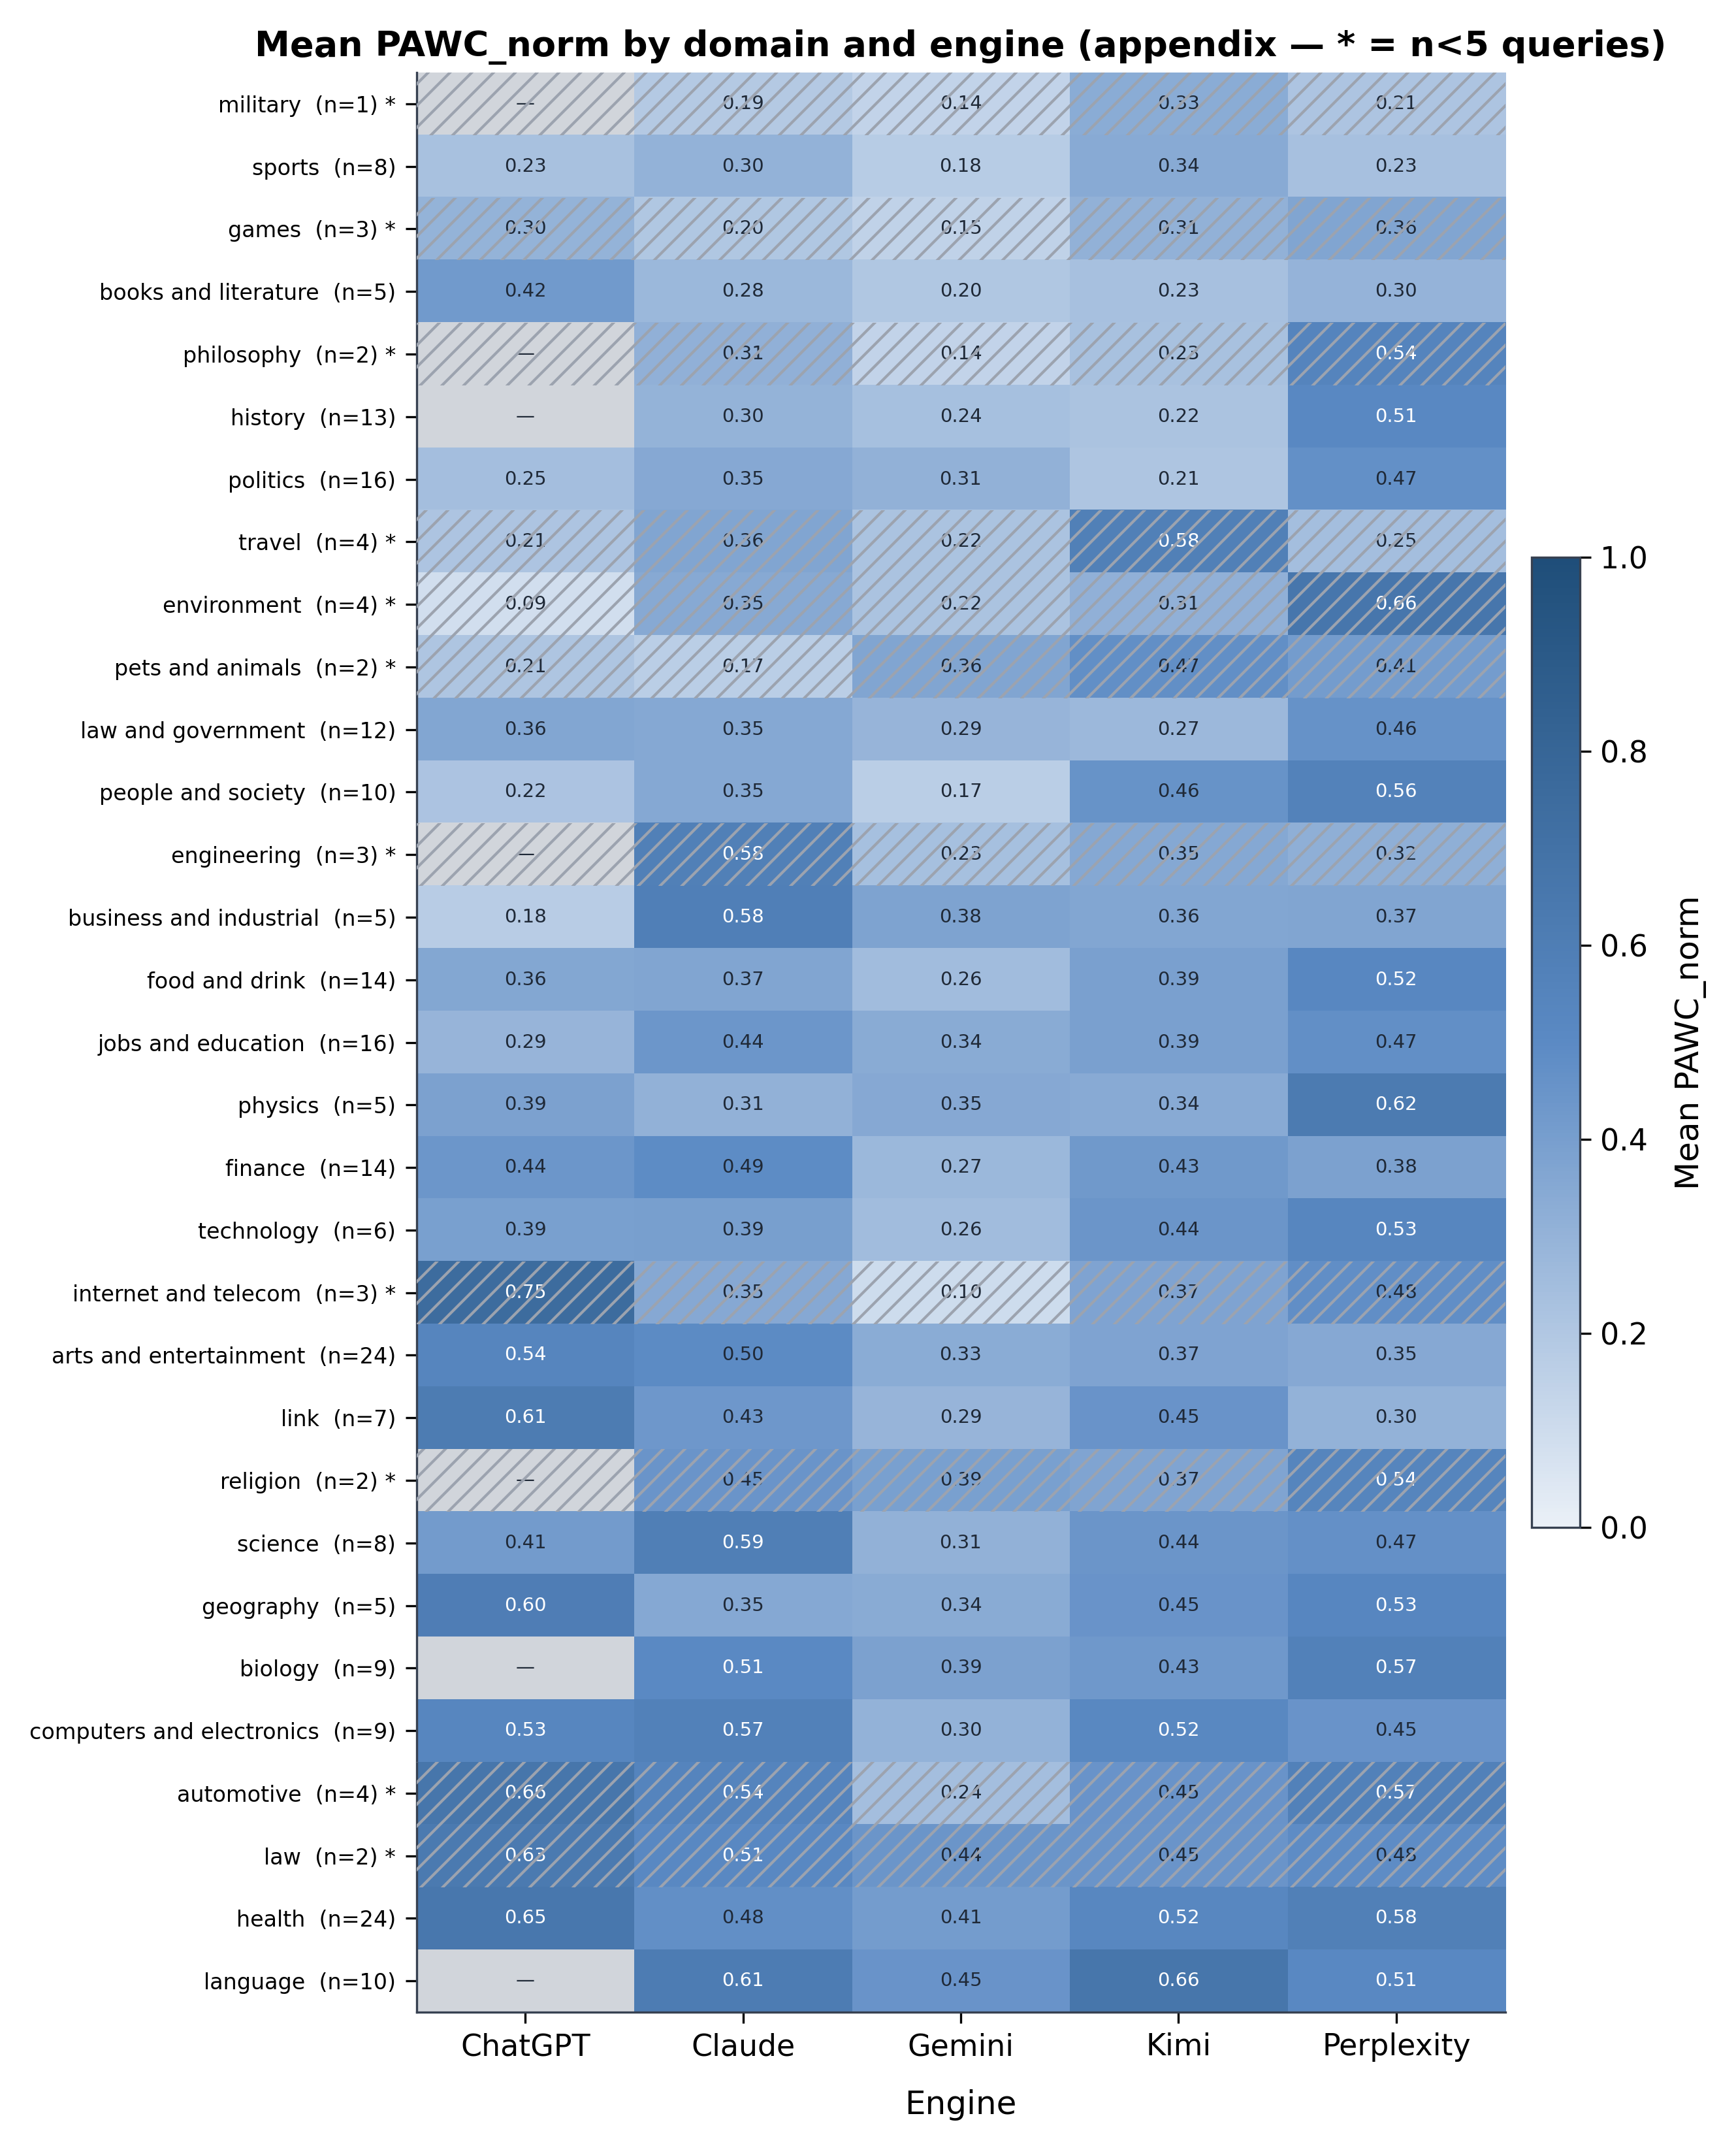

engine              chatgpt  claude  gemini  kimi  perplexity
meta_domain                                                  
Law & Politics        0.350   0.359   0.305 0.255       0.458
Lifestyle             0.340   0.361   0.236 0.413       0.413
People & Society      0.409   0.324   0.236 0.346       0.531
Business & Finance    0.350   0.479   0.318 0.400       0.422
Arts & Culture        0.485   0.450   0.319 0.405       0.397
STEM                  0.319   0.494   0.320 0.394       0.538
Navigation            0.614   0.432   0.291 0.452       0.303
Technology            0.489   0.486   0.242 0.468       0.483
Health                0.649   0.475   0.412 0.523       0.579

ANALYSIS:
Health shows the highest PAWC_norm across engines, followed by Technology and STEM;
Navigation sits mid-pack (about 0.40), not near-zero. Domains vary between engines,
suggesting domain moderation of citation behaviour.

→ RQ1: The meta-domain heatmap reveals domain-by-engine interactions in source
       

In [17]:
# E1 — fig_eda_12: meta-domain heatmap + fig_eda_12b: full 31-domain appendix
# C2: CMAP_SEQUENTIAL (teal-blue), set_bad grey for NaN, domain grouping

META_DOMAIN_MAP = {
    "physics":                  "STEM",
    "biology":                  "STEM",
    "science":                  "STEM",
    "engineering":              "STEM",
    "environment":              "STEM",
    "computers and electronics":"Technology",
    "internet and telecom":     "Technology",
    "technology":               "Technology",
    "health":                   "Health",
    "arts and entertainment":   "Arts & Culture",
    "books and literature":     "Arts & Culture",
    "language":                 "Arts & Culture",
    "philosophy":               "Arts & Culture",
    "religion":                 "Arts & Culture",
    "games":                    "Arts & Culture",
    "law":                      "Law & Politics",
    "law and government":       "Law & Politics",
    "politics":                 "Law & Politics",
    "military":                 "Law & Politics",
    "business and industrial":  "Business & Finance",
    "finance":                  "Business & Finance",
    "jobs and education":       "Business & Finance",
    "food and drink":           "Lifestyle",
    "travel":                   "Lifestyle",
    "pets and animals":         "Lifestyle",
    "automotive":               "Lifestyle",
    "sports":                   "Lifestyle",
    "people and society":       "People & Society",
    "history":                  "People & Society",
    "geography":                "People & Society",
    "link":                     "Navigation",
}
print("Domain → Meta-domain mapping:")
import json; print(json.dumps(META_DOMAIN_MAP, indent=2))

# ── Meta-domain heatmap (primary figure) ────────────────────────────────────
rq_meta = rq.copy()
rq_meta["meta_domain"] = rq_meta["domain"].map(META_DOMAIN_MAP)
n_per_meta = rq_meta.groupby("meta_domain")["query_id"].nunique()

ca_meta = ca.copy()
ca_meta["meta_domain"] = ca_meta["domain"].map(META_DOMAIN_MAP)
piv_m = (ca_meta.groupby(["meta_domain","engine"])["pawc_norm_mean"]
               .mean().unstack()[ENGINE_ORDER])
piv_m = piv_m.loc[piv_m.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5))
import numpy as np
im = ax.imshow(np.ma.masked_invalid(piv_m.values), aspect="auto",
               cmap=CMAP_SEQUENTIAL, vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER], fontsize=11)
ytick_labels = [f"{d}  (n={n_per_meta.get(d, 0)})" for d in piv_m.index]
ax.set_yticks(range(len(piv_m))); ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_title("Mean PAWC_norm by meta-domain and engine", fontsize=14, fontweight="bold")
ax.set_xlabel("Engine", fontsize=12, fontweight="medium")
ax.set_ylabel("Meta-domain (sorted by overall mean PAWC_norm)", fontsize=12, fontweight="medium")
for i in range(piv_m.shape[0]):
    for j in range(piv_m.shape[1]):
        v = piv_m.values[i, j]
        label = "\u2014" if np.isnan(v) else f"{v:.2f}"
        color = "white" if (not np.isnan(v) and v > 0.5) else "#1F2937"
        ax.text(j, i, label, ha="center", va="center", fontsize=9, color=color)
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="Mean PAWC_norm")
ax.grid(False)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout(); savefig("fig_eda_12_pawcnorm_domain_heatmap"); plt.show()

# ── Full 31-domain heatmap (appendix) ───────────────────────────────────────
n_per_domain = rq.groupby("domain")["query_id"].nunique()
piv_full = (ca.pivot_table(index="domain", columns="engine",
                            values="pawc_norm_mean", aggfunc="mean")[ENGINE_ORDER])
piv_full = piv_full.loc[piv_full.mean(axis=1).sort_values().index]

fig2, ax2 = plt.subplots(figsize=(9, 11))
im2 = ax2.imshow(np.ma.masked_invalid(piv_full.values), aspect="auto",
                 cmap=CMAP_SEQUENTIAL, vmin=0, vmax=1)
ax2.set_xticks(range(5))
ax2.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER], fontsize=11)
ytlabels_full = []
for domain in piv_full.index:
    n = n_per_domain.get(domain, 0)
    flag = " *" if n < 5 else ""
    ytlabels_full.append(f"{domain}  (n={n}){flag}")
ax2.set_yticks(range(len(piv_full))); ax2.set_yticklabels(ytlabels_full, fontsize=8)
ax2.set_title("Mean PAWC_norm by domain and engine (appendix — * = n<5 queries)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Engine", fontsize=12, fontweight="medium")
for i in range(piv_full.shape[0]):
    for j in range(piv_full.shape[1]):
        v = piv_full.values[i, j]
        label = "\u2014" if np.isnan(v) else f"{v:.2f}"
        color = "white" if (not np.isnan(v) and v > 0.5) else "#1F2937"
        ax2.text(j, i, label, ha="center", va="center", fontsize=7, color=color)
        # grey-hatch low-n rows
        domain = piv_full.index[i]
        if n_per_domain.get(domain, 0) < 5:
            import matplotlib.patches as mpatches
            ax2.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                          fill=False, hatch="///", edgecolor="#9CA3AF", linewidth=0, zorder=5))
plt.colorbar(im2, ax=ax2, shrink=0.5, pad=0.02, label="Mean PAWC_norm")
ax2.grid(False)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)
plt.tight_layout(); savefig("fig_eda_12b_pawcnorm_domain_full"); plt.show()
print(piv_m.round(3).to_string())
print('''
ANALYSIS:
Health shows the highest PAWC_norm across engines, followed by Technology and STEM;
Navigation sits mid-pack (about 0.40), not near-zero. Domains vary between engines,
suggesting domain moderation of citation behaviour.

→ RQ1: The meta-domain heatmap reveals domain-by-engine interactions in source
       prominence. The full 31-domain appendix shows the underlying sparse cells.
       NaN cells (grey) are queries where no engine produced citable PAWC_norm.
''')

---
## E2 · PAWC_norm by complexity × engine

**Question:** How does PAWC_norm vary by complexity level across the five engines?

saved → figures/scaleup/fig_eda_13_pawcnorm_by_complexity.png/.pdf


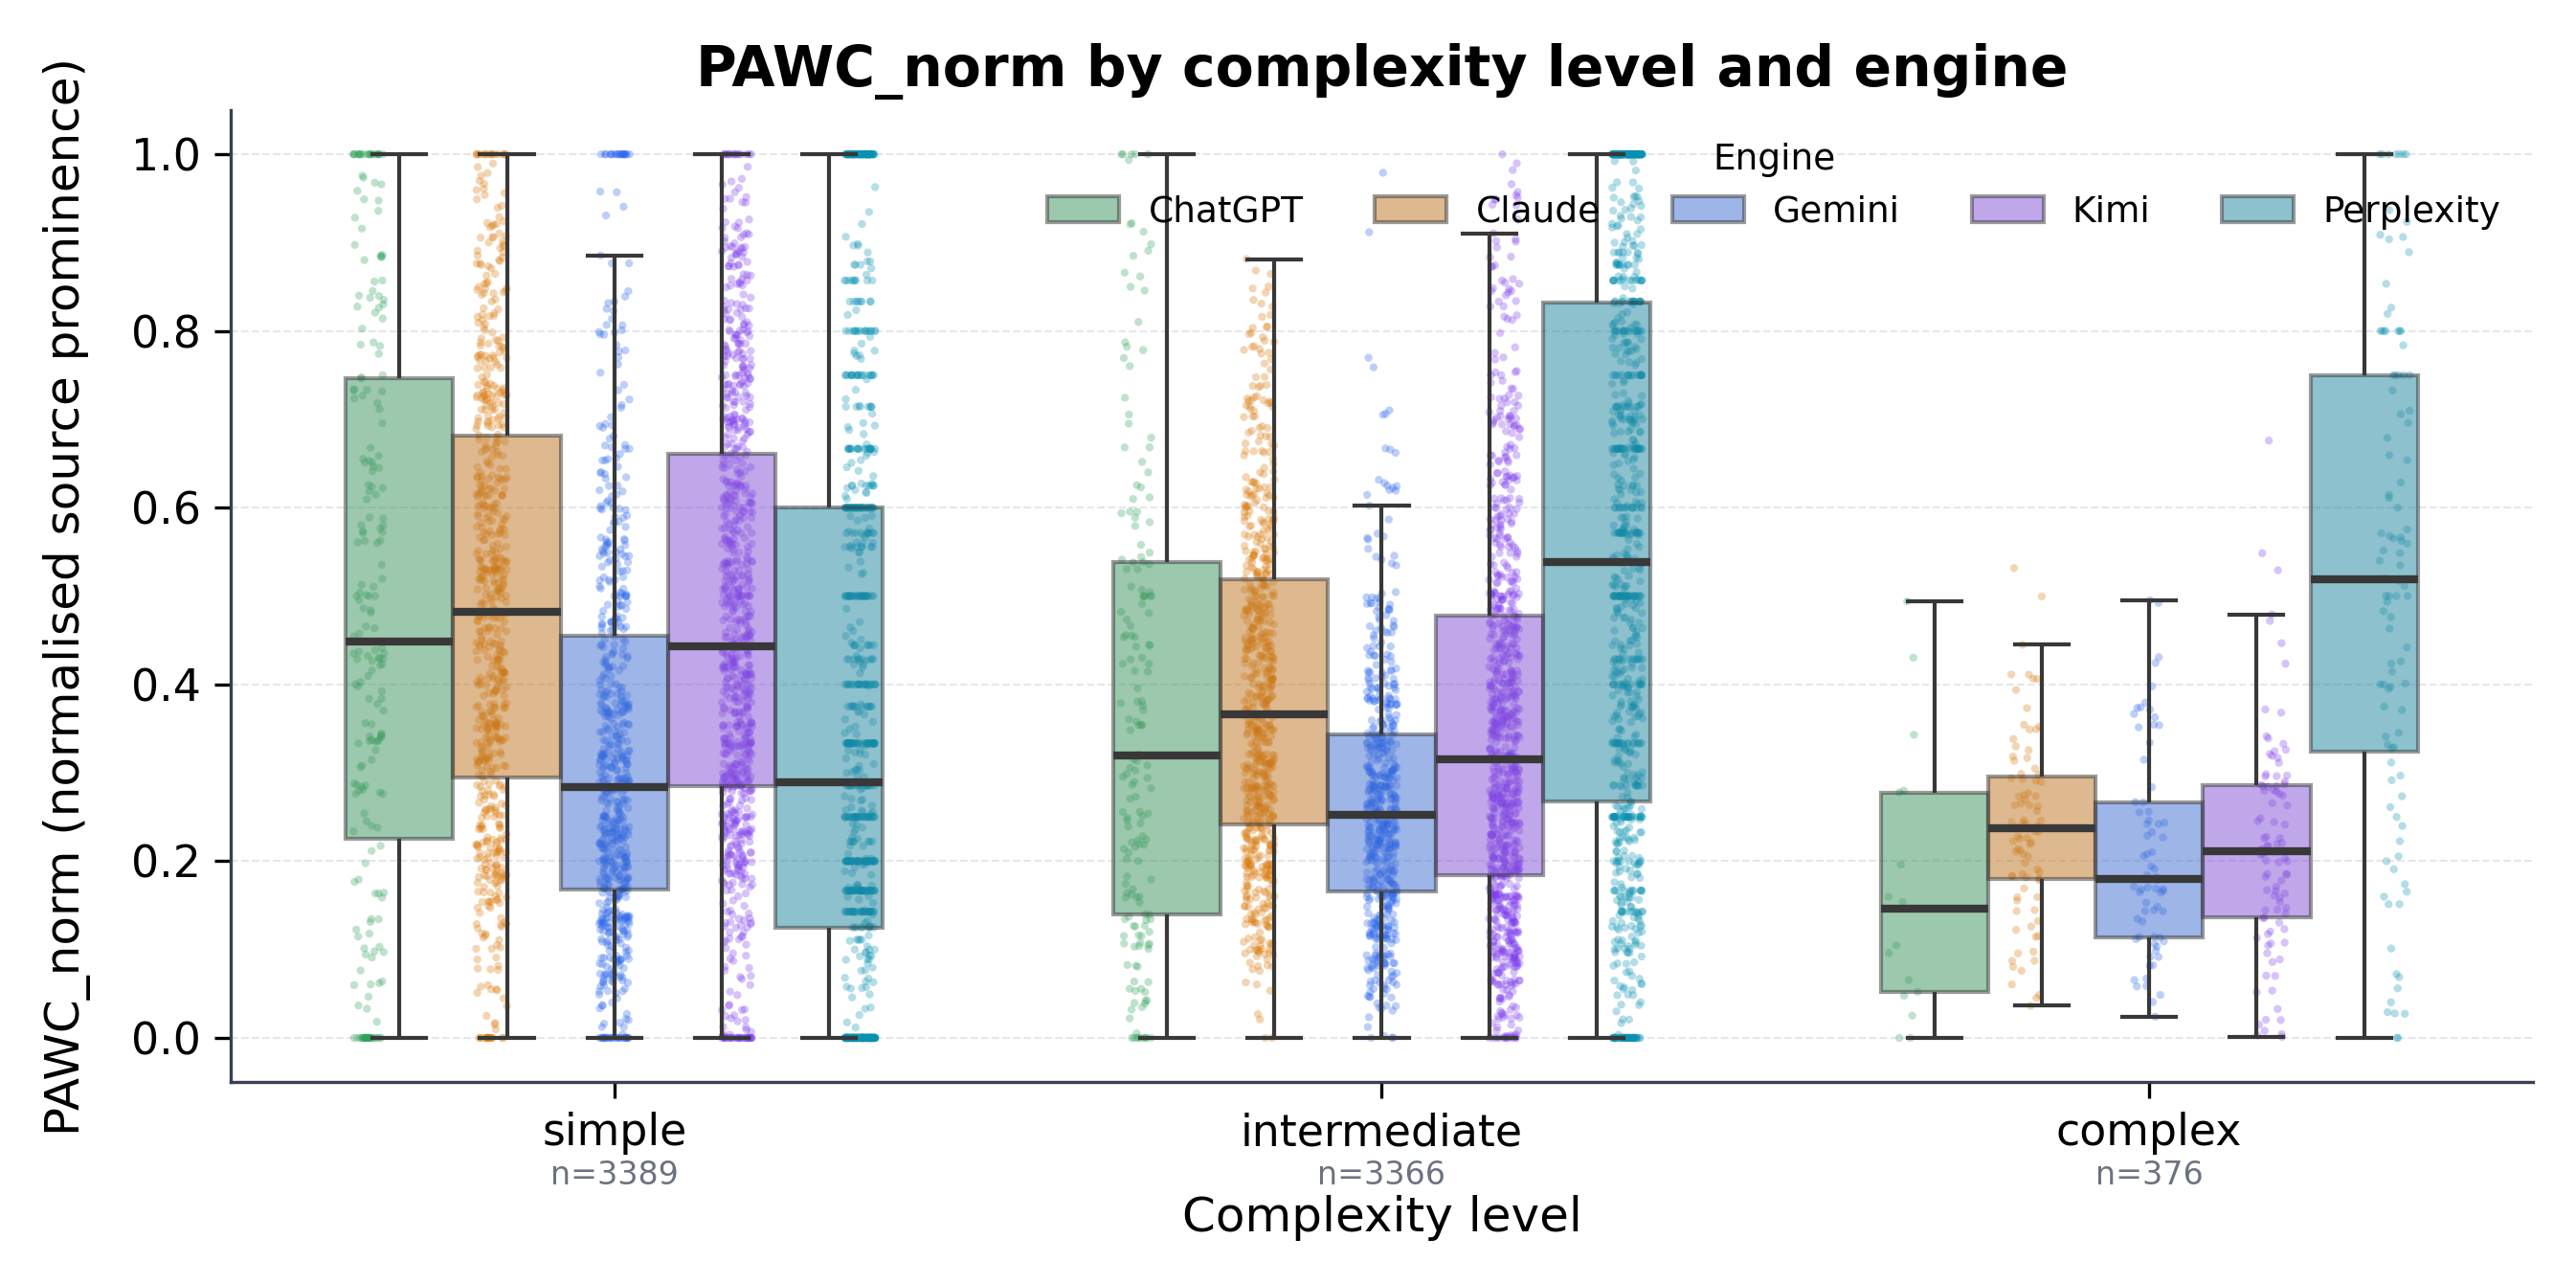

                         mean  median  count
engine     complexity                       
chatgpt    complex      0.169   0.146     17
           intermediate 0.373   0.319    178
           simple       0.481   0.449    219
claude     complex      0.238   0.238     87
           intermediate 0.388   0.367    696
           simple       0.488   0.482    684
gemini     complex      0.209   0.180     71
           intermediate 0.268   0.253    590
           simple       0.330   0.284    684
kimi       complex      0.218   0.211     97
           intermediate 0.347   0.315    934
           simple       0.467   0.443    881
perplexity complex      0.520   0.519    104
           intermediate 0.546   0.538    968
           simple       0.372   0.289    921

ANALYSIS:
PAWC_norm tends to decrease from simple to complex on four of five engines (Perplexity is
the exception), but complex rests on only 13 queries — the strip plots are sparse, so the
trend is low-confidence.

→ RQ1: A mild comp

In [18]:
# E2 — fig_eda_13: box + strip overlay; D1: stripplot makes low-n visible
ORDER_COMPLEXITY = ["simple", "intermediate", "complex"]
src2 = r1.dropna(subset=["pawc_norm"])

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=src2, x="complexity", y="pawc_norm",
            hue="engine", order=ORDER_COMPLEXITY, hue_order=ENGINE_ORDER,
            palette=ENGINE_COLOURS, ax=ax, width=0.7,
            medianprops=dict(linewidth=2), boxprops=dict(alpha=0.5),
            flierprops=dict(visible=False))
# D1: strip overlay — complex tier visually reads as few points
sns.stripplot(data=src2, x="complexity", y="pawc_norm",
              hue="engine", order=ORDER_COMPLEXITY, hue_order=ENGINE_ORDER,
              palette=ENGINE_COLOURS, ax=ax, dodge=True, size=2, alpha=0.3,
              legend=False, zorder=1)

ax.set_title("PAWC_norm by complexity level and engine", fontsize=14, fontweight="bold")
ax.set_xlabel("Complexity level", fontsize=12, fontweight="medium")
ax.set_ylabel("PAWC_norm (normalised source prominence)", fontsize=12, fontweight="medium")
h, _ = ax.get_legend_handles_labels()
ax.legend(h, [ENGINE_LABELS[e] for e in ENGINE_ORDER],
          title="Engine", ncol=5, fontsize=9, title_fontsize=9,
          loc="upper right", frameon=False)
# Annotate n per complexity tier below x-axis
n_per_ct = src2.groupby("complexity").size().reindex(ORDER_COMPLEXITY)
for j, ct in enumerate(ORDER_COMPLEXITY):
    ax.text(j, -0.08, f"n={int(n_per_ct[ct])}", ha="center", va="top",
            transform=ax.get_xaxis_transform(), fontsize=8, color=COLOUR_NEUTRAL)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_13_pawcnorm_by_complexity"); plt.show()
print(src2.groupby(["engine","complexity"])["pawc_norm"]
       .agg(["mean","median","count"]).round(3).to_string())
print('''
ANALYSIS:
PAWC_norm tends to decrease from simple to complex on four of five engines (Perplexity is
the exception), but complex rests on only 13 queries — the strip plots are sparse, so the
trend is low-confidence.

→ RQ1: A mild complexity-decreases-prominence pattern is present on most engines, but the
       thin complex tier (n=13) keeps it indicative only. The strip overlay makes the low
       sample size immediately readable.
''')

---
## E3 · PAWC_norm by intent × engine

**Question:** How does PAWC_norm vary by intent across the five engines?

saved → figures/scaleup/fig_eda_14_pawcnorm_by_intent.png/.pdf


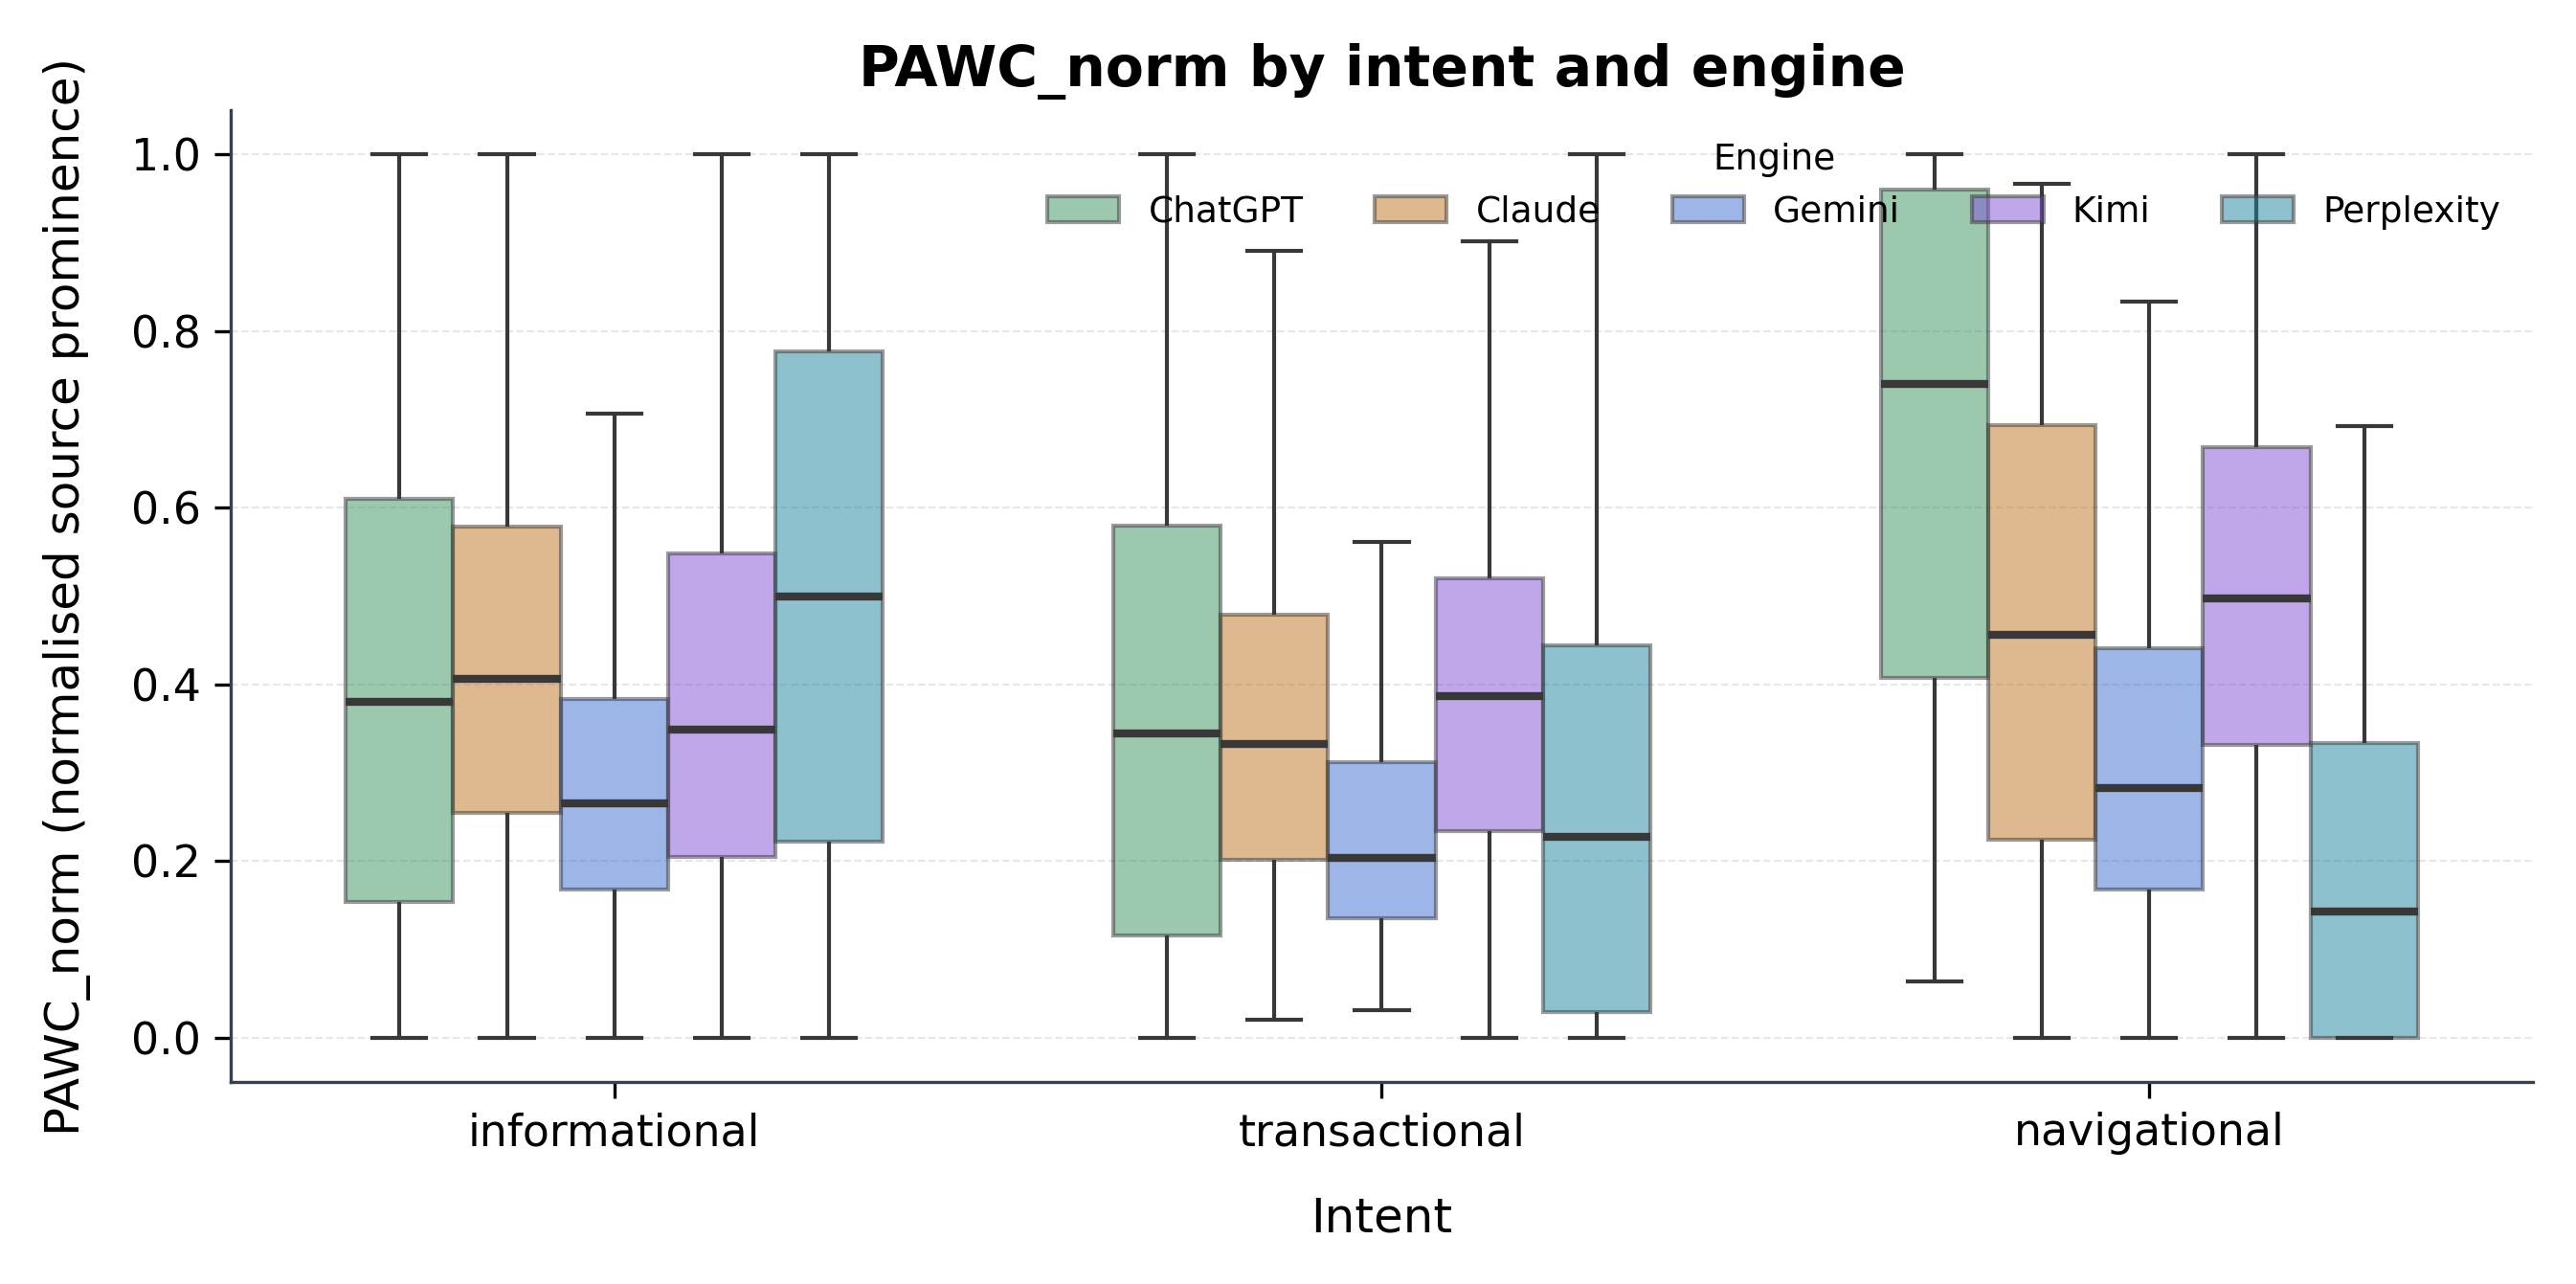

                          mean  median  count
engine     intent                            
chatgpt    informational 0.409   0.380    261
           navigational  0.649   0.740     36
           transactional 0.380   0.345    117
claude     informational 0.429   0.406   1248
           navigational  0.453   0.456     87
           transactional 0.372   0.332    132
gemini     informational 0.302   0.265   1088
           navigational  0.313   0.282    113
           transactional 0.242   0.204    144
kimi       informational 0.390   0.348   1637
           navigational  0.501   0.497    106
           transactional 0.390   0.387    169
perplexity informational 0.499   0.500   1689
           navigational  0.248   0.143    120
           transactional 0.290   0.228    184

ANALYSIS:
Navigational queries do NOT show lower PAWC_norm — on four of five engines their median is
at least as high as informational, though this rests on only 15 queries. Informational and
transactional distributio

In [19]:
# E3 — fig_eda_14: seaborn grouped box PAWC_norm by intent × engine
seaborn_box(r1, x="intent", x_order=["informational","transactional","navigational"],
            y="pawc_norm",
            title="PAWC_norm by intent and engine",
            xlabel="Intent",
            ylabel="PAWC_norm (normalised source prominence)",
            figname="fig_eda_14_pawcnorm_by_intent")
print(r1.dropna(subset=["pawc_norm"]).groupby(["engine","intent"])["pawc_norm"]
       .agg(["mean","median","count"]).round(3).to_string())
print('''
ANALYSIS:
Navigational queries do NOT show lower PAWC_norm — on four of five engines their median is
at least as high as informational, though this rests on only 15 queries. Informational and
transactional distributions overlap substantially within each engine.

→ RQ1: Intent shows no clear suppression of source prominence; the apparent navigational
       lift sits on a tiny sample (n=15) and should be treated as exploratory, not a
       structural confound.
''')

---
## E4 + E5 · AIS by content type and by sensitivity (confound figure)

**Question:** How does AIS vary by content type and by sensitivity? Are these independent?

**D2:** These two questions are shown in a single figure because 70% of debate queries are also
sensitive — the effects cannot be independently interpreted.

saved → figures/scaleup/fig_eda_15_ais_content_sensitivity.png/.pdf


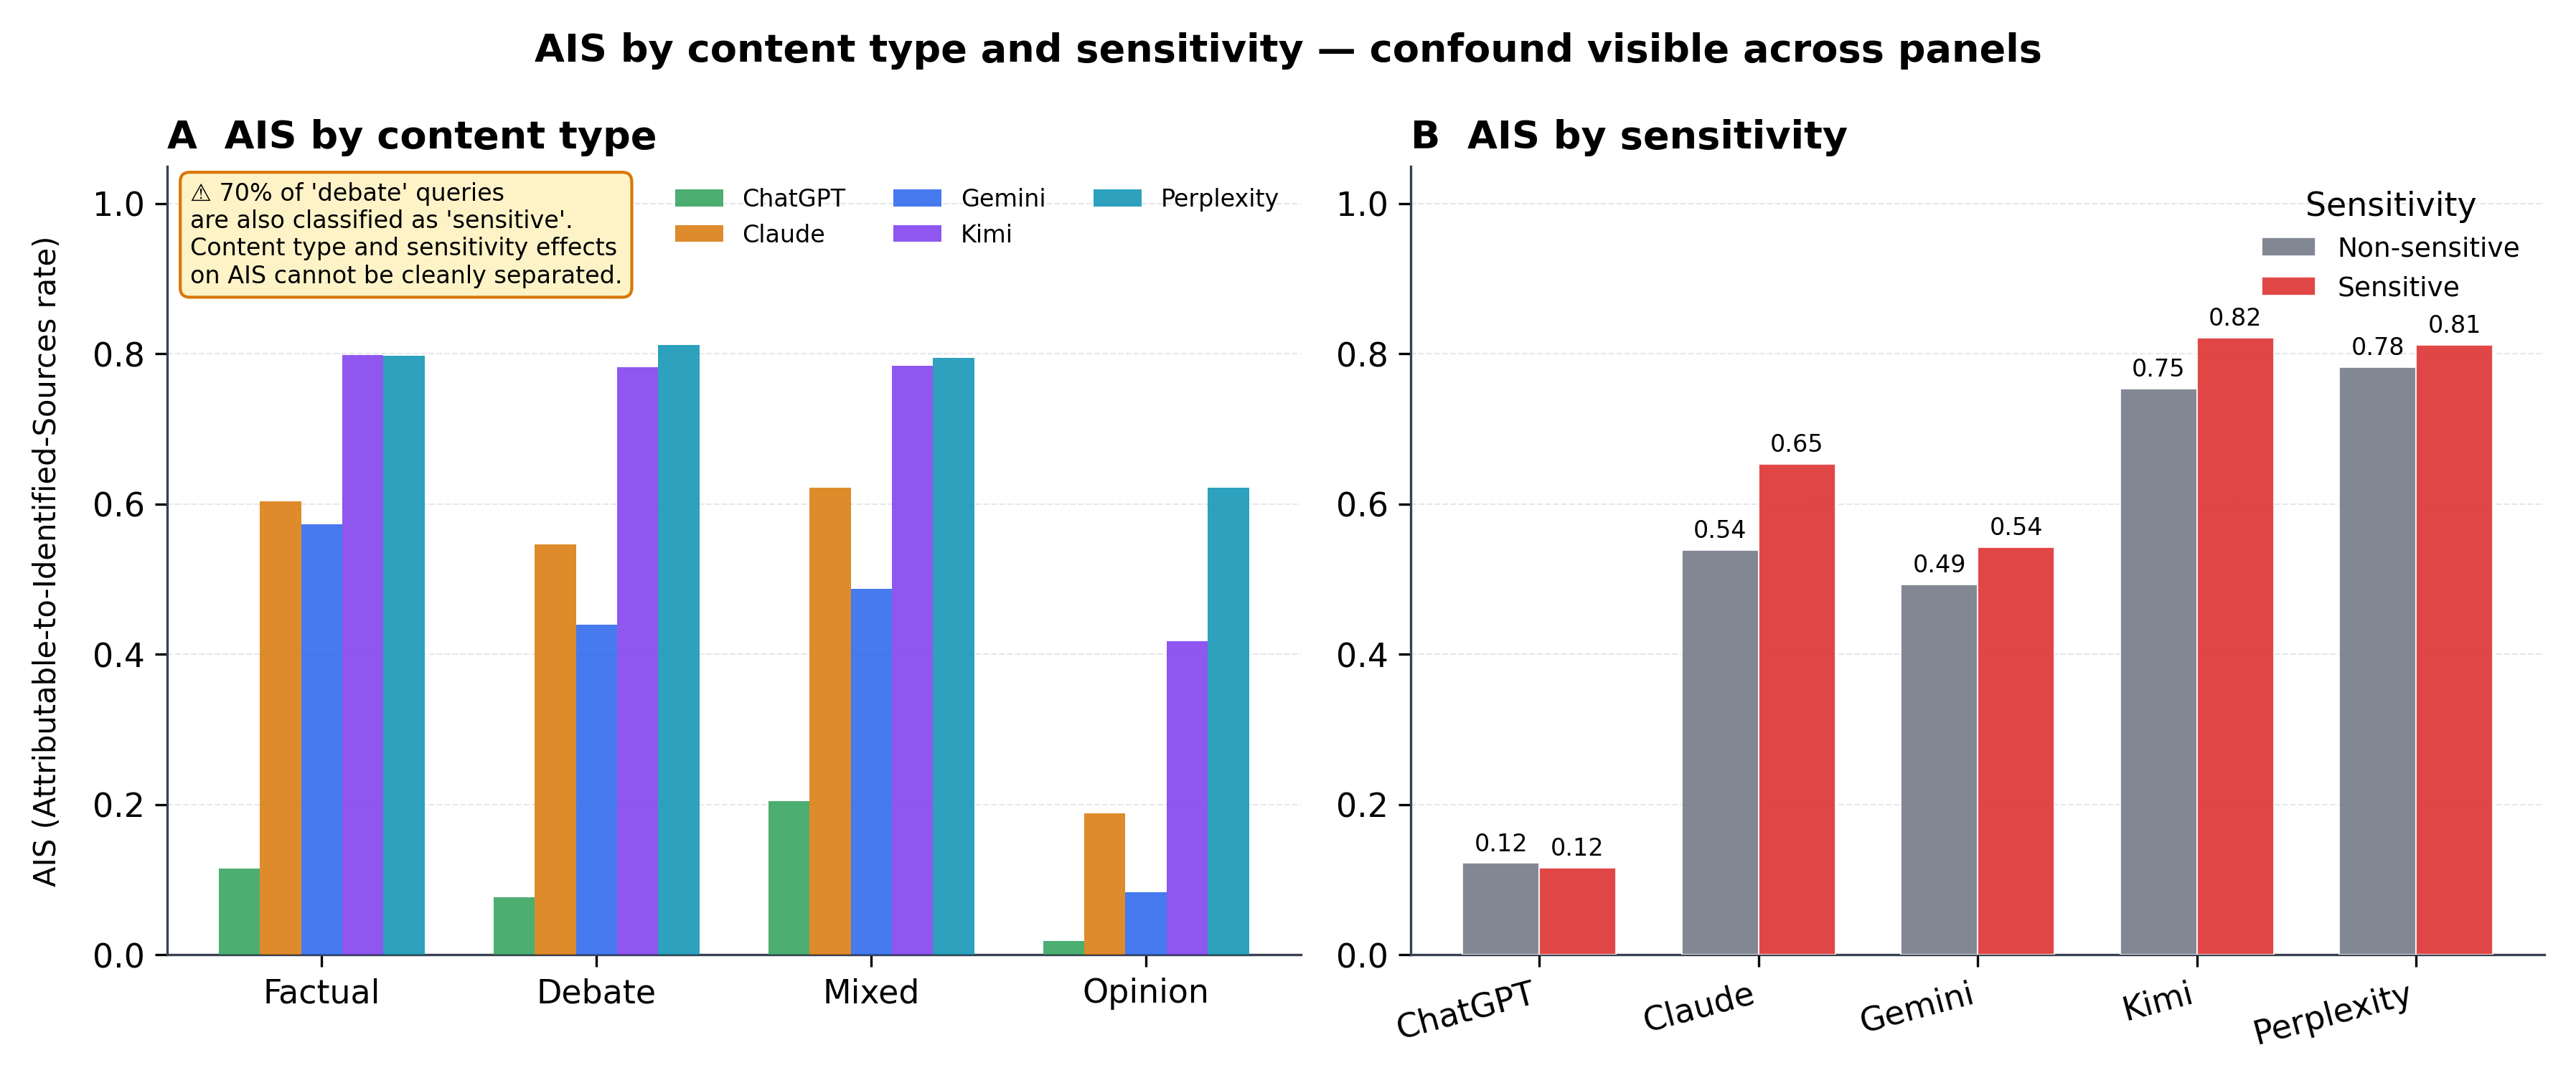

AIS by content type × engine:
content_type  factual  debate  mixed  opinion
engine                                       
chatgpt         0.115   0.077  0.205    0.019
claude          0.604   0.547  0.622    0.188
gemini          0.573   0.440  0.487    0.084
kimi            0.799   0.782  0.784    0.417
perplexity      0.798   0.812  0.794    0.622

AIS by sensitivity × engine:
sensitivity  non-sensitive  sensitive
engine                               
chatgpt              0.122      0.116
claude               0.538      0.653
gemini               0.493      0.542
kimi                 0.754      0.821
perplexity           0.782      0.812

ANALYSIS:
AIS varies modestly by content type. Sensitive queries do not show lower AIS — it is marginally HIGHER on four of five engines. However, because debate is 70% sensitive, any debate-vs-factual AIS
gap likely conflates content difficulty and topic sensitivity simultaneously.

→ RQ3: Content type and sensitivity are moderate, intertwined pred

In [20]:
# E4+E5 combined — fig_eda_15: AIS by content type (A) and by sensitivity (B)
# D2: confound annotation stamped on panel A; B1: correct AIS label throughout
ORDER_CT   = ["factual", "debate", "mixed", "opinion"]
SENS_ORDER = ["non-sensitive", "sensitive"]
SENS_COLS  = {"non-sensitive": COLOUR_NEUTRAL, "sensitive": COLOUR_REFERENCE}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel A: AIS by content type × engine ────────────────────────────────────
grp_ct = (r1.groupby(["engine","content_type"])["cleaned_ais"]
            .mean().unstack().reindex(ENGINE_ORDER)[ORDER_CT])
x, w = np.arange(len(ORDER_CT)), 0.15
for j, eng in enumerate(ENGINE_ORDER):
    offset = (j - 2) * w
    ax1.bar(x + offset, grp_ct.loc[eng].fillna(0), w,
            color=ENGINE_COLOURS[eng], label=ENGINE_LABELS[eng], alpha=0.85, zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels([l.capitalize() for l in ORDER_CT])
ax1.set_title("A  AIS by content type", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("AIS (Attributable-to-Identified-Sources rate)", fontsize=10)
ax1.set_ylim(0, 1.05)
h, _ = ax1.get_legend_handles_labels()
ax1.legend(h, [ENGINE_LABELS[e] for e in ENGINE_ORDER],
           ncol=3, fontsize=8, loc="upper right", frameon=False)
apply_style(ax1)
# D2: confound stamp on panel A
ax1.text(0.02, 0.98,
    "\u26a0\ufe0f 70% of 'debate' queries\nare also classified as 'sensitive'.\n"
    "Content type and sensitivity effects\non AIS cannot be cleanly separated.",
    transform=ax1.transAxes, fontsize=8, va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEF3C7",
              edgecolor="#D97706", linewidth=1.0), zorder=10)

# ── Panel B: AIS by sensitivity × engine ─────────────────────────────────────
grp_s = (r1.groupby(["engine","sensitivity"])["cleaned_ais"]
           .mean().unstack()[SENS_ORDER].reindex(ENGINE_ORDER))
x2 = np.arange(len(ENGINE_ORDER))
for j, s in enumerate(SENS_ORDER):
    bars = ax2.bar(x2 + (j - 0.5) * 0.35, grp_s[s], 0.35,
                   color=SENS_COLS[s], label=s.capitalize(),
                   alpha=0.85, zorder=3, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, grp_s[s]):
        if not np.isnan(v):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x2)
ax2.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER], rotation=15, ha="right")
ax2.set_title("B  AIS by sensitivity", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("")
ax2.set_ylim(0, 1.05)
ax2.legend(title="Sensitivity", loc="upper right", fontsize=9, frameon=False)
apply_style(ax2)

fig.suptitle("AIS by content type and sensitivity — confound visible across panels",
             fontsize=13, fontweight="bold")
plt.tight_layout(); savefig("fig_eda_15_ais_content_sensitivity"); plt.show()
print("AIS by content type × engine:")
print(grp_ct.round(3).to_string())
print("\nAIS by sensitivity × engine:")
print(grp_s.round(3).to_string())
print('''
ANALYSIS:
AIS varies modestly by content type. Sensitive queries do not show lower AIS — it is marginally HIGHER on four of five engines. However, because debate is 70% sensitive, any debate-vs-factual AIS
gap likely conflates content difficulty and topic sensitivity simultaneously.

→ RQ3: Content type and sensitivity are moderate, intertwined predictors of citation
       accuracy. Separating their effects requires controlling for one while varying
       the other — not possible in the current dataset without additional queries.
''')

---
## E6 · Search rate by temporality × engine

**Question:** How does the proportion of runs that trigger a web search vary by temporality?

saved → figures/scaleup/fig_eda_16_search_rate_by_temporality.png/.pdf


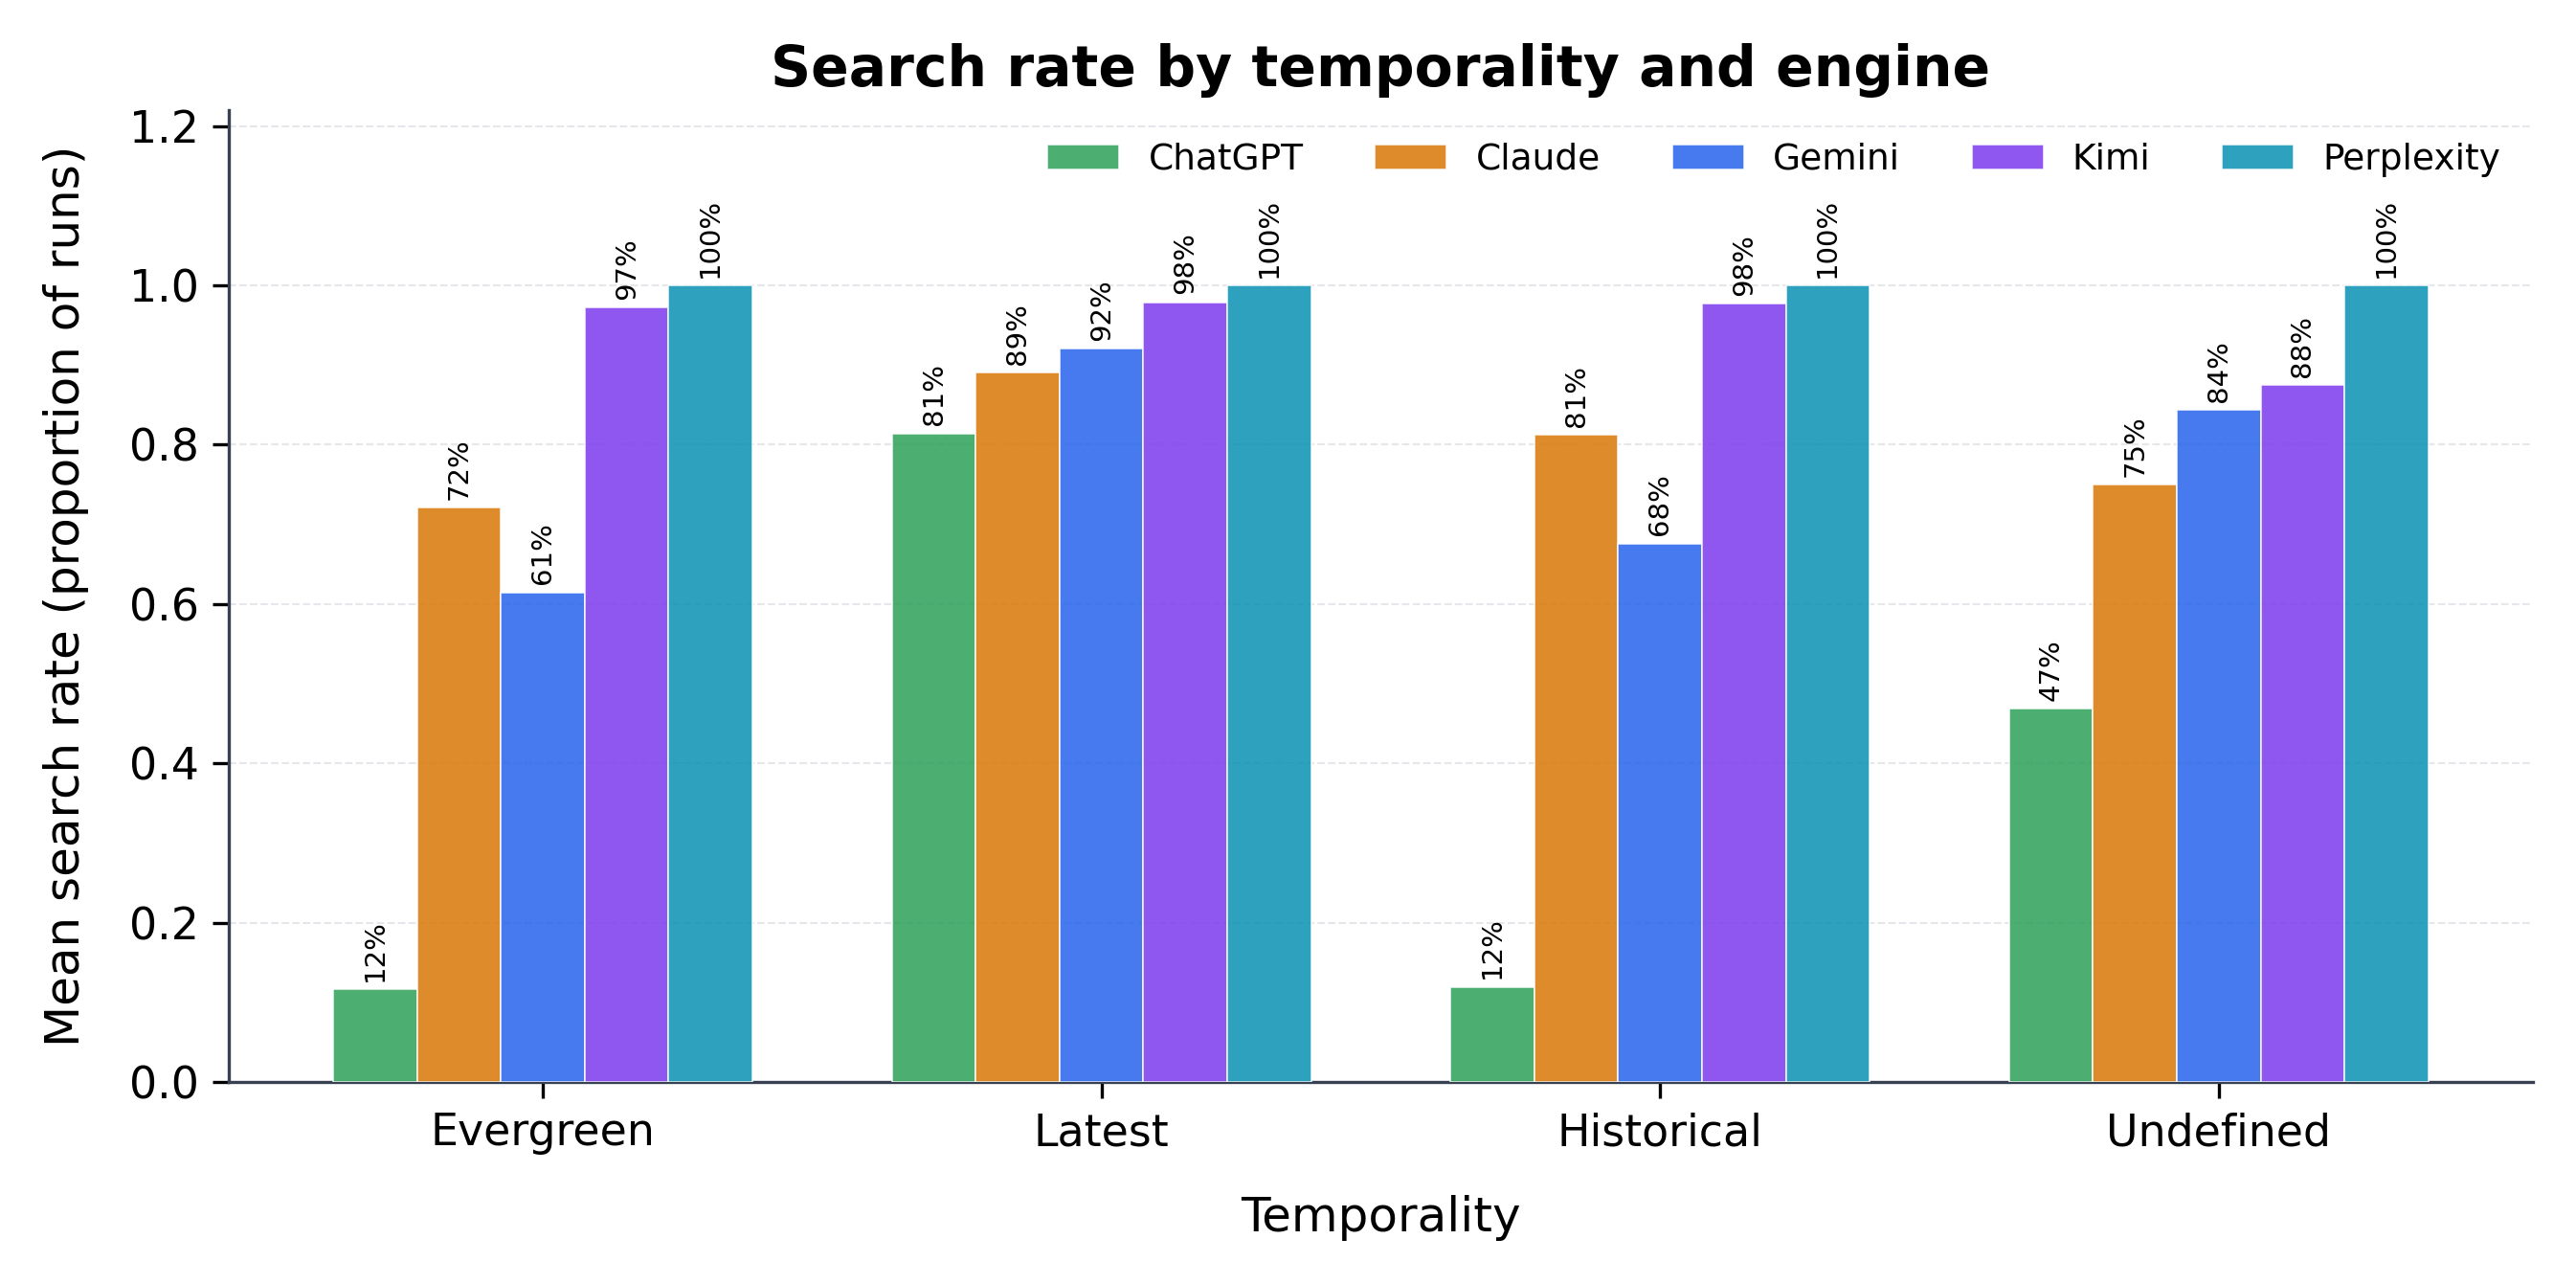

engine       chatgpt  claude  gemini  kimi  perplexity
temporality                                           
evergreen      0.117   0.721   0.615 0.972       1.000
latest         0.814   0.890   0.921 0.979       1.000
historical     0.119   0.812   0.676 0.977       1.000
undefined      0.469   0.750   0.844 0.875       1.000

ANALYSIS:
ChatGPT's search rate rises from 11.7% (evergreen) to 81.4% (latest) — the
sharpest temporal sensitivity of any engine. Claude rises from 72.1% to 89.0%;
Gemini from 61.5% to 92.1%. Kimi searches on nearly every run regardless
of temporality (~97%). Perplexity searches 100% always (inherently grounded).

→ RQ1 + RQ3: Search rate determines whether PAWC_norm and AIS are computable for a run.
             ChatGPT's low evergreen search rate (11.7%) is the primary driver
             of its PAWC_norm null inflation and near-zero headline AIS score.



In [21]:
# E6 — fig_eda_16: grouped bar (F4: not line chart — no false continuous ordering)
# B3: ANALYSIS uses real computed values, not approximations
ORDER_TEMP = ["evergreen", "latest", "historical", "undefined"]
grp = (ca.groupby(["temporality","engine"])["did_search_rate"]
         .mean().unstack()[ENGINE_ORDER].reindex(ORDER_TEMP))

x, w = np.arange(len(ORDER_TEMP)), 0.15
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, eng in enumerate(ENGINE_ORDER):
    offset = (j - 2) * w
    bars = ax.bar(x + offset, grp[eng].values, w,
                  color=ENGINE_COLOURS[eng], label=ENGINE_LABELS[eng],
                  zorder=3, alpha=0.85, edgecolor="white", linewidth=0.4)
    for bar, v in zip(bars, grp[eng].values):
        if not (np.isnan(v) if isinstance(v, float) else False) and v > 0.08:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{v:.0%}", ha="center", va="bottom", fontsize=7, rotation=90)
ax.set_title("Search rate by temporality and engine", fontsize=14, fontweight="bold")
ax.set_xlabel("Temporality", fontsize=12, fontweight="medium")
ax.set_ylabel("Mean search rate (proportion of runs)", fontsize=12, fontweight="medium")
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in ORDER_TEMP])
ax.set_ylim(0, 1.22)
h, _ = ax.get_legend_handles_labels()
ax.legend(h, [ENGINE_LABELS[e] for e in ENGINE_ORDER],
          ncol=5, fontsize=9, loc="upper right", frameon=False)
apply_style(ax); plt.tight_layout(); savefig("fig_eda_16_search_rate_by_temporality"); plt.show()

print(grp.round(4).to_string())

# B3: real values for analysis
cg_ev = grp.loc["evergreen","chatgpt"]
cg_la = grp.loc["latest","chatgpt"]
cl_ev = grp.loc["evergreen","claude"]
cl_la = grp.loc["latest","claude"]
gm_ev = grp.loc["evergreen","gemini"]
gm_la = grp.loc["latest","gemini"]
print(f'''
ANALYSIS:
ChatGPT's search rate rises from {cg_ev:.1%} (evergreen) to {cg_la:.1%} (latest) — the
sharpest temporal sensitivity of any engine. Claude rises from {cl_ev:.1%} to {cl_la:.1%};
Gemini from {gm_ev:.1%} to {gm_la:.1%}. Kimi searches on nearly every run regardless
of temporality (~97%). Perplexity searches 100% always (inherently grounded).

→ RQ1 + RQ3: Search rate determines whether PAWC_norm and AIS are computable for a run.
             ChatGPT's low evergreen search rate ({cg_ev:.1%}) is the primary driver
             of its PAWC_norm null inflation and near-zero headline AIS score.
''')

---

saved → figures/scaleup/fig_eda_17_retrieval_prominence_accuracy.png/.pdf


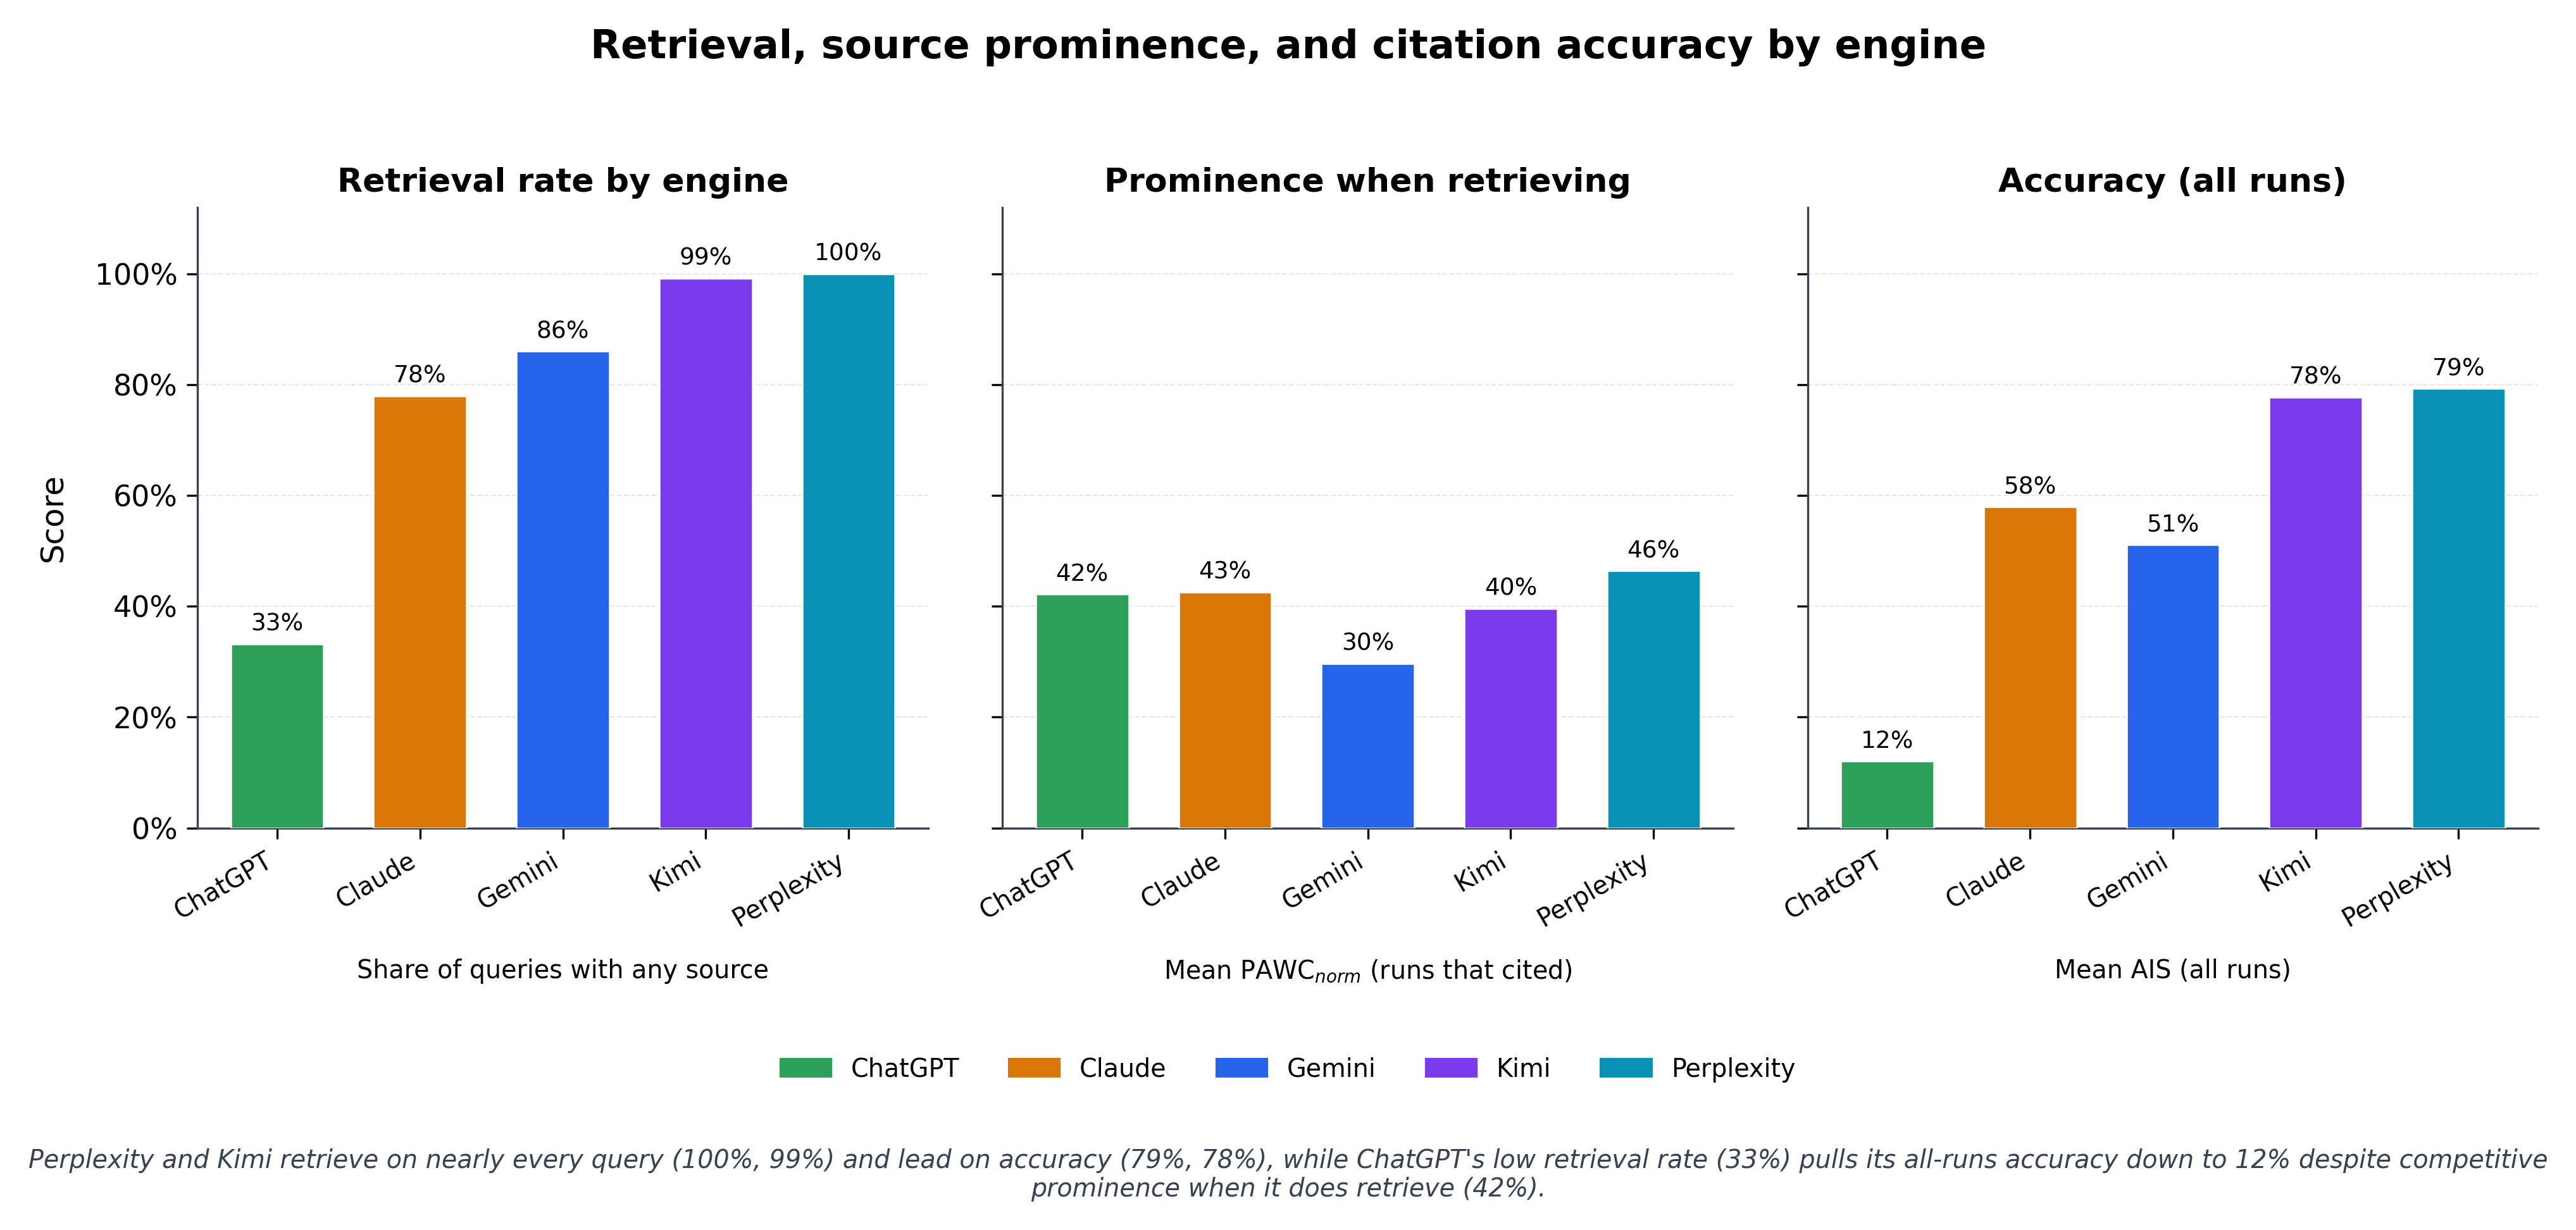

            retrieval  prominence  accuracy
engine                                     
chatgpt         0.332       0.422     0.120
claude          0.780       0.426     0.579
gemini          0.860       0.296     0.511
kimi            0.992       0.396     0.777
perplexity      1.000       0.464     0.793

ANALYSIS:
Note: retrieval rate is the EXACT share of queries with >=1 cited source on any run,
computed from flat_table1_responses — not the qualitative "most queries" / "almost every
query" language. The exact figures diverge from naive qualitative guesses in places
(Gemini 86% vs. an eyeballed ~80%; Kimi 99%
vs. an eyeballed ~95%), so the precise per-query computation is used throughout.

Perplexity and Kimi retrieve on nearly every query (100%, 99%) and lead on accuracy (79%, 78%), while ChatGPT's low retrieval rate (33%) pulls its all-runs accuracy down to 12% despite competitive prominence when it does retrieve (42%).

Denominators still differ across facets: retrieval is per-q

In [22]:
# E7 — fig_eda_17: faceted bar charts — retrieval, prominence, accuracy by engine
# Three small multiples (one metric per facet), same engine order/colours as rest of
# notebook, shared 0-1 axis with percentage ticks. B3: real computed values throughout
# (retrieval rate is the exact share of queries with >=1 cited source on any run — not
# the qualitative "most / almost every" language from the source table).
qtot = r1.groupby("engine")["query_id"].nunique()
qret = (r1.groupby(["engine", "query_id"])["n_sources_cited"].max() > 0).groupby("engine").sum()

M = pd.DataFrame({
    "retrieval":  (qret / qtot),
    "prominence": r1.groupby("engine")["pawc_norm"].mean(),
    "accuracy":   r1.groupby("engine")["cleaned_ais"].mean(),
}).reindex(ENGINE_ORDER)

FACETS = [
    ("retrieval",  "Retrieval rate by engine",        "Share of queries with any source"),
    ("prominence", "Prominence when retrieving",       "Mean PAWC$_{norm}$ (runs that cited)"),
    ("accuracy",   "Accuracy (all runs)",              "Mean AIS (all runs)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5), sharey=True)
for ax, (col, title, ylabel) in zip(axes, FACETS):
    vals = M[col].values
    bars = ax.bar(range(5), vals, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER],
                  width=0.65, zorder=3, edgecolor="white", linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.0%}",
                ha="center", va="bottom", fontsize=9, fontweight="medium")
    ax.set_title(title, fontsize=12.5, fontweight="bold")
    ax.set_xlabel(ylabel, fontsize=9.5, fontweight="medium")
    ax.set_xticks(range(5))
    ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER], rotation=30, ha="right", fontsize=9.5)
    ax.set_ylim(0, 1.12)
    apply_style(ax)

axes[0].set_ylabel("Score", fontsize=12, fontweight="medium")
axes[0].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))

fig.suptitle("Retrieval, source prominence, and citation accuracy by engine",
             fontsize=15, fontweight="bold", y=1.04)

handles = [mpl.patches.Patch(color=ENGINE_COLOURS[e], label=ENGINE_LABELS[e]) for e in ENGINE_ORDER]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=5, frameon=False, fontsize=9.5)

cap = (f"Perplexity and Kimi retrieve on nearly every query ({M.loc['perplexity','retrieval']:.0%}, "
       f"{M.loc['kimi','retrieval']:.0%}) and lead on accuracy ({M.loc['perplexity','accuracy']:.0%}, "
       f"{M.loc['kimi','accuracy']:.0%}), while ChatGPT's low retrieval rate "
       f"({M.loc['chatgpt','retrieval']:.0%}) pulls its all-runs accuracy down to "
       f"{M.loc['chatgpt','accuracy']:.0%} despite competitive prominence when it does retrieve "
       f"({M.loc['chatgpt','prominence']:.0%}).")
fig.text(0.5, -0.14, cap, ha="center", va="top", fontsize=9.5, wrap=True,
        color="#374151", style="italic")

plt.tight_layout()
savefig("fig_eda_17_retrieval_prominence_accuracy"); plt.show()

print(M.round(3).to_string())

# B3: real values for analysis
print(f'''
ANALYSIS:
Note: retrieval rate is the EXACT share of queries with >=1 cited source on any run,
computed from flat_table1_responses — not the qualitative "most queries" / "almost every
query" language. The exact figures diverge from naive qualitative guesses in places
(Gemini {M.loc["gemini","retrieval"]:.0%} vs. an eyeballed ~80%; Kimi {M.loc["kimi","retrieval"]:.0%}
vs. an eyeballed ~95%), so the precise per-query computation is used throughout.

{cap}

Denominators still differ across facets: retrieval is per-query (>=1 cite on any run);
prominence is conditioned on runs that cited; accuracy averages over ALL runs, so engines
that skip retrieval are penalised there but not in the prominence facet.
''')